# Layout Detection — local run

Runs `PP-DocLayout_plus-L` over a PDF entirely on this machine.

**Nothing is pip-installed** — every package used here is already present:
`paddlepaddle-gpu 3.2.0`, `paddleocr 3.7.0`, `paddlex 3.7.2`, `PyMuPDF 1.26.7`,
`opencv-python 4.12`, `pandas 2.2.3`, `numpy 2.2.6`.

Pipeline: PDF -> page images -> binarize -> layout detection -> width statistics.

In [1]:
# ============================================================
# 1. Environment  --  no installs, must run before paddle is imported
# ============================================================
import os

# CPU-only flags; silently ignored when running on GPU.
os.environ["FLAGS_enable_pir_api"] = "0"
os.environ["FLAGS_use_mkldnn"] = "0"
os.environ["PADDLE_PDX_ENABLE_MKLDNN_BYDEFAULT"] = "0"

import importlib.util

REQUIRED = {
    "fitz": "PyMuPDF",
    "cv2": "opencv-python",
    "numpy": "numpy",
    "pandas": "pandas",
    "paddle": "paddlepaddle-gpu",
    "paddleocr": "paddleocr",
}

missing = [pkg for mod, pkg in REQUIRED.items()
           if importlib.util.find_spec(mod) is None]
if missing:
    raise ImportError(
        "Missing package(s): " + ", ".join(missing)
        + "\nThis notebook installs nothing on purpose -- install them yourself."
    )

# ---------------------------------------------------------------------------
# IMPORT ORDER IS LOAD-BEARING on this machine.
#
# paddle and torch ship conflicting bundled DLLs. Whichever imports first wins:
#   import paddle -> import torch   ==  OSError [WinError 127] on torch/lib/shm.dll
#   import torch  -> import paddle  ==  fine
#
# paddleocr cannot avoid touching torch: paddlex runs a langchain shim on
# import, which pulls langchain_text_splitters -> transformers -> torch.
# (Setting USE_TORCH=0 does NOT help -- transformers 4.57 ignores it.)
#
# So import paddleocr FIRST. Its own chain loads torch, then paddle, in the
# working order, and that order holds for the whole kernel session.
# ---------------------------------------------------------------------------
import sys

if "paddle" in sys.modules and "torch" not in sys.modules:
    raise RuntimeError(
        "paddle was imported before torch in this kernel -- the torch DLL load "
        "will fail.\nRestart the kernel and run this cell first."
    )

import paddleocr  # noqa: F401  -- MUST come before `import paddle`

print("All required packages present. Nothing to install.")
print("paddleocr imported first; torch/paddle DLL order is safe.")

All required packages present. Nothing to install.
paddleocr imported first; torch/paddle DLL order is safe.


In [2]:
# ============================================================
# 2. Sanity check  --  versions and compute device
# ============================================================
# Safe here: cell 1 already imported paddleocr, which loaded paddle for us.
import paddle

print("paddle          :", paddle.__version__)
print("default device  :", paddle.get_device())
print("built with cuda :", paddle.is_compiled_with_cuda())
print("gpu count       :", paddle.device.cuda.device_count())

if paddle.device.cuda.device_count():
    props = paddle.device.cuda.get_device_properties(0)
    print("gpu             :", props.name)
    print("vram            :", f"{props.total_memory / 1024**3:.1f} GB")

C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


paddle          : 3.2.0
default device  : gpu:0
built with cuda : True
gpu count       : 1
gpu             : NVIDIA GeForce RTX 3050 Ti Laptop GPU
vram            : 4.0 GB


In [3]:
# ============================================================
# 3. Model cache check
# ============================================================
from pathlib import Path

MODEL_NAME = "PP-DocLayout_plus-L"
CACHE_DIR = Path.home() / ".paddlex" / "official_models"

cached = sorted(p.name for p in CACHE_DIR.glob("*")) if CACHE_DIR.exists() else []
print(f"Cache: {CACHE_DIR}")
print("Already cached:", cached or "(nothing)")

if MODEL_NAME in cached:
    print(f"\n'{MODEL_NAME}' is cached -- cell 6 will load it offline.")
else:
    print(
        f"\n'{MODEL_NAME}' is NOT cached.\n"
        "Cell 6 will download it once (~120 MB) into the folder above,\n"
        "then every later run is fully offline. This is the only download\n"
        "this notebook can make -- layout detection needs model weights.\n\n"
        "To avoid it, copy the folder from a machine that has it (e.g. Colab:\n"
        f"  /root/.paddlex/official_models/{MODEL_NAME})\n"
        f"into  {CACHE_DIR / MODEL_NAME}"
    )

Cache: C:\Users\ASUS\.paddlex\official_models
Already cached: ['PP-DocLayout_plus-L', 'PP-LCNet_x1_0_doc_ori', 'PP-LCNet_x1_0_textline_ori', 'PP-OCRv5_mobile_det', 'PP-OCRv5_server_det', 'PP-OCRv6_medium_det', 'PP-OCRv6_medium_rec', 'UVDoc', 'arabic_PP-OCRv5_mobile_rec']

'PP-DocLayout_plus-L' is cached -- cell 6 will load it offline.


In [13]:
# ============================================================
# 4. Settings  --  the only cell you normally need to touch
# ============================================================

# --- input ---------------------------------------------------------------
# Set an explicit path, or leave None to auto-pick the first *.pdf next to
# this notebook.
PDF_PATH = "C:/Users/ASUS/Desktop/Data Source/Data Source/قانون التجارة.pdf"

# --- page selection ------------------------------------------------------
PDF_DPI    = 200      # page rendering resolution
START_PAGE = 3        # 1-based index of the first page to process
NUM_PAGES  = 15        # how many pages to run layout detection on

RENDER_SELECTED_ONLY = True   # True renders only the pages above (fast on big
                              # PDFs); False renders every page first

# --- detection -----------------------------------------------------------
# Titles on scanned Arabic pages score 0.25-0.40, so a threshold above ~0.4
# silently drops every paragraph_title / figure_title / image.
THRESHOLD = 0.25

# Per-class override; None means use the single THRESHOLD above.
# Class ids: 0=paragraph_title, 1=image, 2=text, 3=number, 6=figure_title
THRESHOLD_PER_CLASS = None
# THRESHOLD_PER_CLASS = {0: 0.15, 1: 0.40, 2: 0.35, 3: 0.30, 6: 0.15}

LAYOUT_NMS = True     # drop duplicate/overlapping boxes of the same class

# Otsu binarization before detection. Raw PDF renders have a grey background
# that lowers every confidence score; binarizing recovers it.
BINARIZE = True

# "gpu:0" | "cpu" | None (paddle's default).
# 4 GB VRAM is tight at 200 dpi -- switch to "cpu" or lower PDF_DPI on OOM.
DEVICE = "gpu:0"

# --- remote OCR (the PaddleOCR server running in Colab) ------------------
# Paste the two values the Colab notebook prints: the trycloudflare URL and
# the generated token. The tunnel URL changes every time Colab restarts.
OCR_BASE_URL = "https://labs-proudly-supreme-summer.trycloudflare.com"
OCR_TOKEN    = "NJ-9T8yJIZ7nKJTB8y2IzV2kX2wGfAkHrd8NoPCQDGE" 

# Which layout labels to send for OCR. None = every label.
# 'image' and 'formula' are excluded by default -- they hold no readable text.
OCR_LABELS = [
    "text", "paragraph_title", "doc_title", "figure_title",
    "header", "footer", "number", "reference", "reference_content",
]

CROP_PADDING  = 6     # px added around each box before cropping
MIN_CROP_SIDE = 12    # skip boxes thinner/shorter than this (px)

# ORDER MATTERS: oversized boxes are dropped first, then nested ones.
#
# 1) A low-confidence box wrapping a whole page's text area is almost always a
#    false positive. Left in, it swallows every real block in step 2 -- on this
#    document page_0009 collapsed from 19 boxes to 1. Drop boxes covering more
#    than this fraction of the page. None = keep them.
MAX_BOX_AREA_FRAC = 0.35

# 2) PP-DocLayout also emits a block AND fragments of that same block. Class-
#    aware NMS does not remove those, so the same text would be OCR'd twice.
#    Drop a box when at least this fraction of its area sits inside a bigger
#    box. None = keep every box.
DROP_NESTED_ABOVE = 0.90

# Crop from the original grey render rather than the binarized page. Same DPI,
# so layout coordinates still line up. Otsu can eat thin Arabic strokes, and
# PP-OCRv5 does its own preprocessing, so the grey source usually reads better.
CROP_FROM_ORIGINAL = True

OCR_TIMEOUT = 180     # seconds per request (the Colab server is CPU-only)
OCR_RETRIES = 3       # attempts per crop before giving up
OCR_RESUME  = True    # skip crops whose response JSON is already on disk

# --- output --------------------------------------------------------------
PAGES_DIR  = "./pdf_pages"
OUTPUT_DIR = "./layout_output"
CROPS_DIR  = "./crops"

_thr = THRESHOLD_PER_CLASS if THRESHOLD_PER_CLASS is not None else THRESHOLD
print(f"pages {START_PAGE}..{START_PAGE + NUM_PAGES - 1} | dpi={PDF_DPI} | "
      f"threshold={_thr} | nms={LAYOUT_NMS} | binarize={BINARIZE} | "
      f"device={DEVICE}")
print(f"ocr: url={'set' if OCR_BASE_URL else 'MISSING'} | "
      f"token={'set' if OCR_TOKEN else 'MISSING'} | "
      f"labels={'all' if OCR_LABELS is None else len(OCR_LABELS)} | "
      f"crop_from={'original' if CROP_FROM_ORIGINAL else 'binarized'}")
print(f"filters: max_area={MAX_BOX_AREA_FRAC} | nested={DROP_NESTED_ABOVE}")

pages 3..17 | dpi=200 | threshold=0.25 | nms=True | binarize=True | device=gpu:0
ocr: url=set | token=set | labels=9 | crop_from=original
filters: max_area=0.35 | nested=0.9


In [14]:
# ============================================================
# 5. Locate the PDF
# ============================================================
import glob
import os

if PDF_PATH:
    pdf_path = PDF_PATH
else:
    candidates = sorted(glob.glob("*.pdf"))
    if not candidates:
        raise FileNotFoundError(
            "No PDF next to the notebook. Set PDF_PATH in the settings cell."
        )
    pdf_path = candidates[0]
    if len(candidates) > 1:
        print(f"{len(candidates)} PDFs found, using the first. "
              f"Set PDF_PATH to choose: {candidates}")

if not os.path.exists(pdf_path):
    raise FileNotFoundError(pdf_path)

print("PDF:", os.path.abspath(pdf_path))
print("size:", f"{os.path.getsize(pdf_path) / 1024**2:.2f} MB")

PDF: C:\Users\ASUS\Desktop\Data Source\Data Source\قانون التجارة.pdf
size: 71.83 MB


In [15]:
# ============================================================
# 6. Split the PDF into page images  (+ optional binarization)
# ============================================================
import os

import cv2
import fitz  # PyMuPDF
import numpy as np

os.makedirs(PAGES_DIR, exist_ok=True)

doc = fitz.open(pdf_path)
total_pages = doc.page_count
print(f"PDF has {total_pages} page(s)")

start_idx = max(START_PAGE - 1, 0)
if start_idx >= total_pages:
    doc.close()
    raise ValueError(f"START_PAGE={START_PAGE} is past the last page "
                     f"({total_pages}).")

if RENDER_SELECTED_ONLY:
    indices = range(start_idx, min(start_idx + NUM_PAGES, total_pages))
else:
    indices = range(total_pages)

matrix = fitz.Matrix(PDF_DPI / 72, PDF_DPI / 72)  # 72 dpi is the PDF base unit

print(f"Rendering {len(indices)} page(s) at {PDF_DPI} dpi "
      f"(binarize={BINARIZE}) ...")

rendered = {}  # 0-based page index -> image path
for i in indices:
    pix = doc[i].get_pixmap(matrix=matrix)
    out_path = os.path.join(PAGES_DIR, f"page_{i + 1:04d}.png")

    if BINARIZE:
        img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(
            pix.height, pix.width, pix.n
        )
        grey = cv2.cvtColor(img[:, :, :3], cv2.COLOR_RGB2GRAY)
        _, binary = cv2.threshold(grey, 0, 255,
                                  cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        cv2.imwrite(out_path, cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR))
    else:
        pix.save(out_path)

    rendered[i] = out_path

doc.close()

# Pages that will actually go through detection, in page order.
selected = [rendered[i] for i in range(start_idx,
                                       min(start_idx + NUM_PAGES, total_pages))]

print(f"Saved {len(rendered)} image(s) -> {os.path.abspath(PAGES_DIR)}")
print(f"Selected for detection ({len(selected)}):",
      [os.path.basename(p) for p in selected])

PDF has 184 page(s)
Rendering 15 page(s) at 200 dpi (binarize=True) ...
Saved 15 image(s) -> C:\Users\ASUS\Desktop\ocr-layout\pdf_pages
Selected for detection (15): ['page_0003.png', 'page_0004.png', 'page_0005.png', 'page_0006.png', 'page_0007.png', 'page_0008.png', 'page_0009.png', 'page_0010.png', 'page_0011.png', 'page_0012.png', 'page_0013.png', 'page_0014.png', 'page_0015.png', 'page_0016.png', 'page_0017.png']


In [16]:
# ============================================================
# 7. Load the layout model  (once)
# ============================================================
from paddleocr import LayoutDetection

kwargs = dict(
    model_name=MODEL_NAME,
    threshold=THRESHOLD_PER_CLASS if THRESHOLD_PER_CLASS is not None
    else THRESHOLD,
    layout_nms=LAYOUT_NMS,
)
if DEVICE:
    kwargs["device"] = DEVICE

model = LayoutDetection(**kwargs)

print(f"'{MODEL_NAME}' loaded on {DEVICE or paddle.get_device()}")

Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\ASUS\.paddlex\official_models\PP-DocLayout_plus-L`.


'PP-DocLayout_plus-L' loaded on gpu:0


In [17]:
# ============================================================
# 8. Run layout detection
# ============================================================
import os

os.makedirs(OUTPUT_DIR, exist_ok=True)

if not selected:
    raise ValueError("No pages selected -- check START_PAGE / NUM_PAGES.")

print(f"Detecting on {len(selected)} page(s) ...\n")

records = []  # one row per detected box

for path in selected:
    page_name = os.path.splitext(os.path.basename(path))[0]
    page_dir = os.path.join(OUTPUT_DIR, page_name)
    os.makedirs(page_dir, exist_ok=True)

    n_boxes = 0
    for res in model.predict(path, batch_size=1):
        res.save_to_img(save_path=page_dir)
        res.save_to_json(save_path=os.path.join(page_dir, "result.json"))

        # DetResult is dict-like with its keys at the top level. There is no
        # "res" wrapper key -- that only shows up in res.print().
        for box in res["boxes"]:
            x1, y1, x2, y2 = (float(v) for v in box["coordinate"])
            records.append({
                "page": page_name,
                "label": box["label"],
                "cls_id": box["cls_id"],
                "score": float(box["score"]),
                "x1": x1, "y1": y1, "x2": x2, "y2": y2,
                "width": x2 - x1,
                "height": y2 - y1,
            })
            n_boxes += 1

    print(f"  {page_name}: {n_boxes} box(es)")

print(f"\n{len(records)} box(es) total -> {os.path.abspath(OUTPUT_DIR)}")

Detecting on 15 page(s) ...

  page_0003: 23 box(es)
  page_0004: 11 box(es)
  page_0005: 11 box(es)
  page_0006: 20 box(es)
  page_0007: 11 box(es)
  page_0008: 19 box(es)
  page_0009: 19 box(es)
  page_0010: 17 box(es)
  page_0011: 4 box(es)
  page_0012: 7 box(es)
  page_0013: 7 box(es)
  page_0014: 14 box(es)
  page_0015: 22 box(es)
  page_0016: 19 box(es)
  page_0017: 11 box(es)

215 box(es) total -> C:\Users\ASUS\Desktop\ocr-layout\layout_output


In [18]:
# ============================================================
# 9. Width statistics
# ============================================================
import os

import pandas as pd

df = pd.DataFrame(records)

if df.empty:
    print("No boxes detected -- lower THRESHOLD in the settings cell.")
else:
    # --- per label -------------------------------------------------------
    per_label = (
        df.groupby("label")["width"]
        .agg(count="count", min_width="min", max_width="max", mean_width="mean")
        .sort_values("count", ascending=False)
        .round(2)
    )

    # --- all boxes together, label ignored -------------------------------
    overall = pd.DataFrame([{
        "count": len(df),
        "min_width": df["width"].min(),
        "max_width": df["width"].max(),
        "mean_width": df["width"].mean(),
    }], index=["ALL"]).round(2)

    print("=== Width statistics per label ===")
    display(per_label)

    print("=== Width statistics over all boxes (label ignored) ===")
    display(overall)

    df.to_csv(os.path.join(OUTPUT_DIR, "boxes.csv"), index=False)
    per_label.to_csv(os.path.join(OUTPUT_DIR, "width_stats_per_label.csv"))
    overall.to_csv(os.path.join(OUTPUT_DIR, "width_stats_overall.csv"))

    print(f"\nSaved boxes.csv, width_stats_per_label.csv, "
          f"width_stats_overall.csv -> {OUTPUT_DIR}")

=== Width statistics per label ===


,count,min_width,max_width,mean_width
label,,,,
text,134,112.39,976.80,781.44
paragraph_title,43,111.42,253.24,139.61
number,15,11.00,38.17,25.84
formula,6,928.61,973.75,960.11
figure_title,5,112.27,135.84,124.18
image,4,253.55,963.45,591.46
doc_title,3,333.44,469.57,423.72
header,2,23.87,320.00,171.94
reference_content,2,956.76,957.15,956.95


=== Width statistics over all boxes (label ignored) ===


,count,min_width,max_width,mean_width
ALL,215,11.0,976.8,578.35



Saved boxes.csv, width_stats_per_label.csv, width_stats_overall.csv -> ./layout_output


page_0003


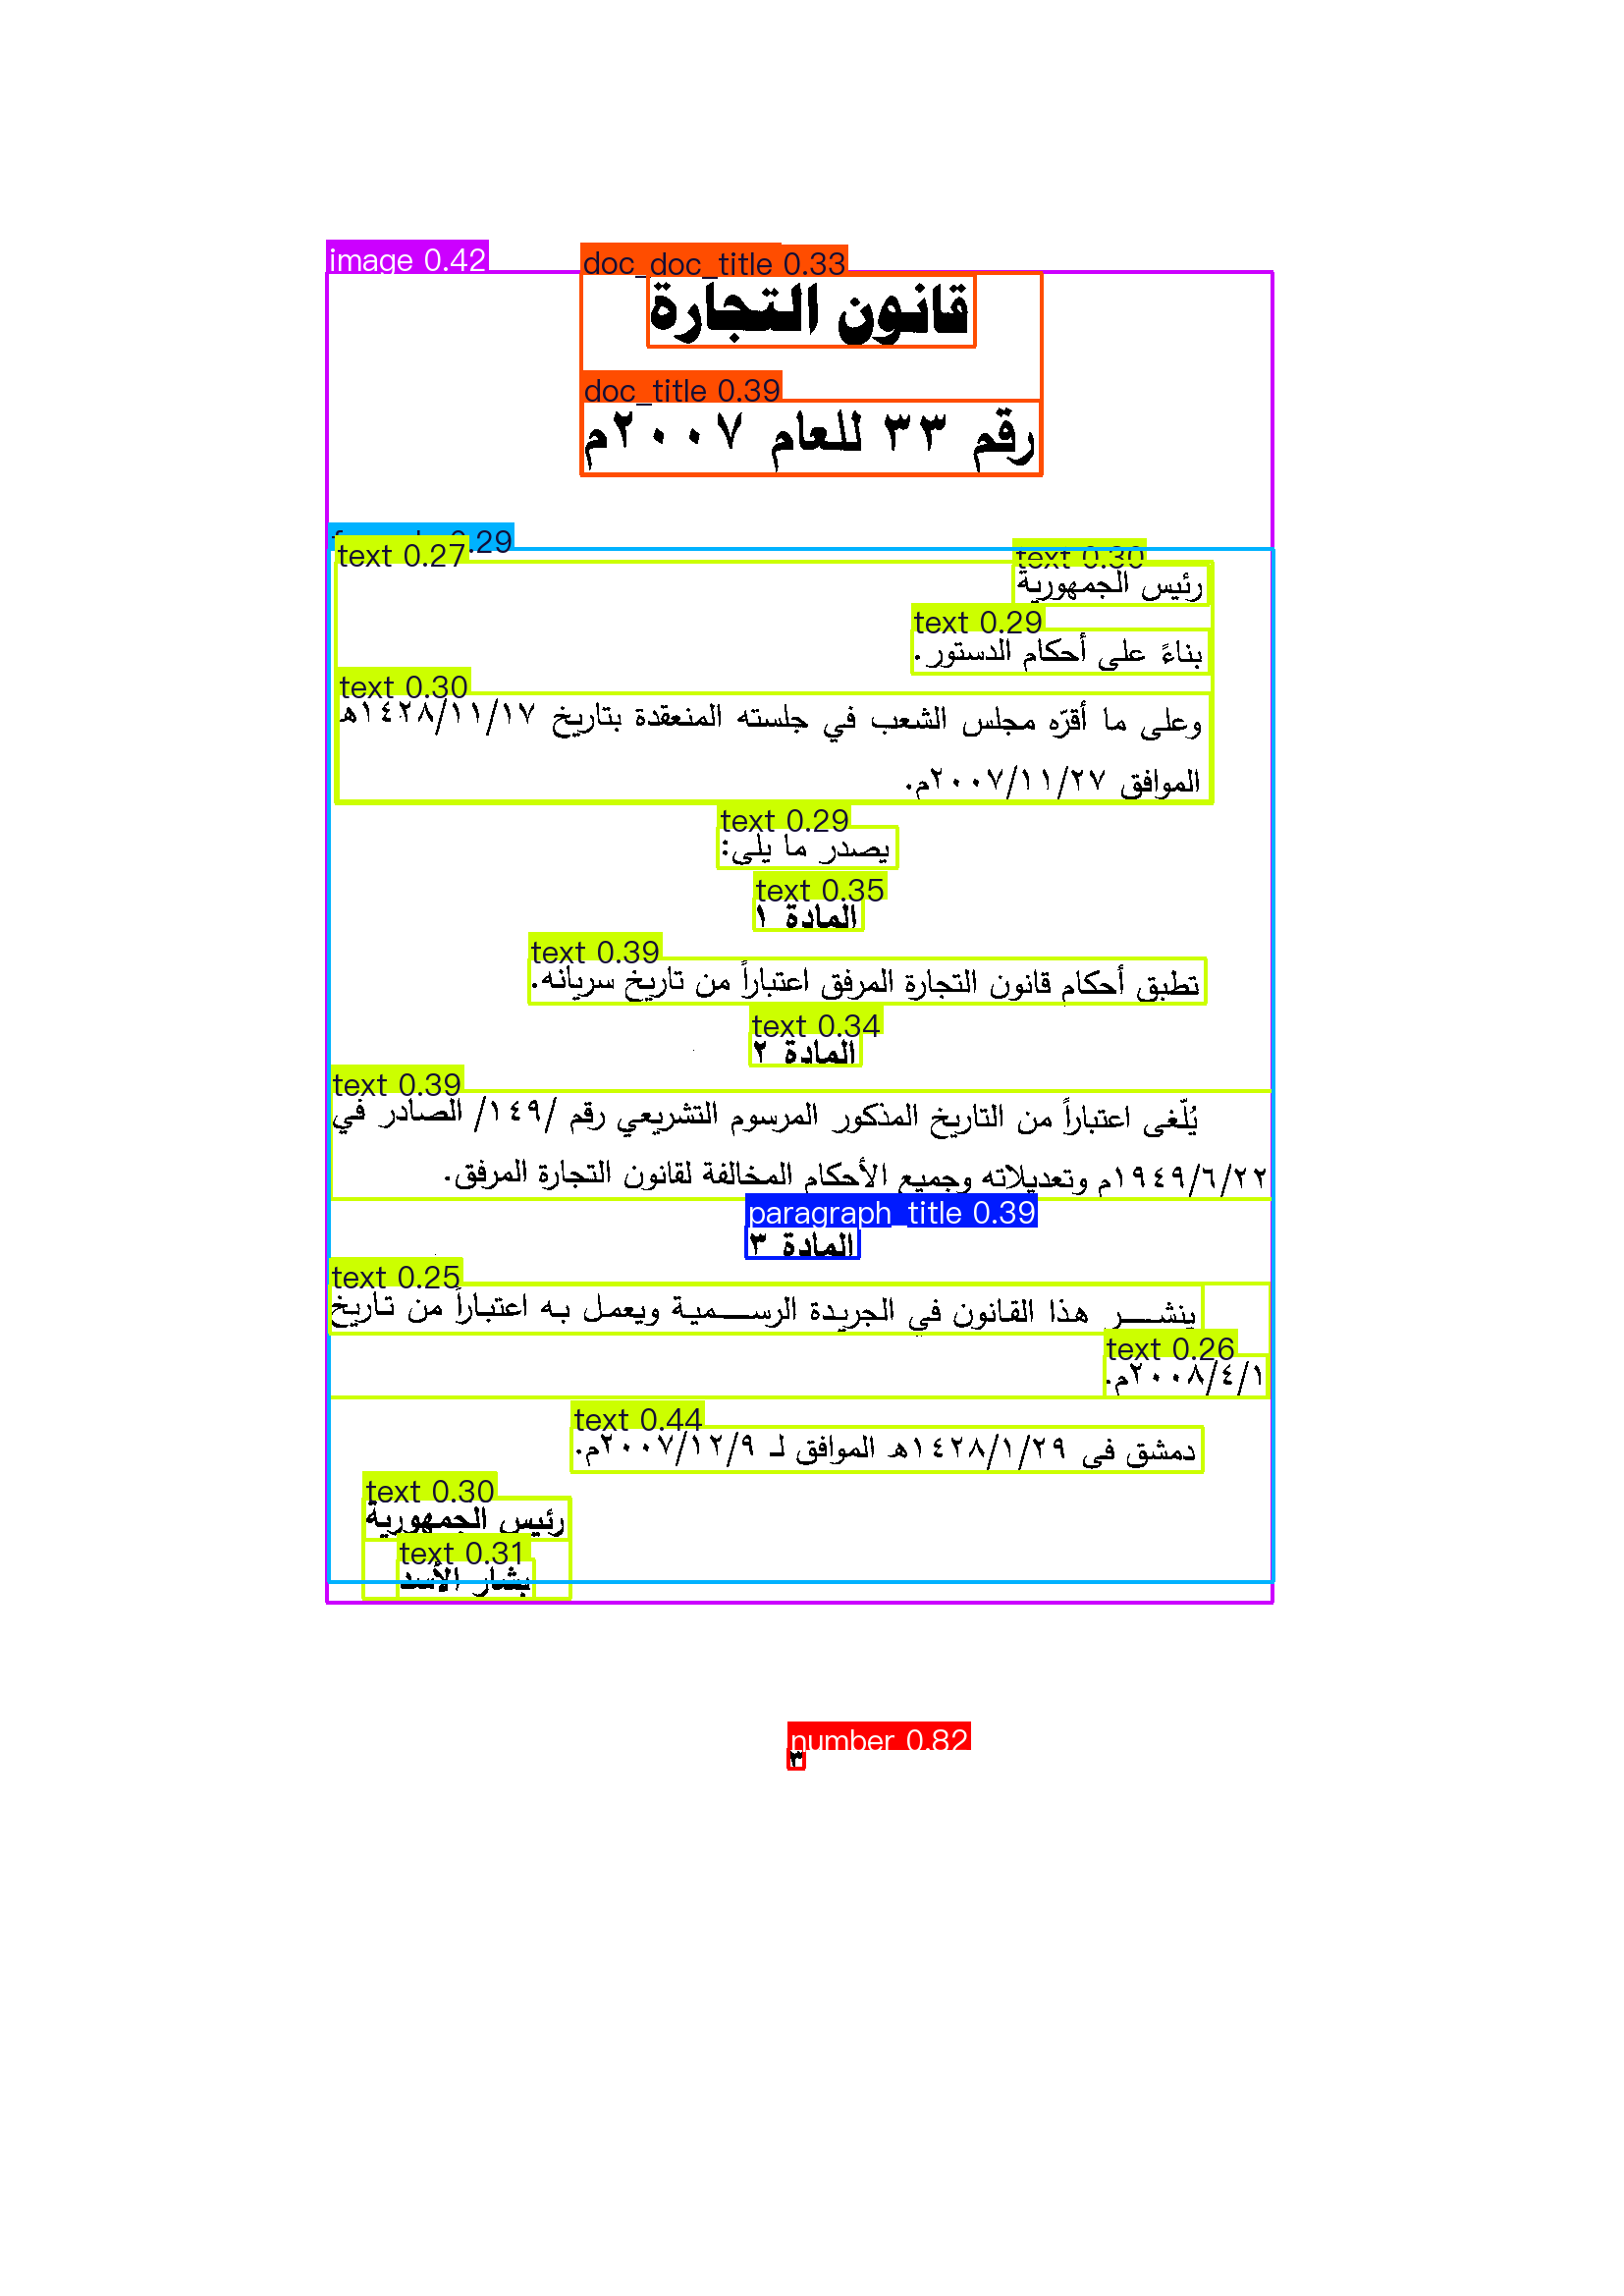

page_0004


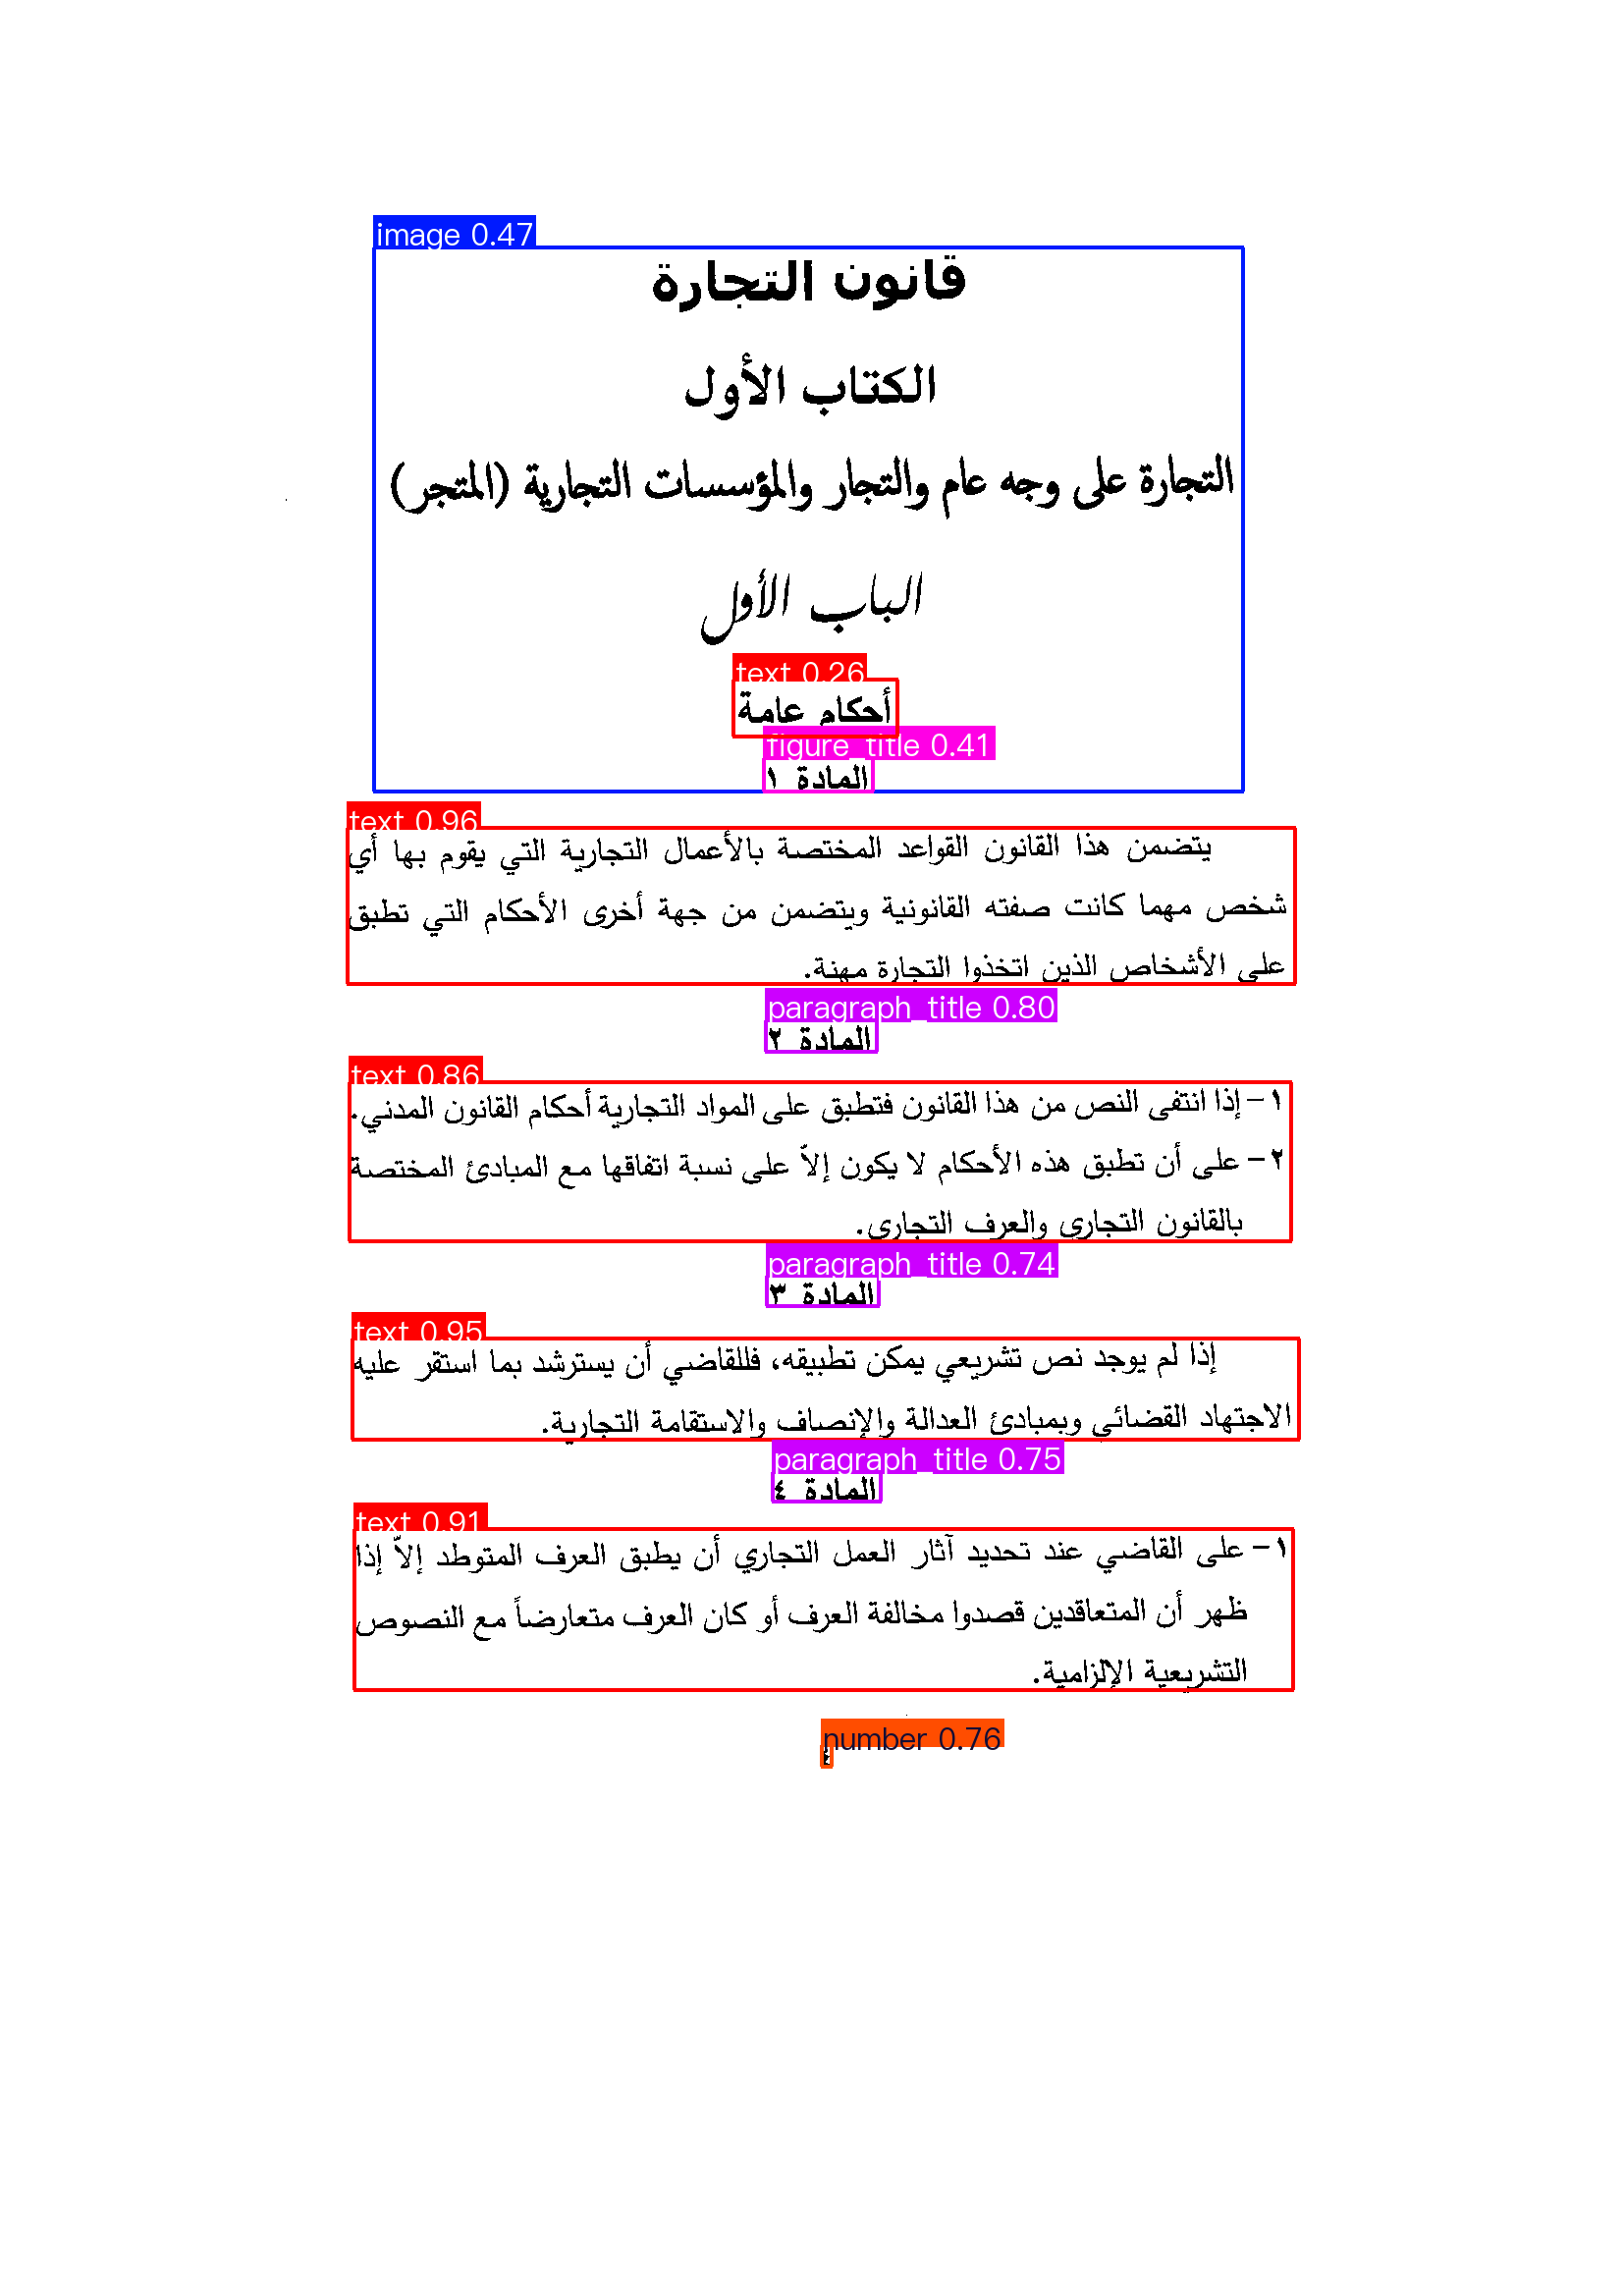

page_0005


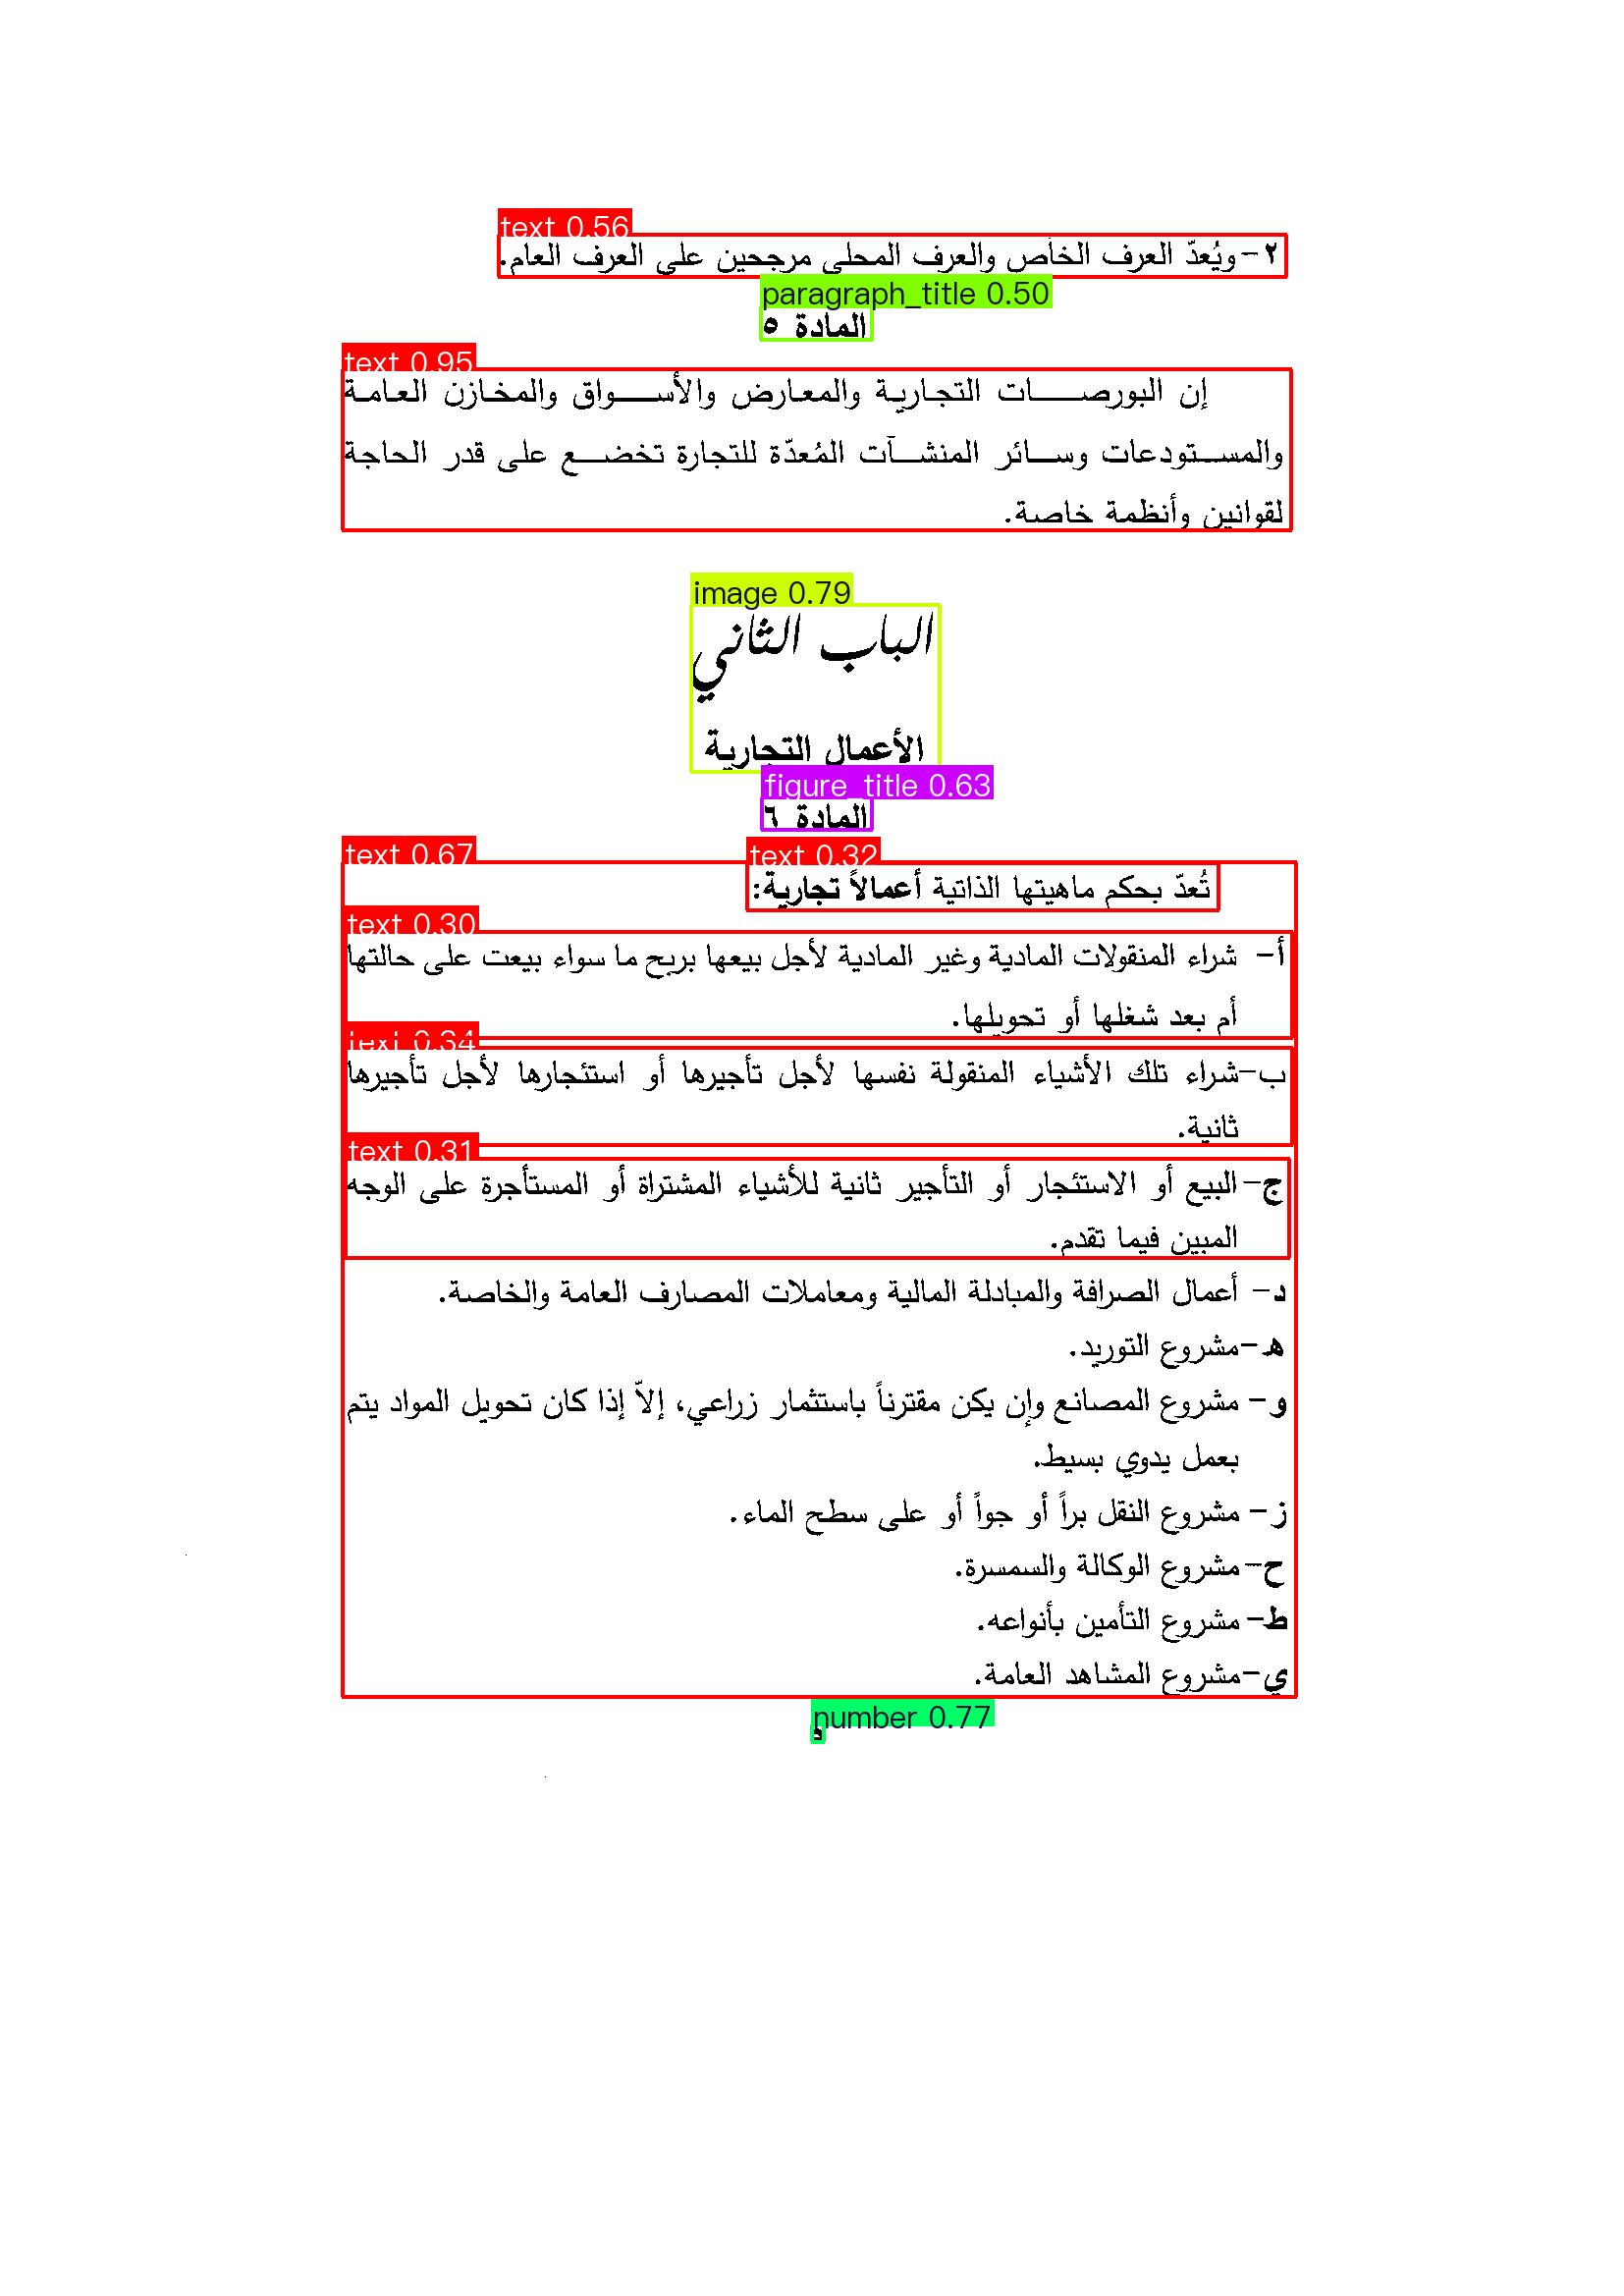

page_0006


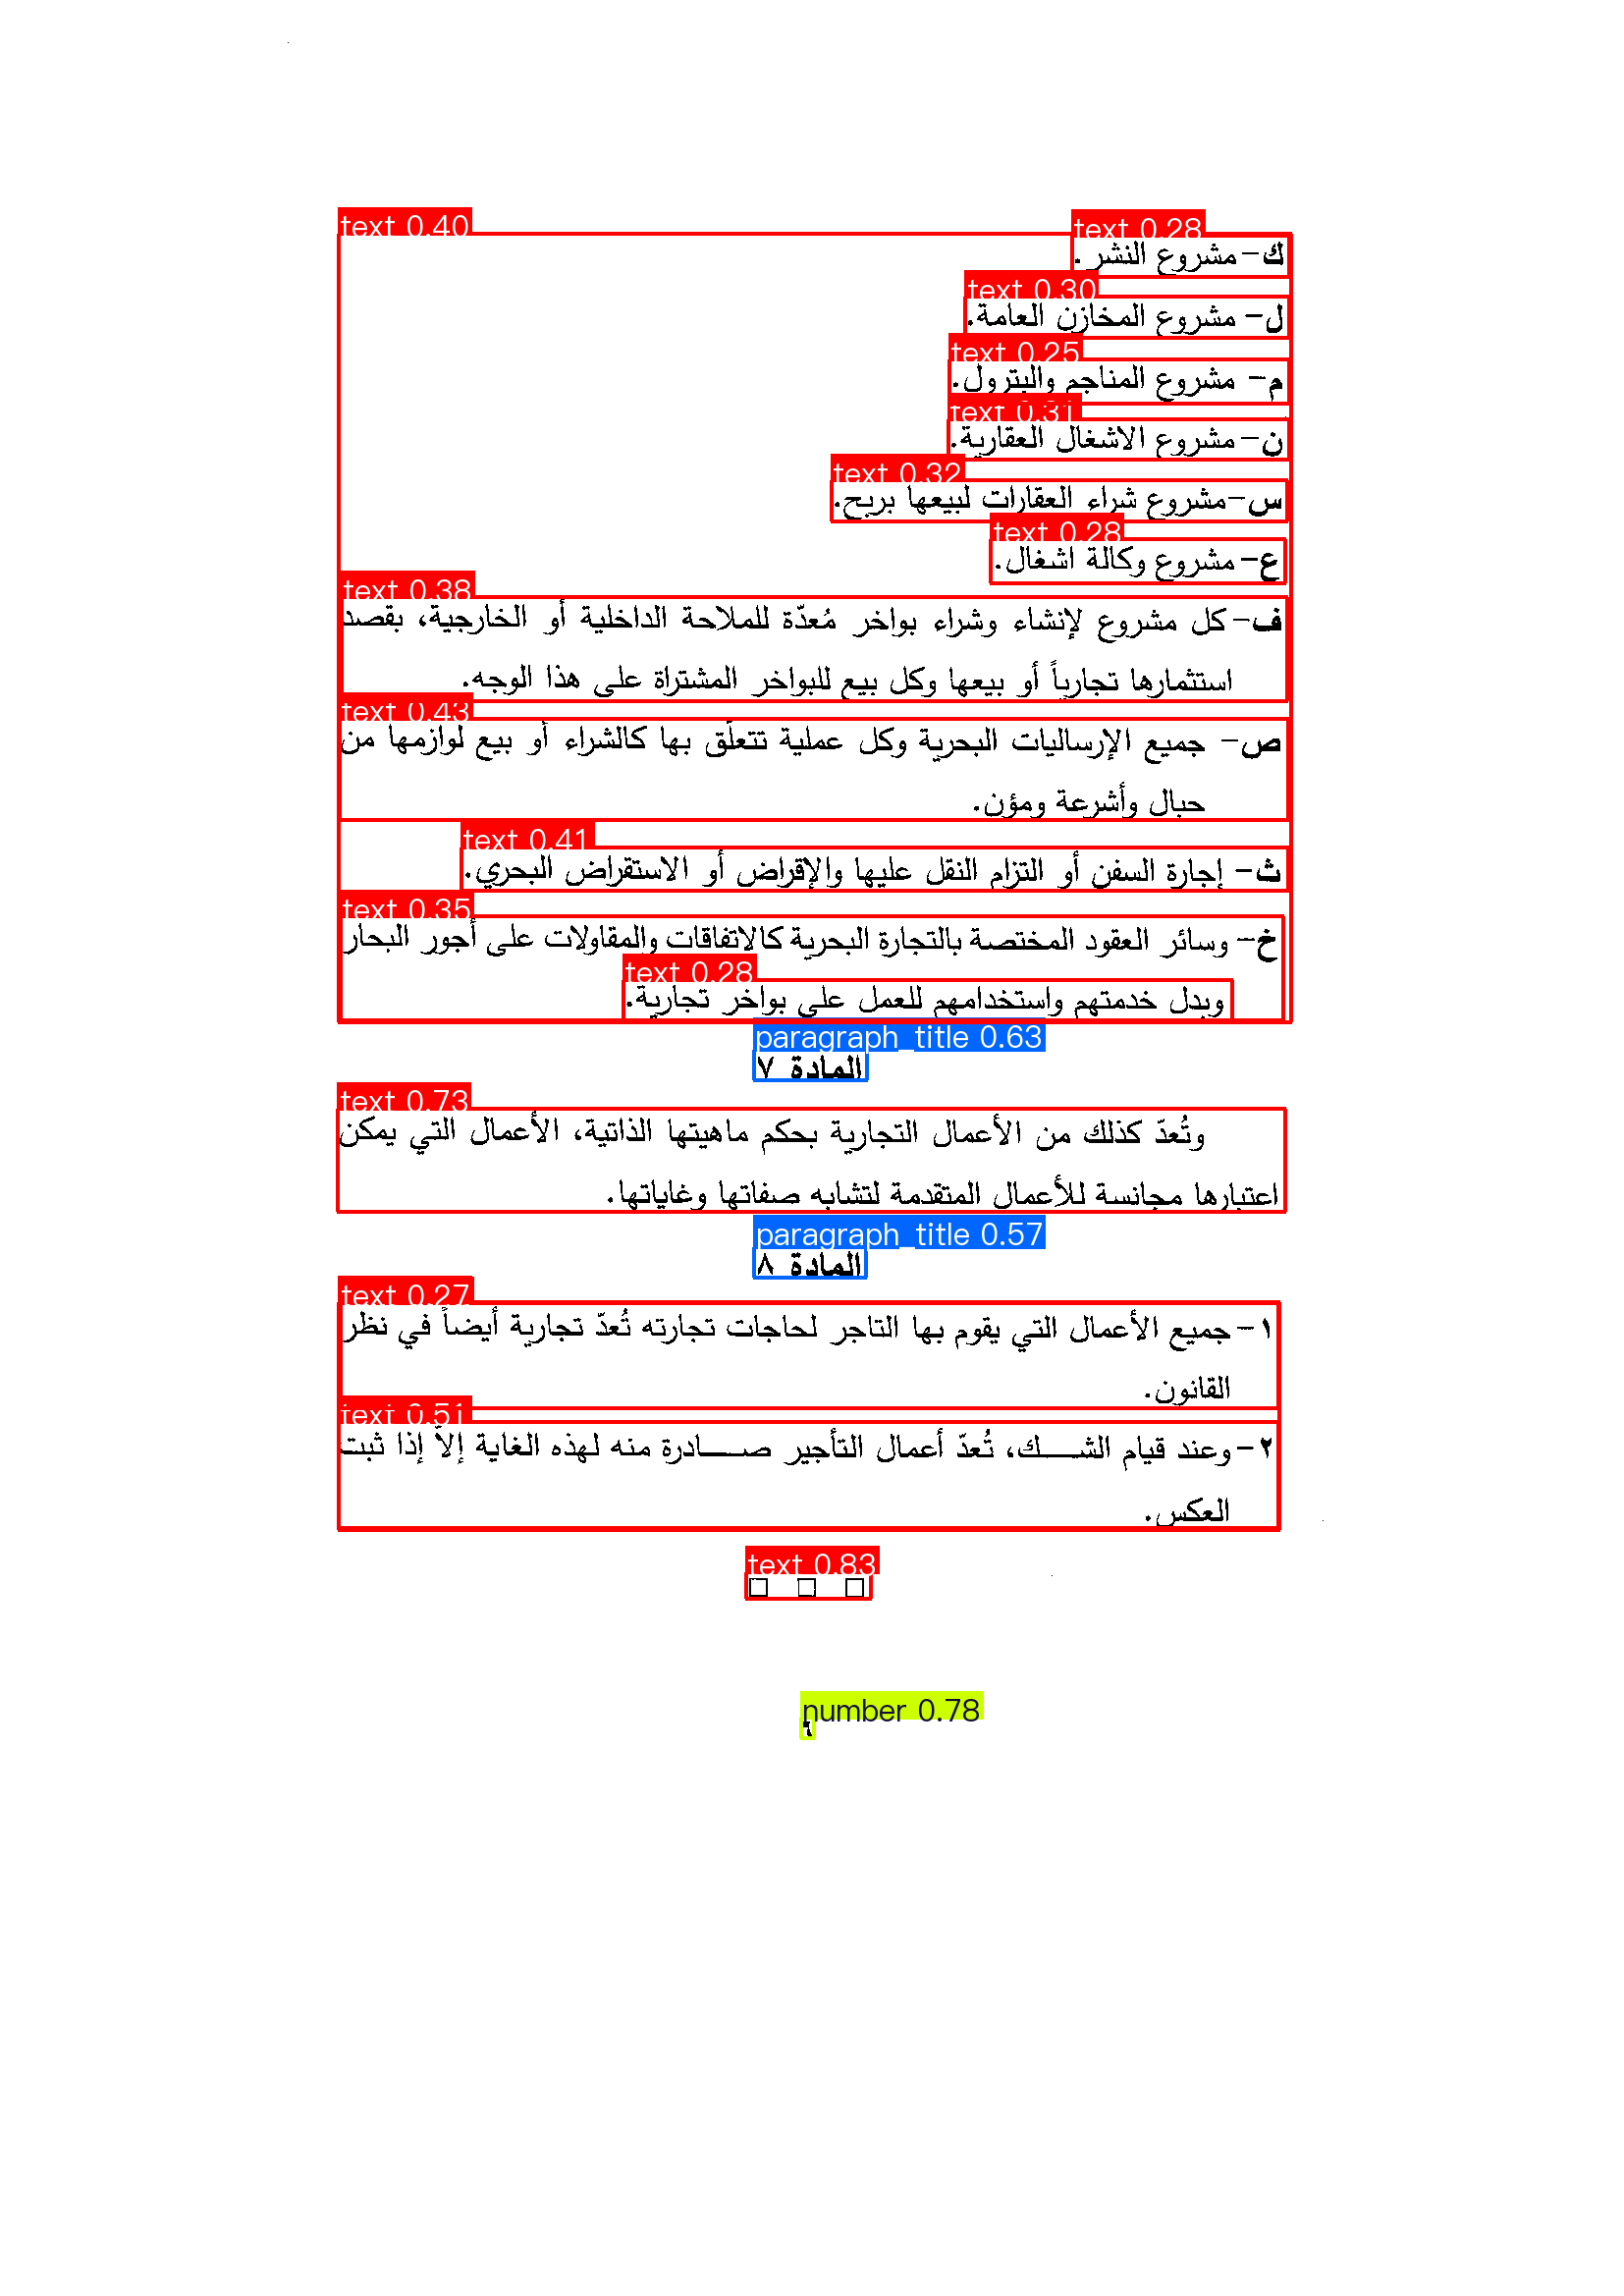

page_0007


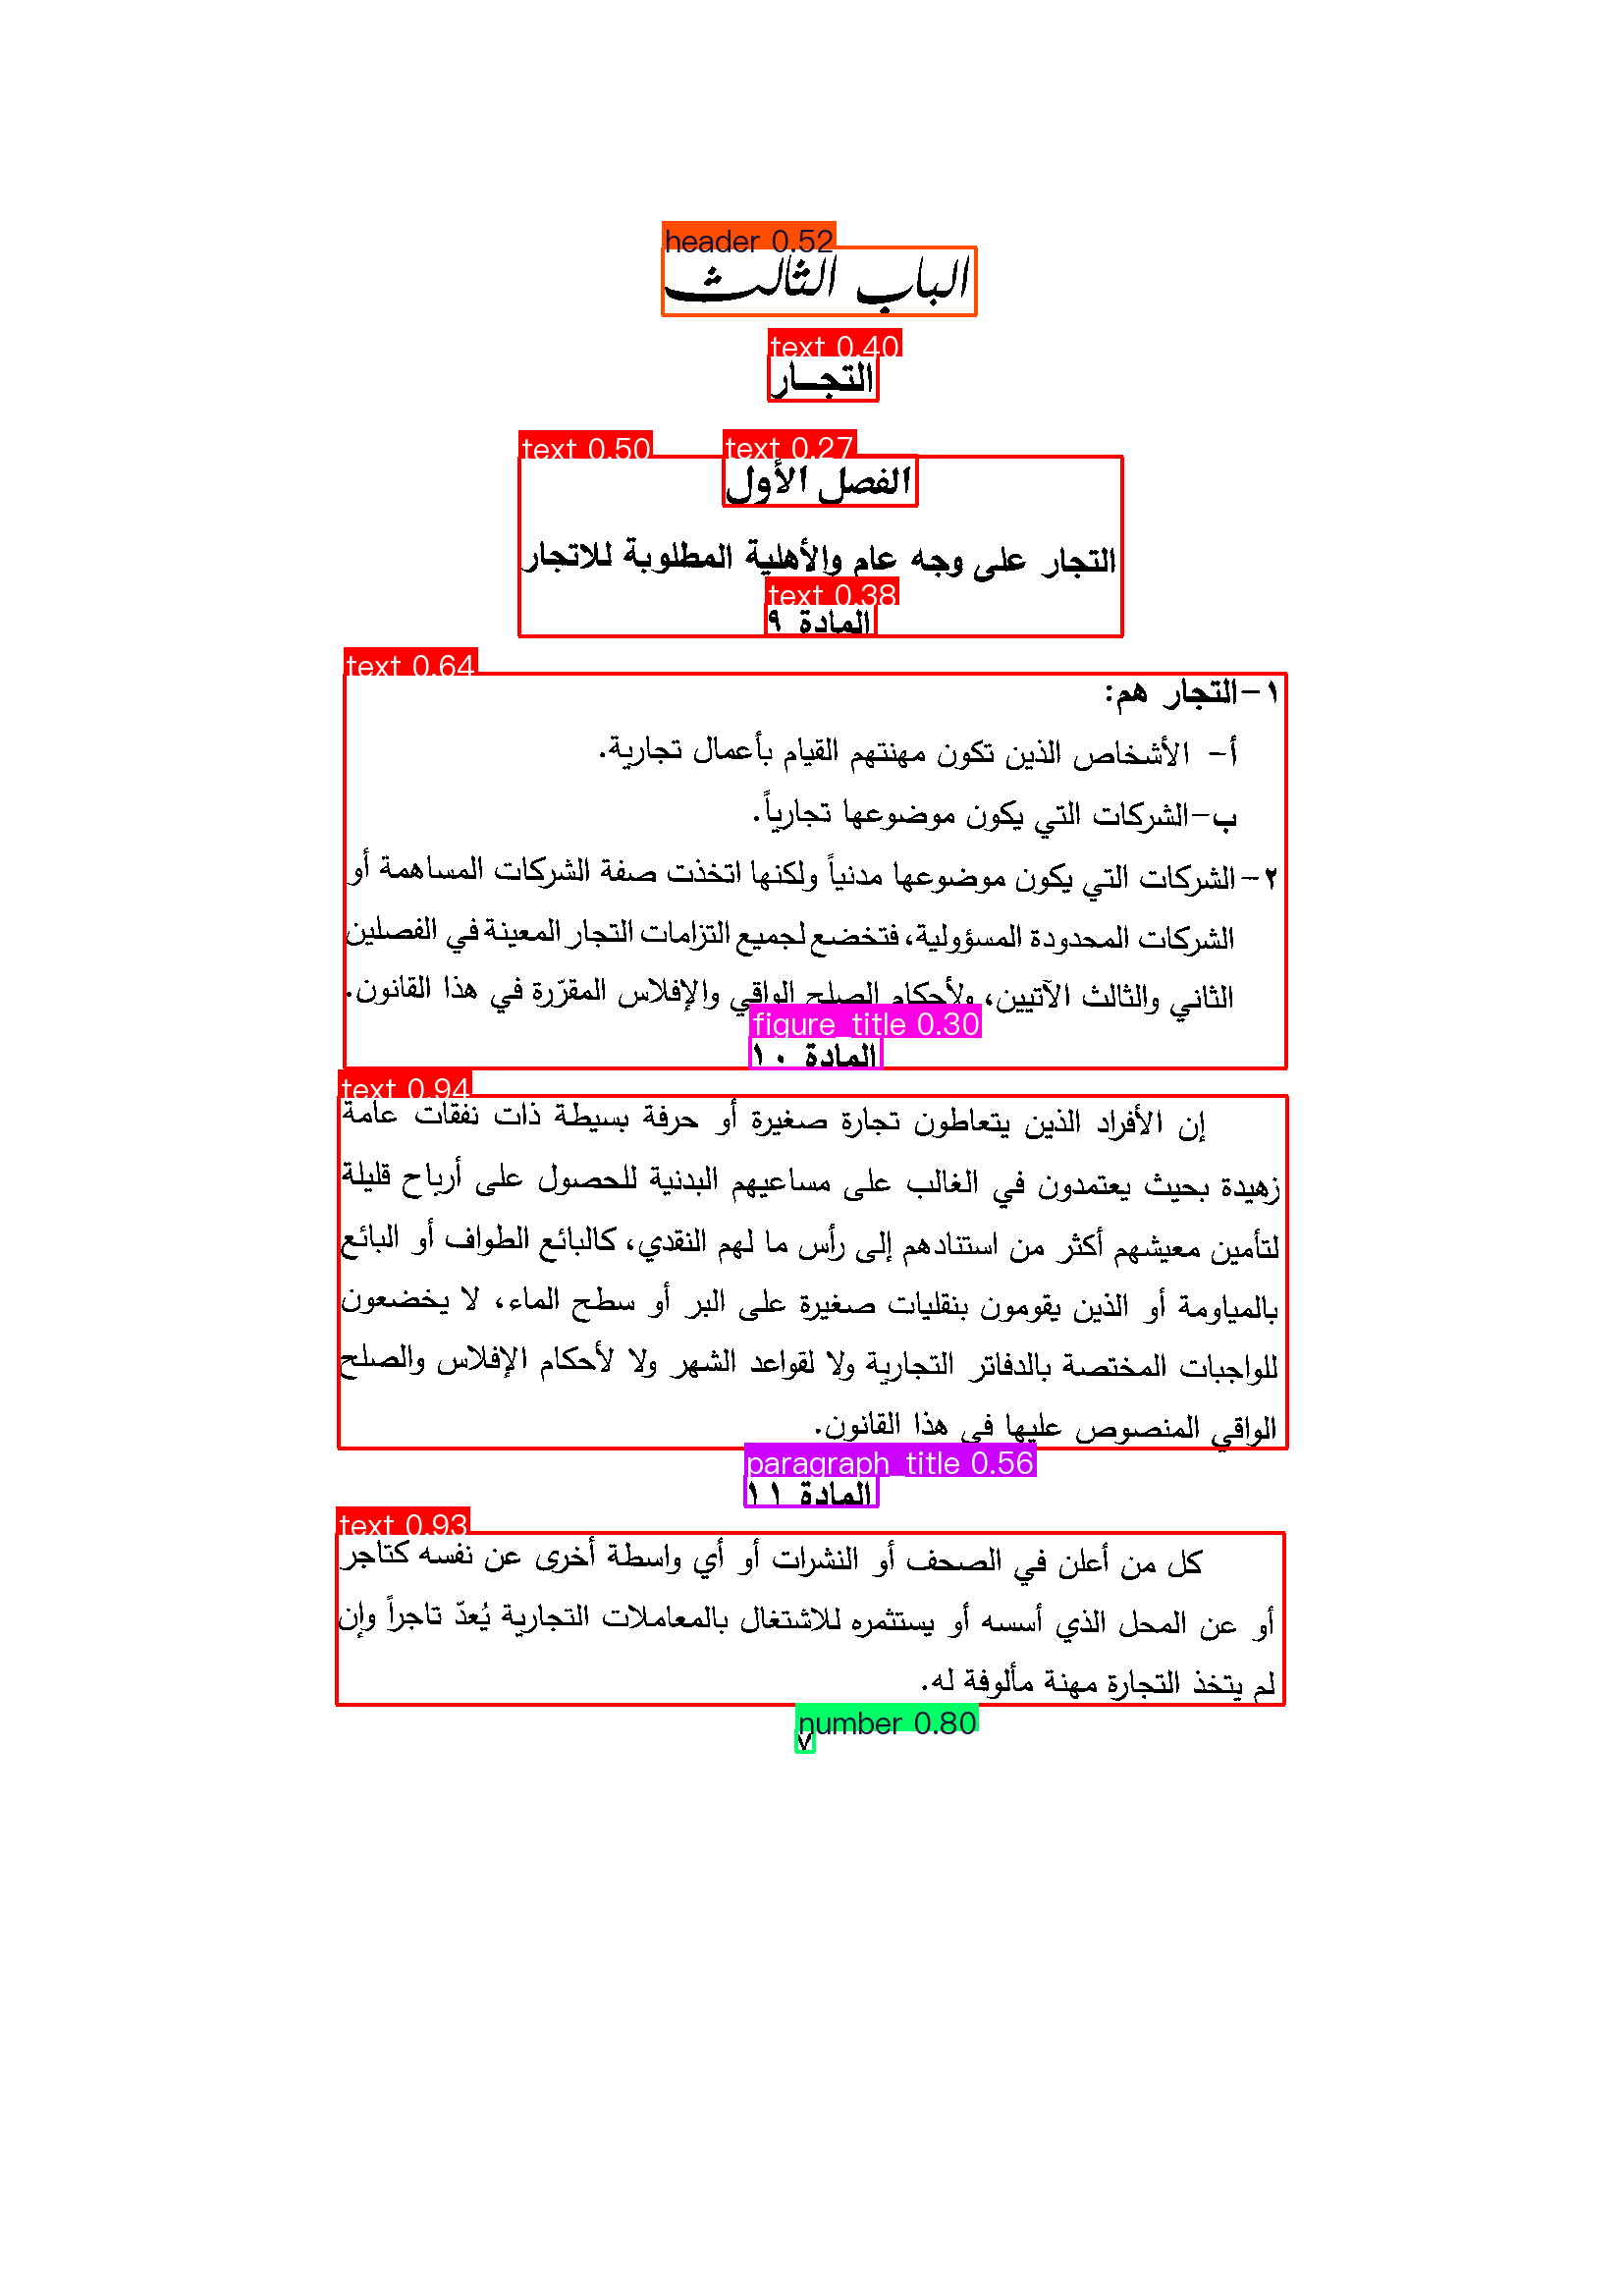

page_0008


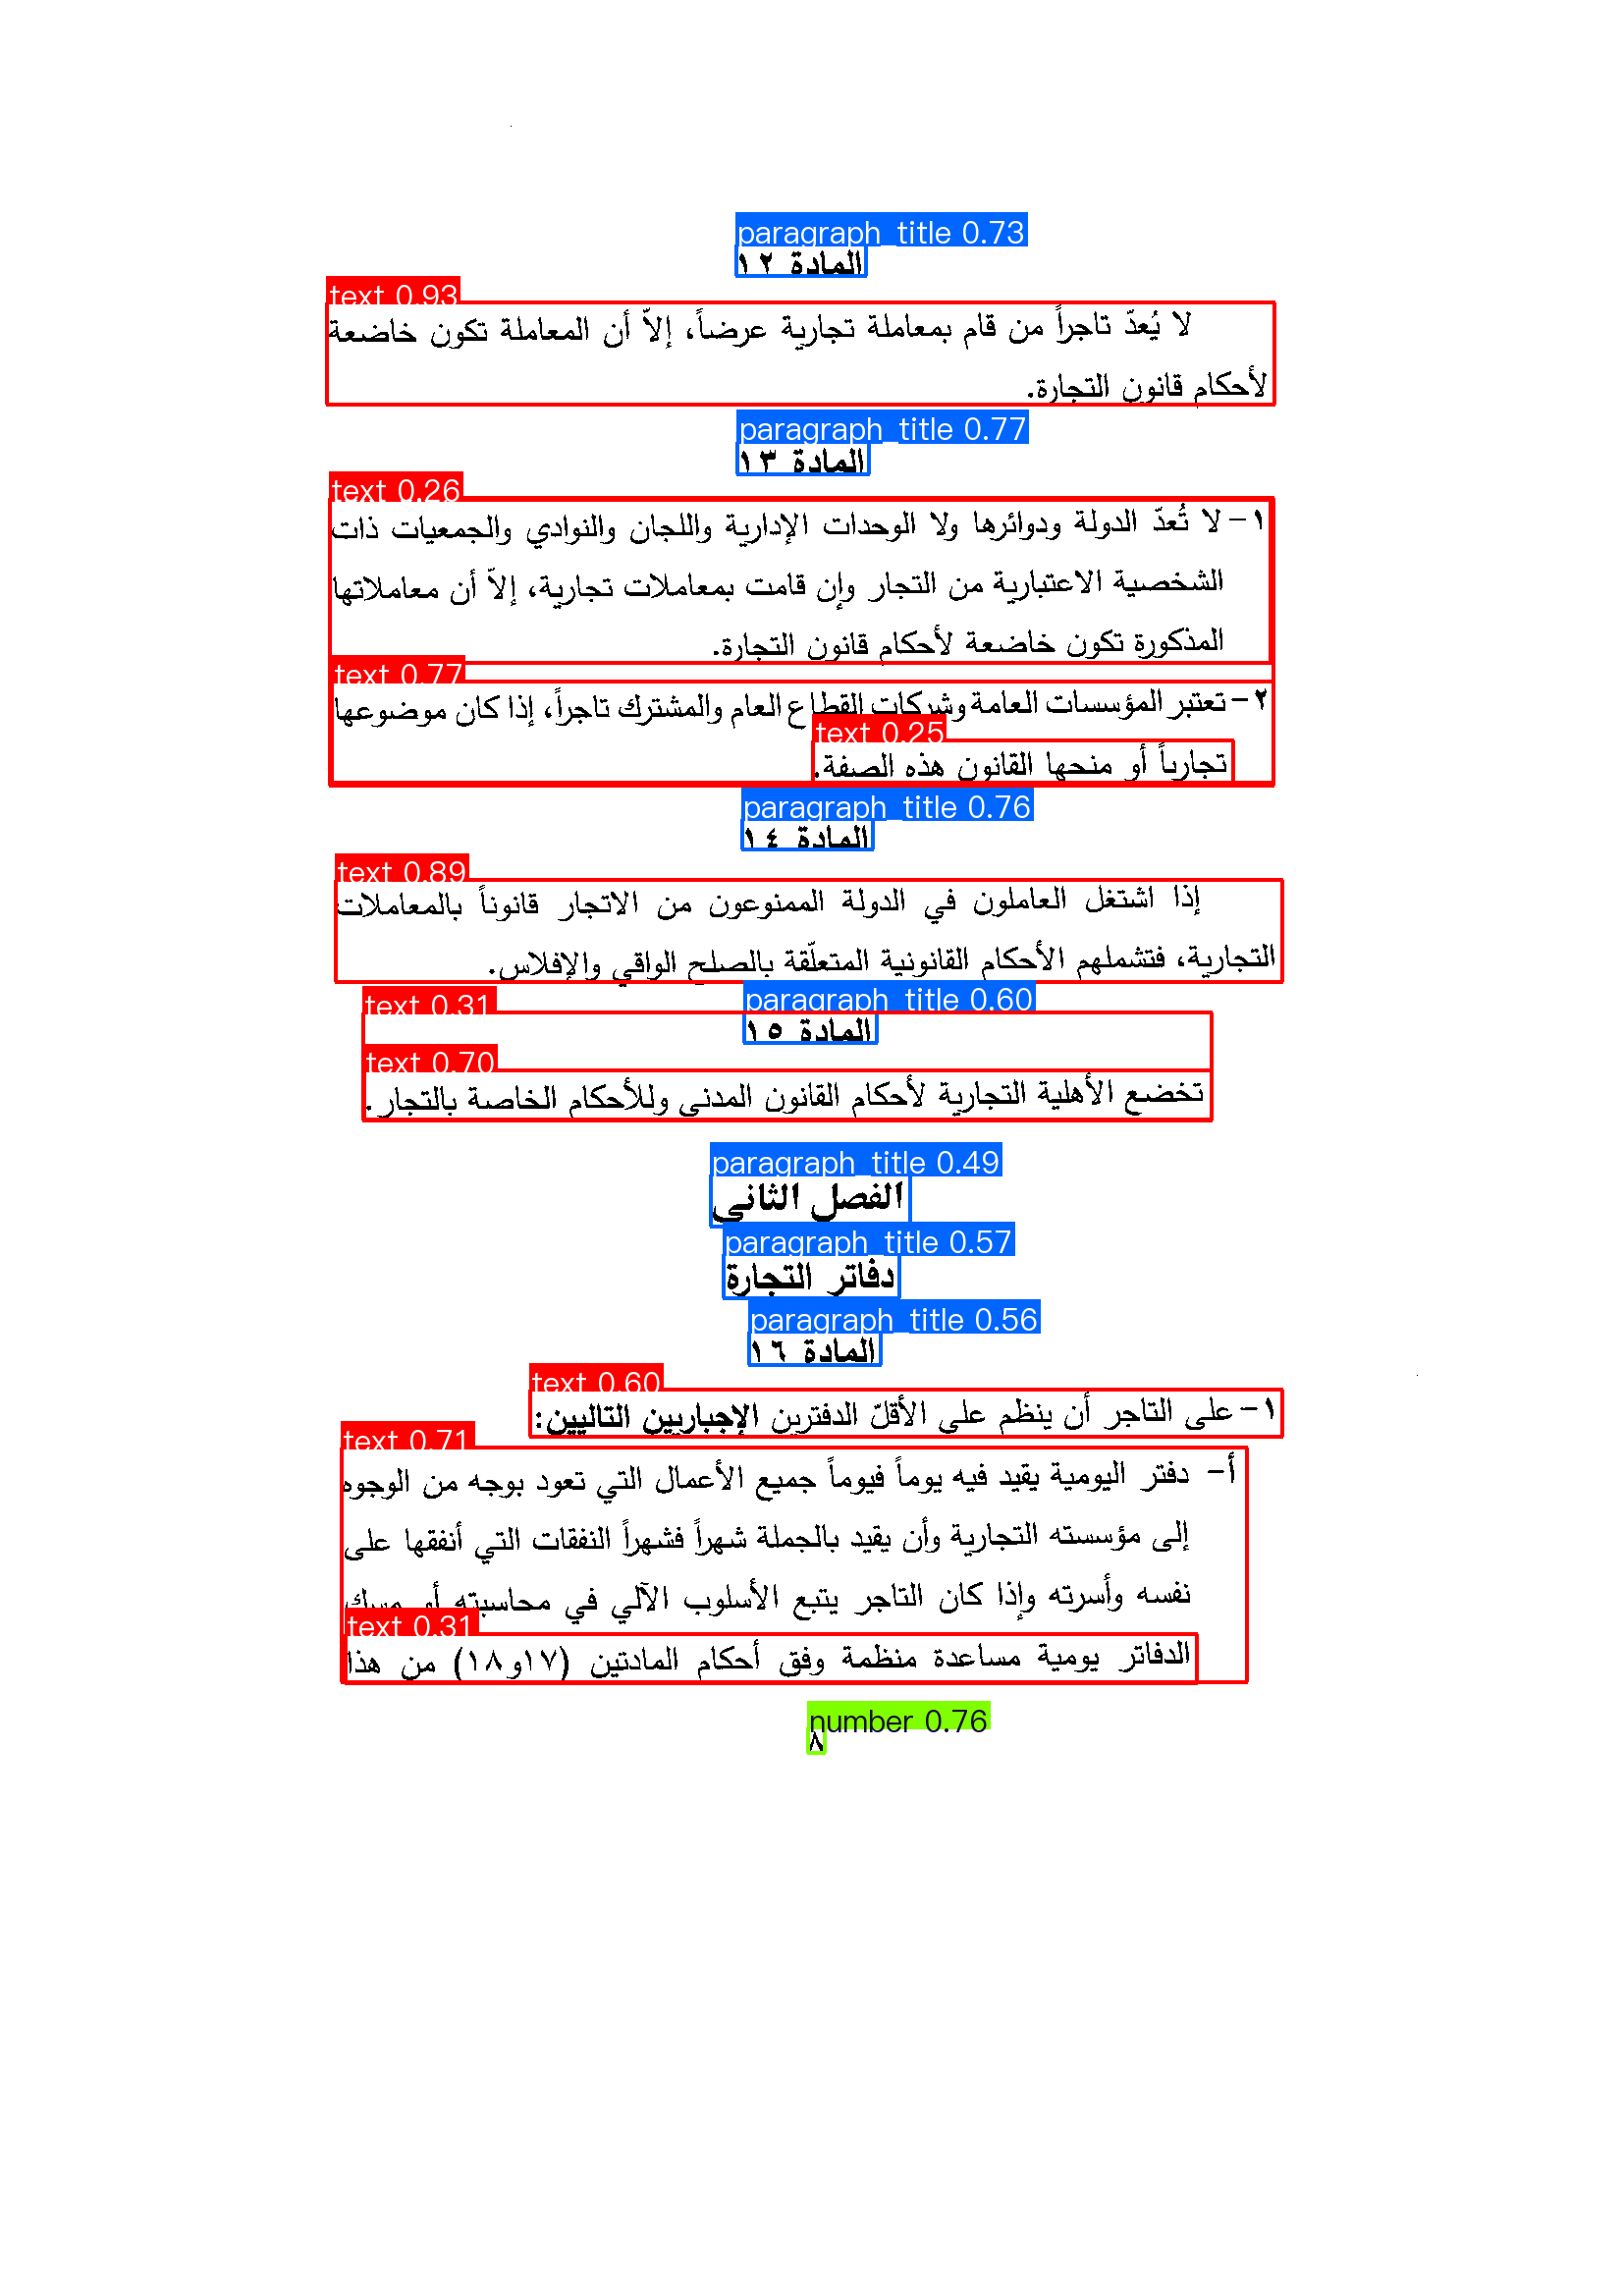

page_0009


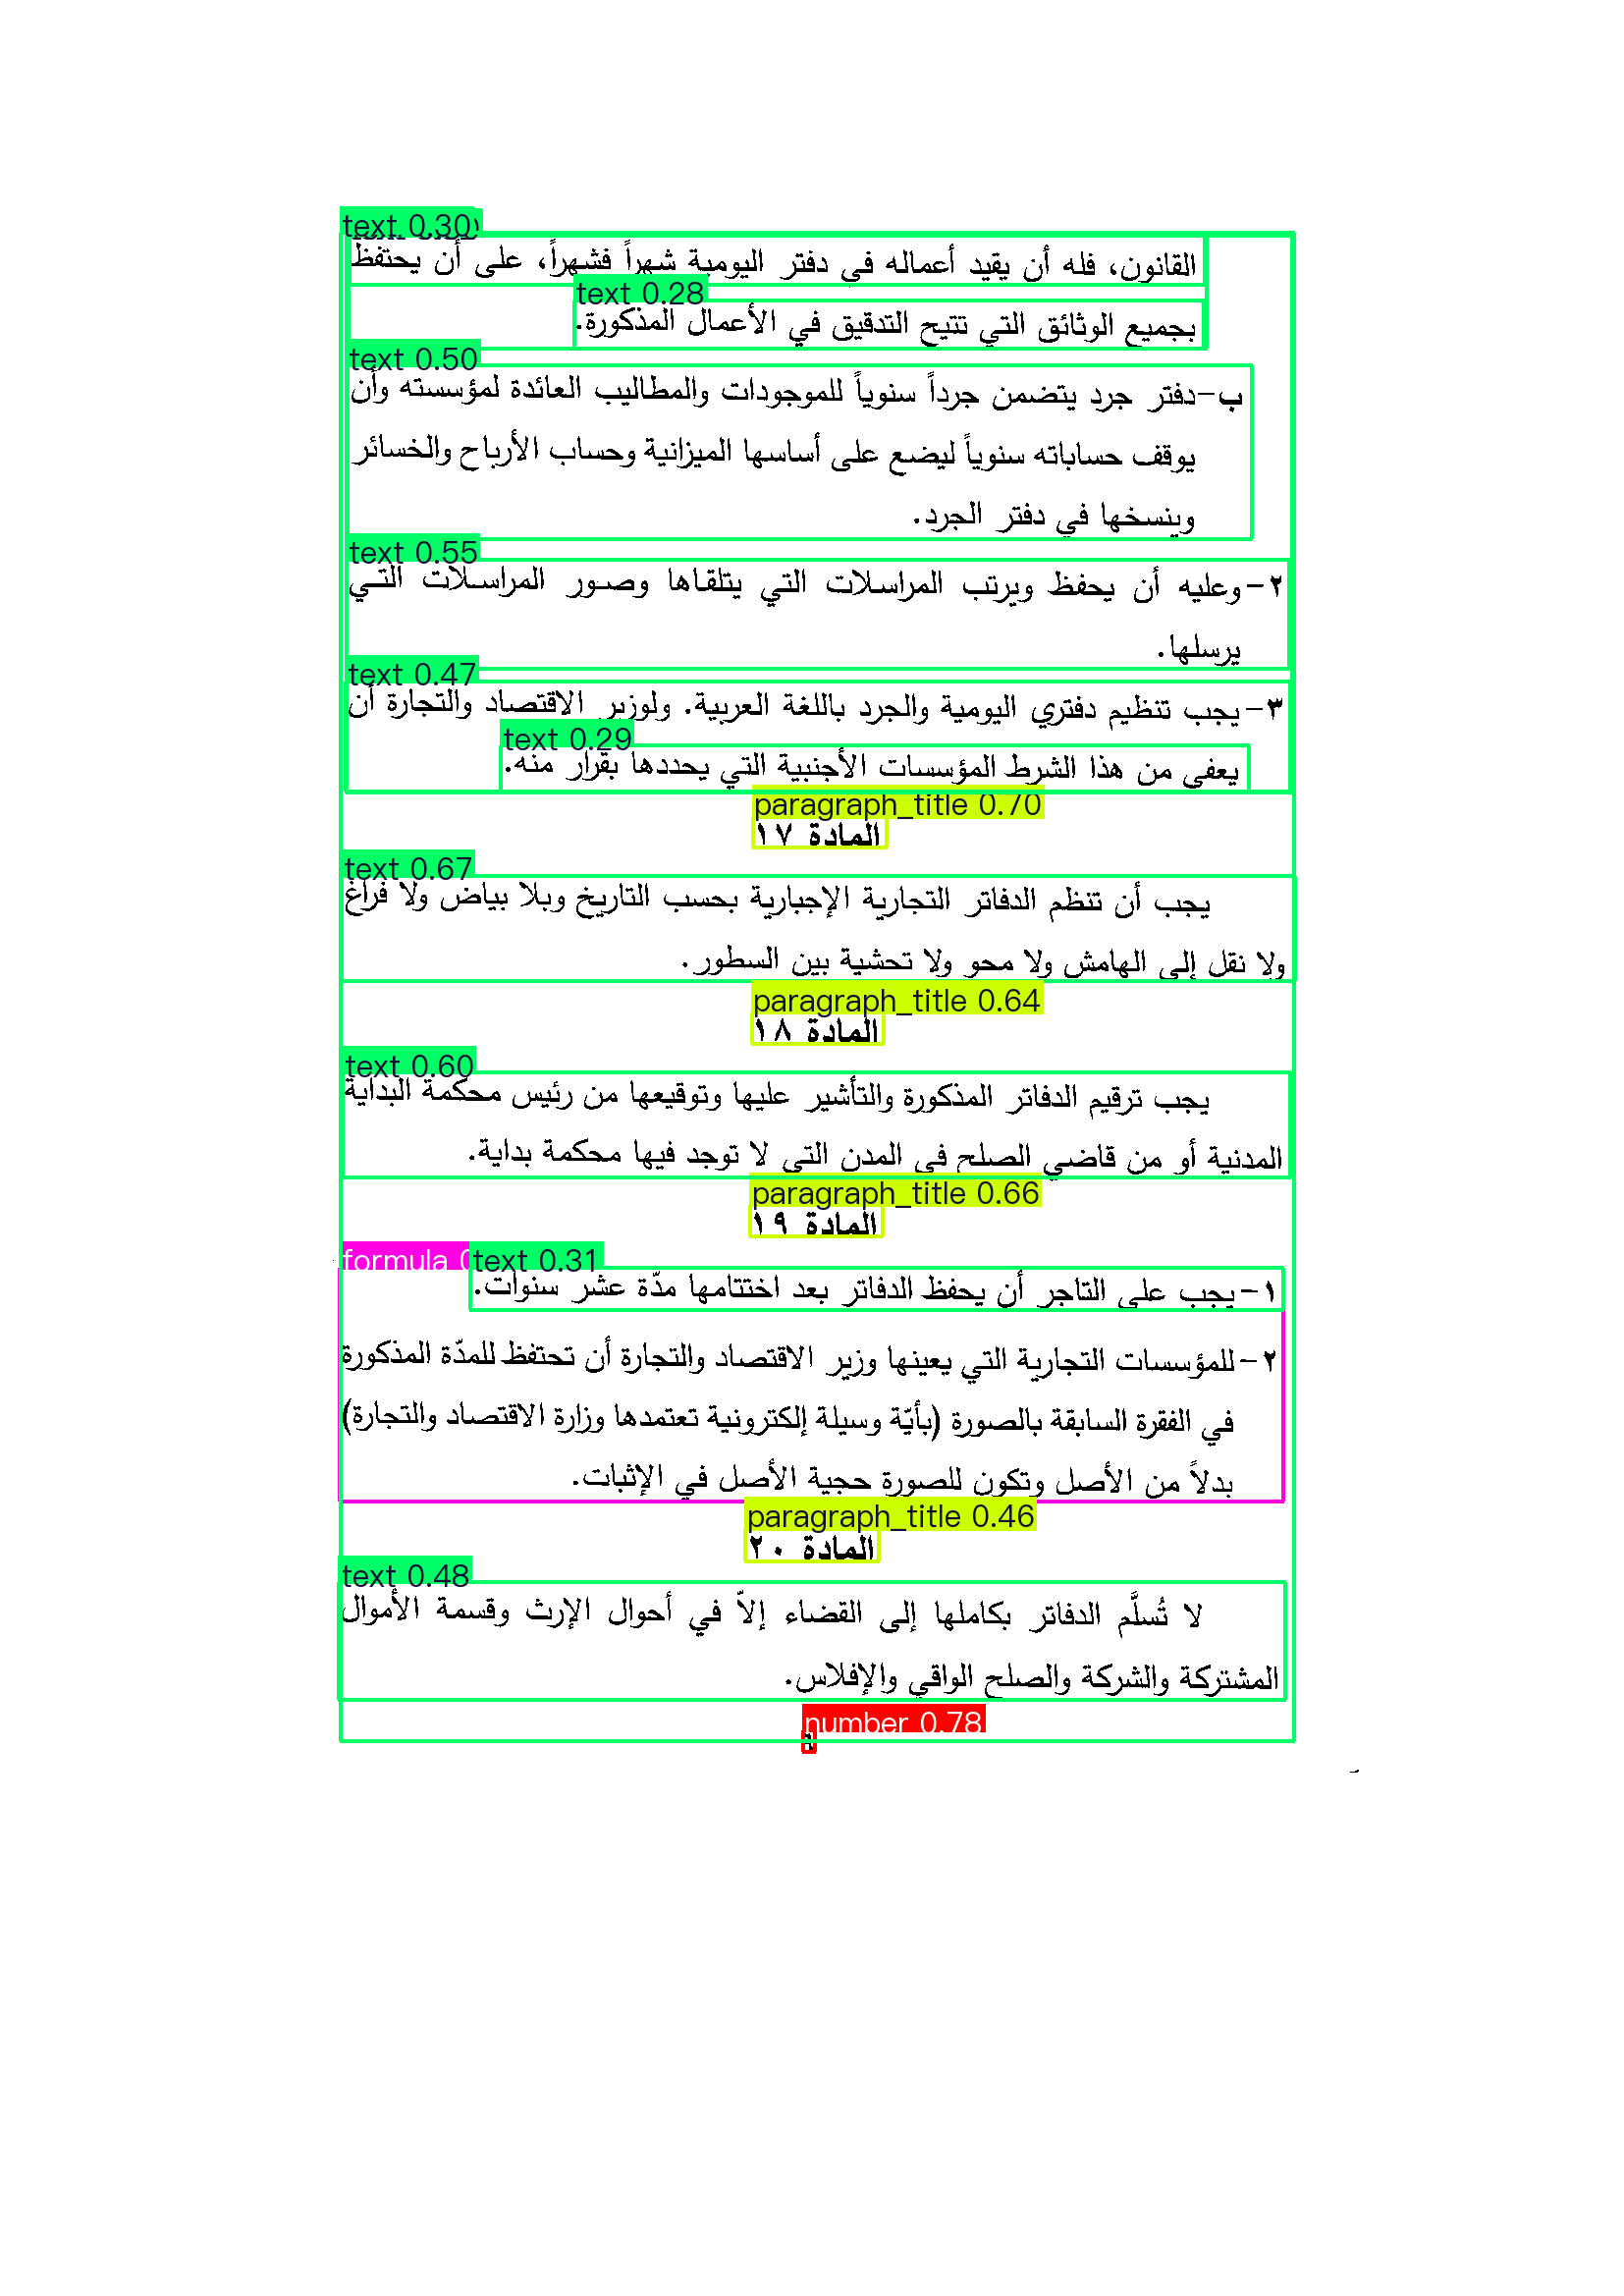

page_0010


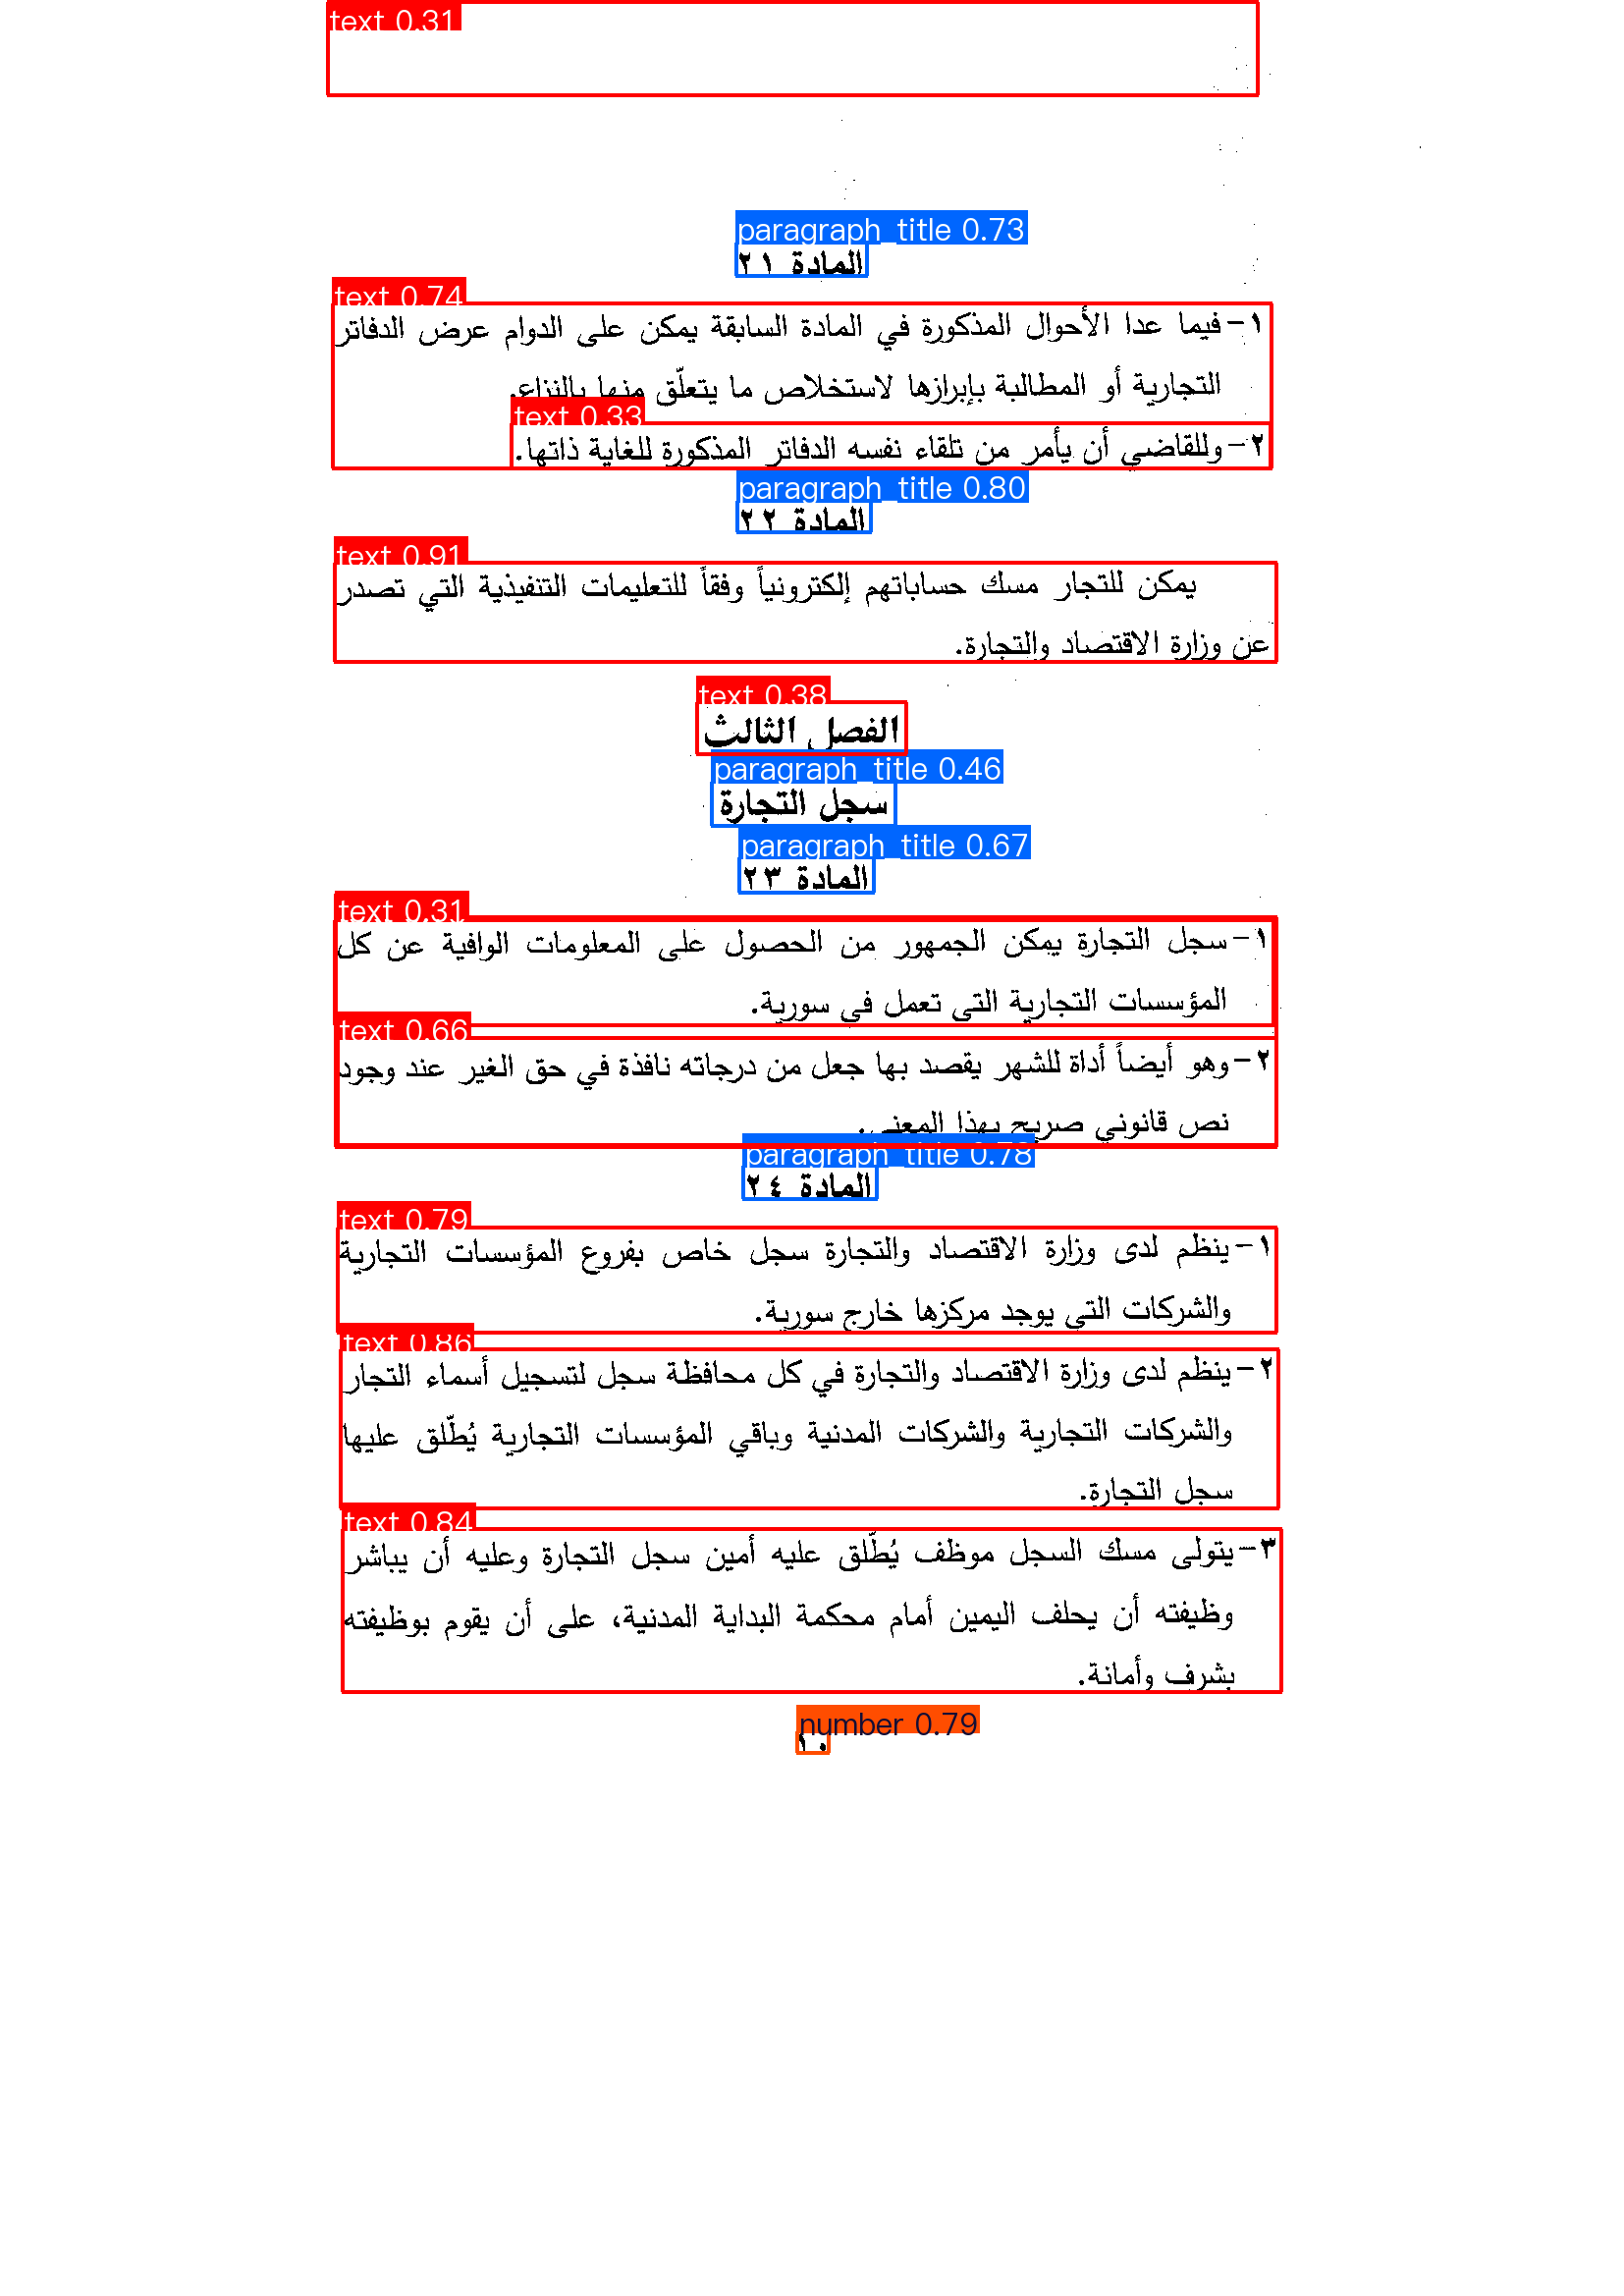

page_0011


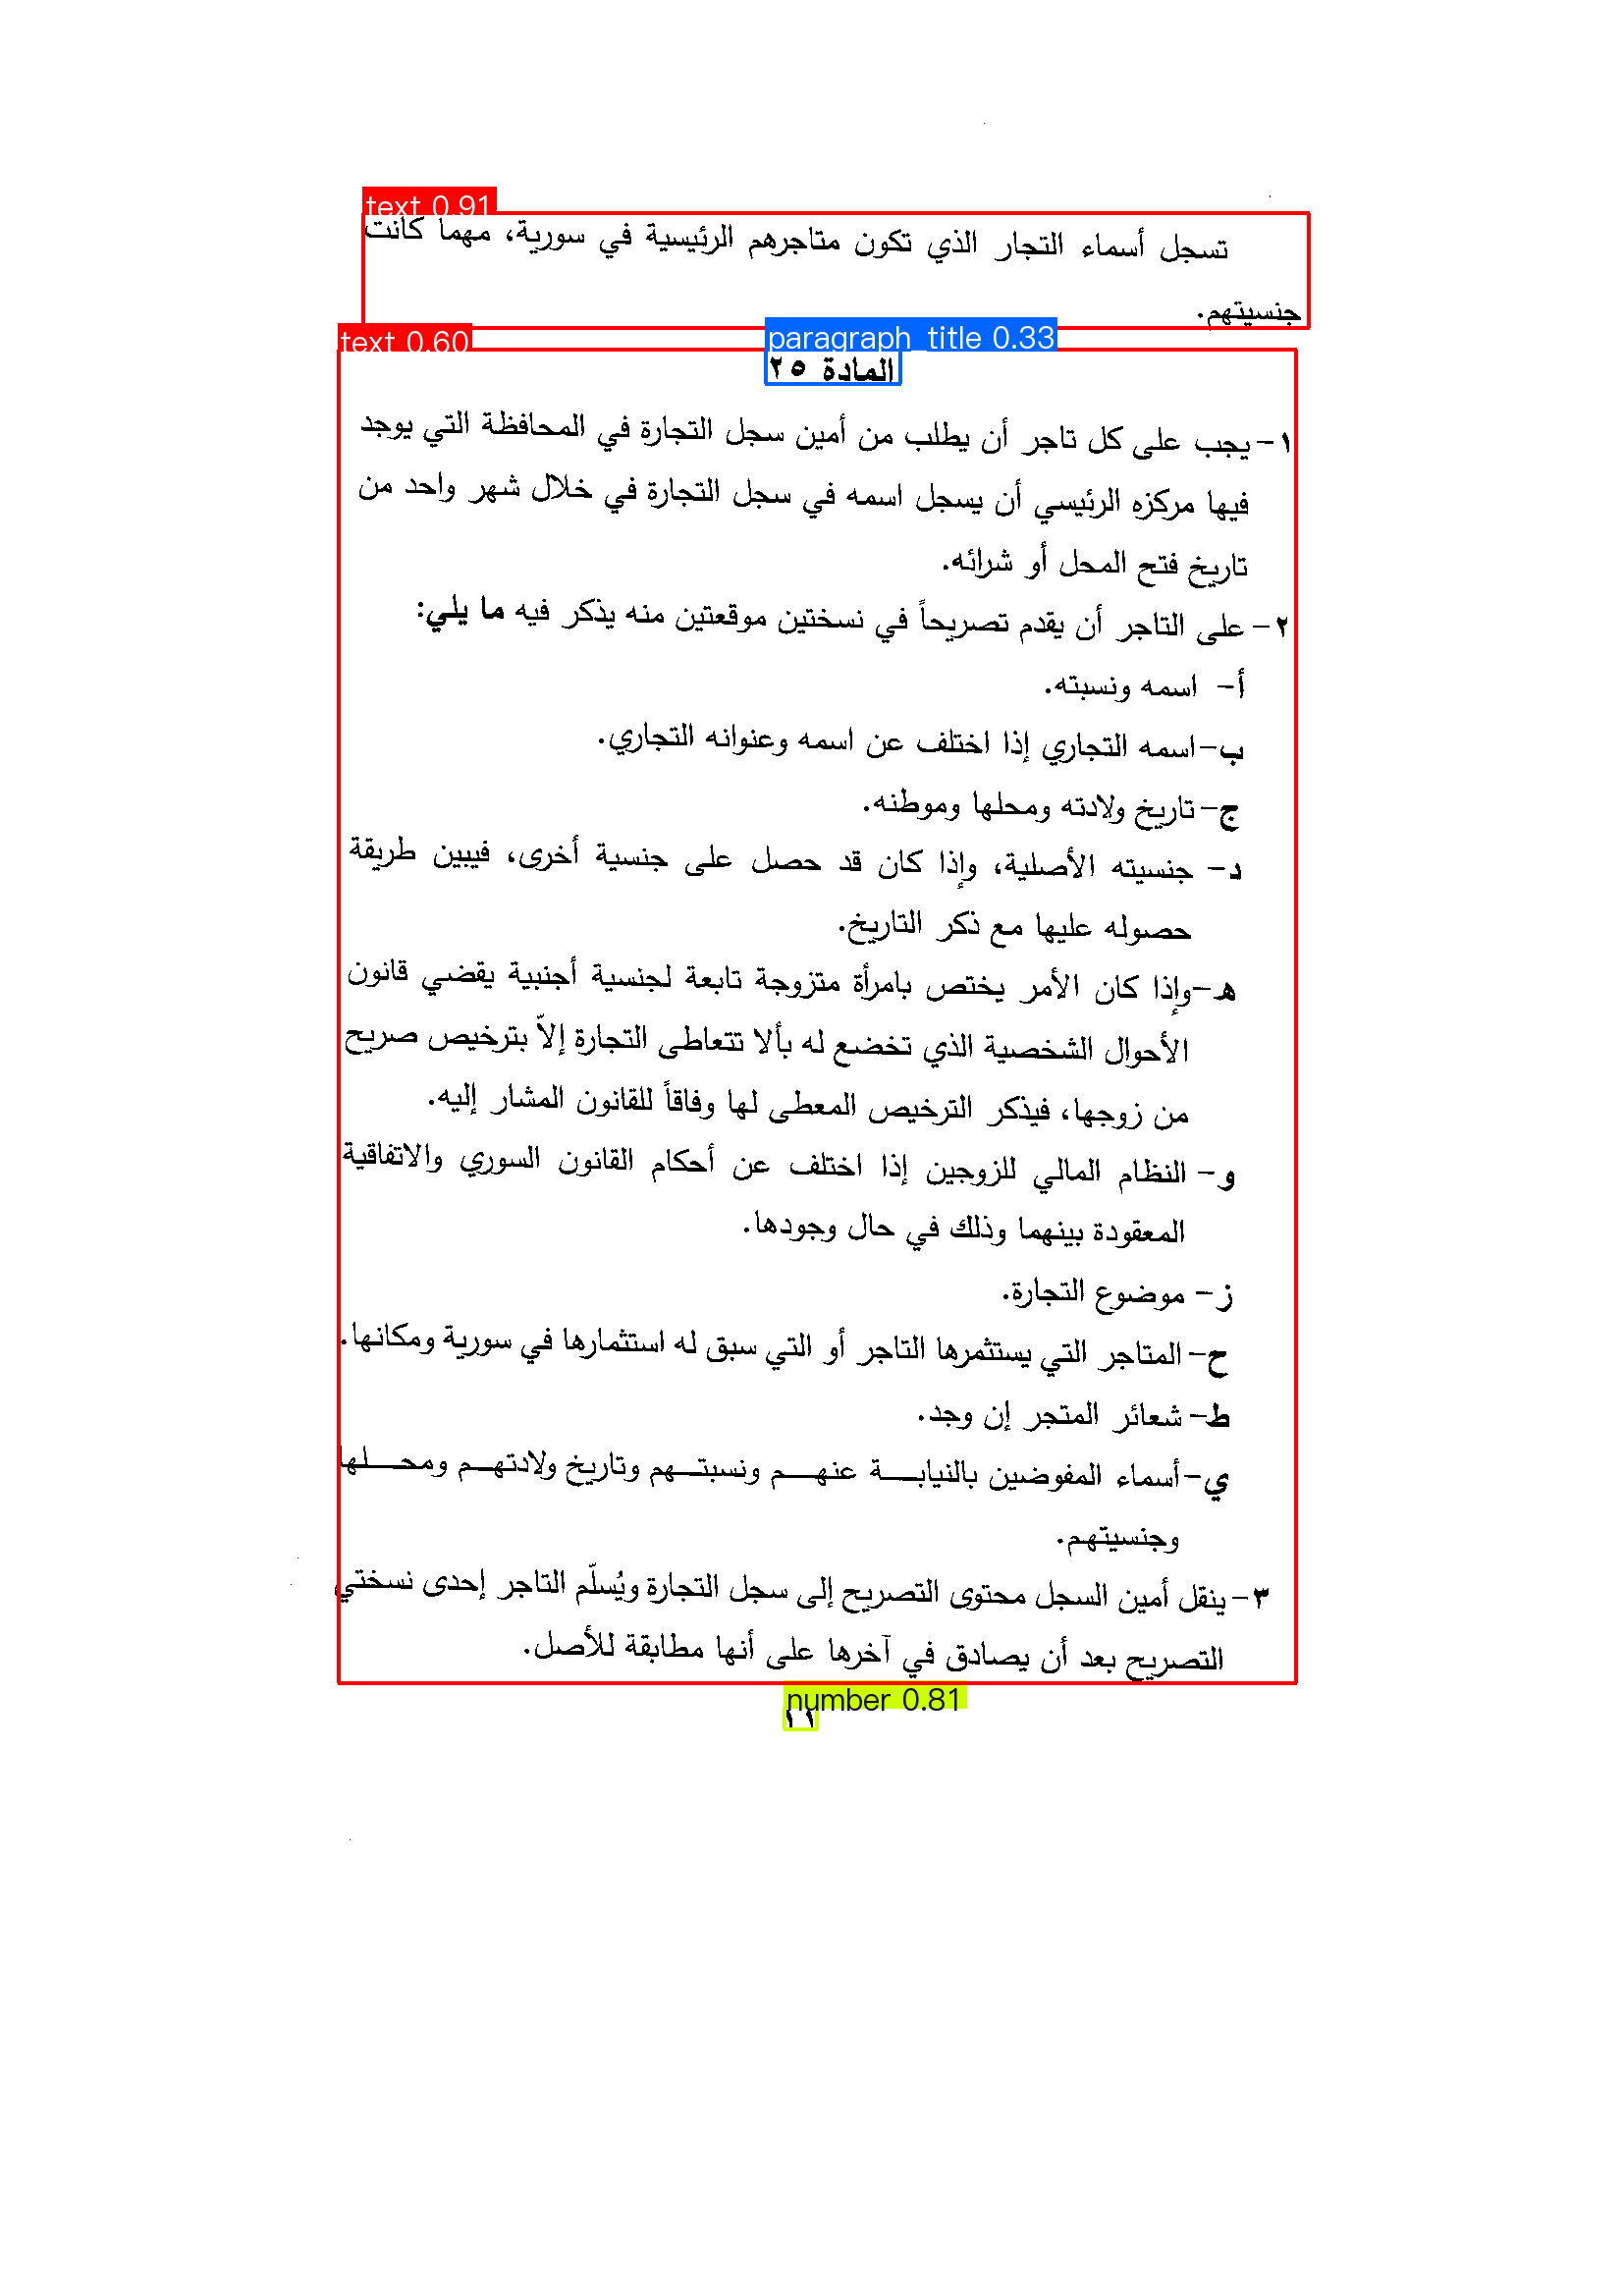

page_0012


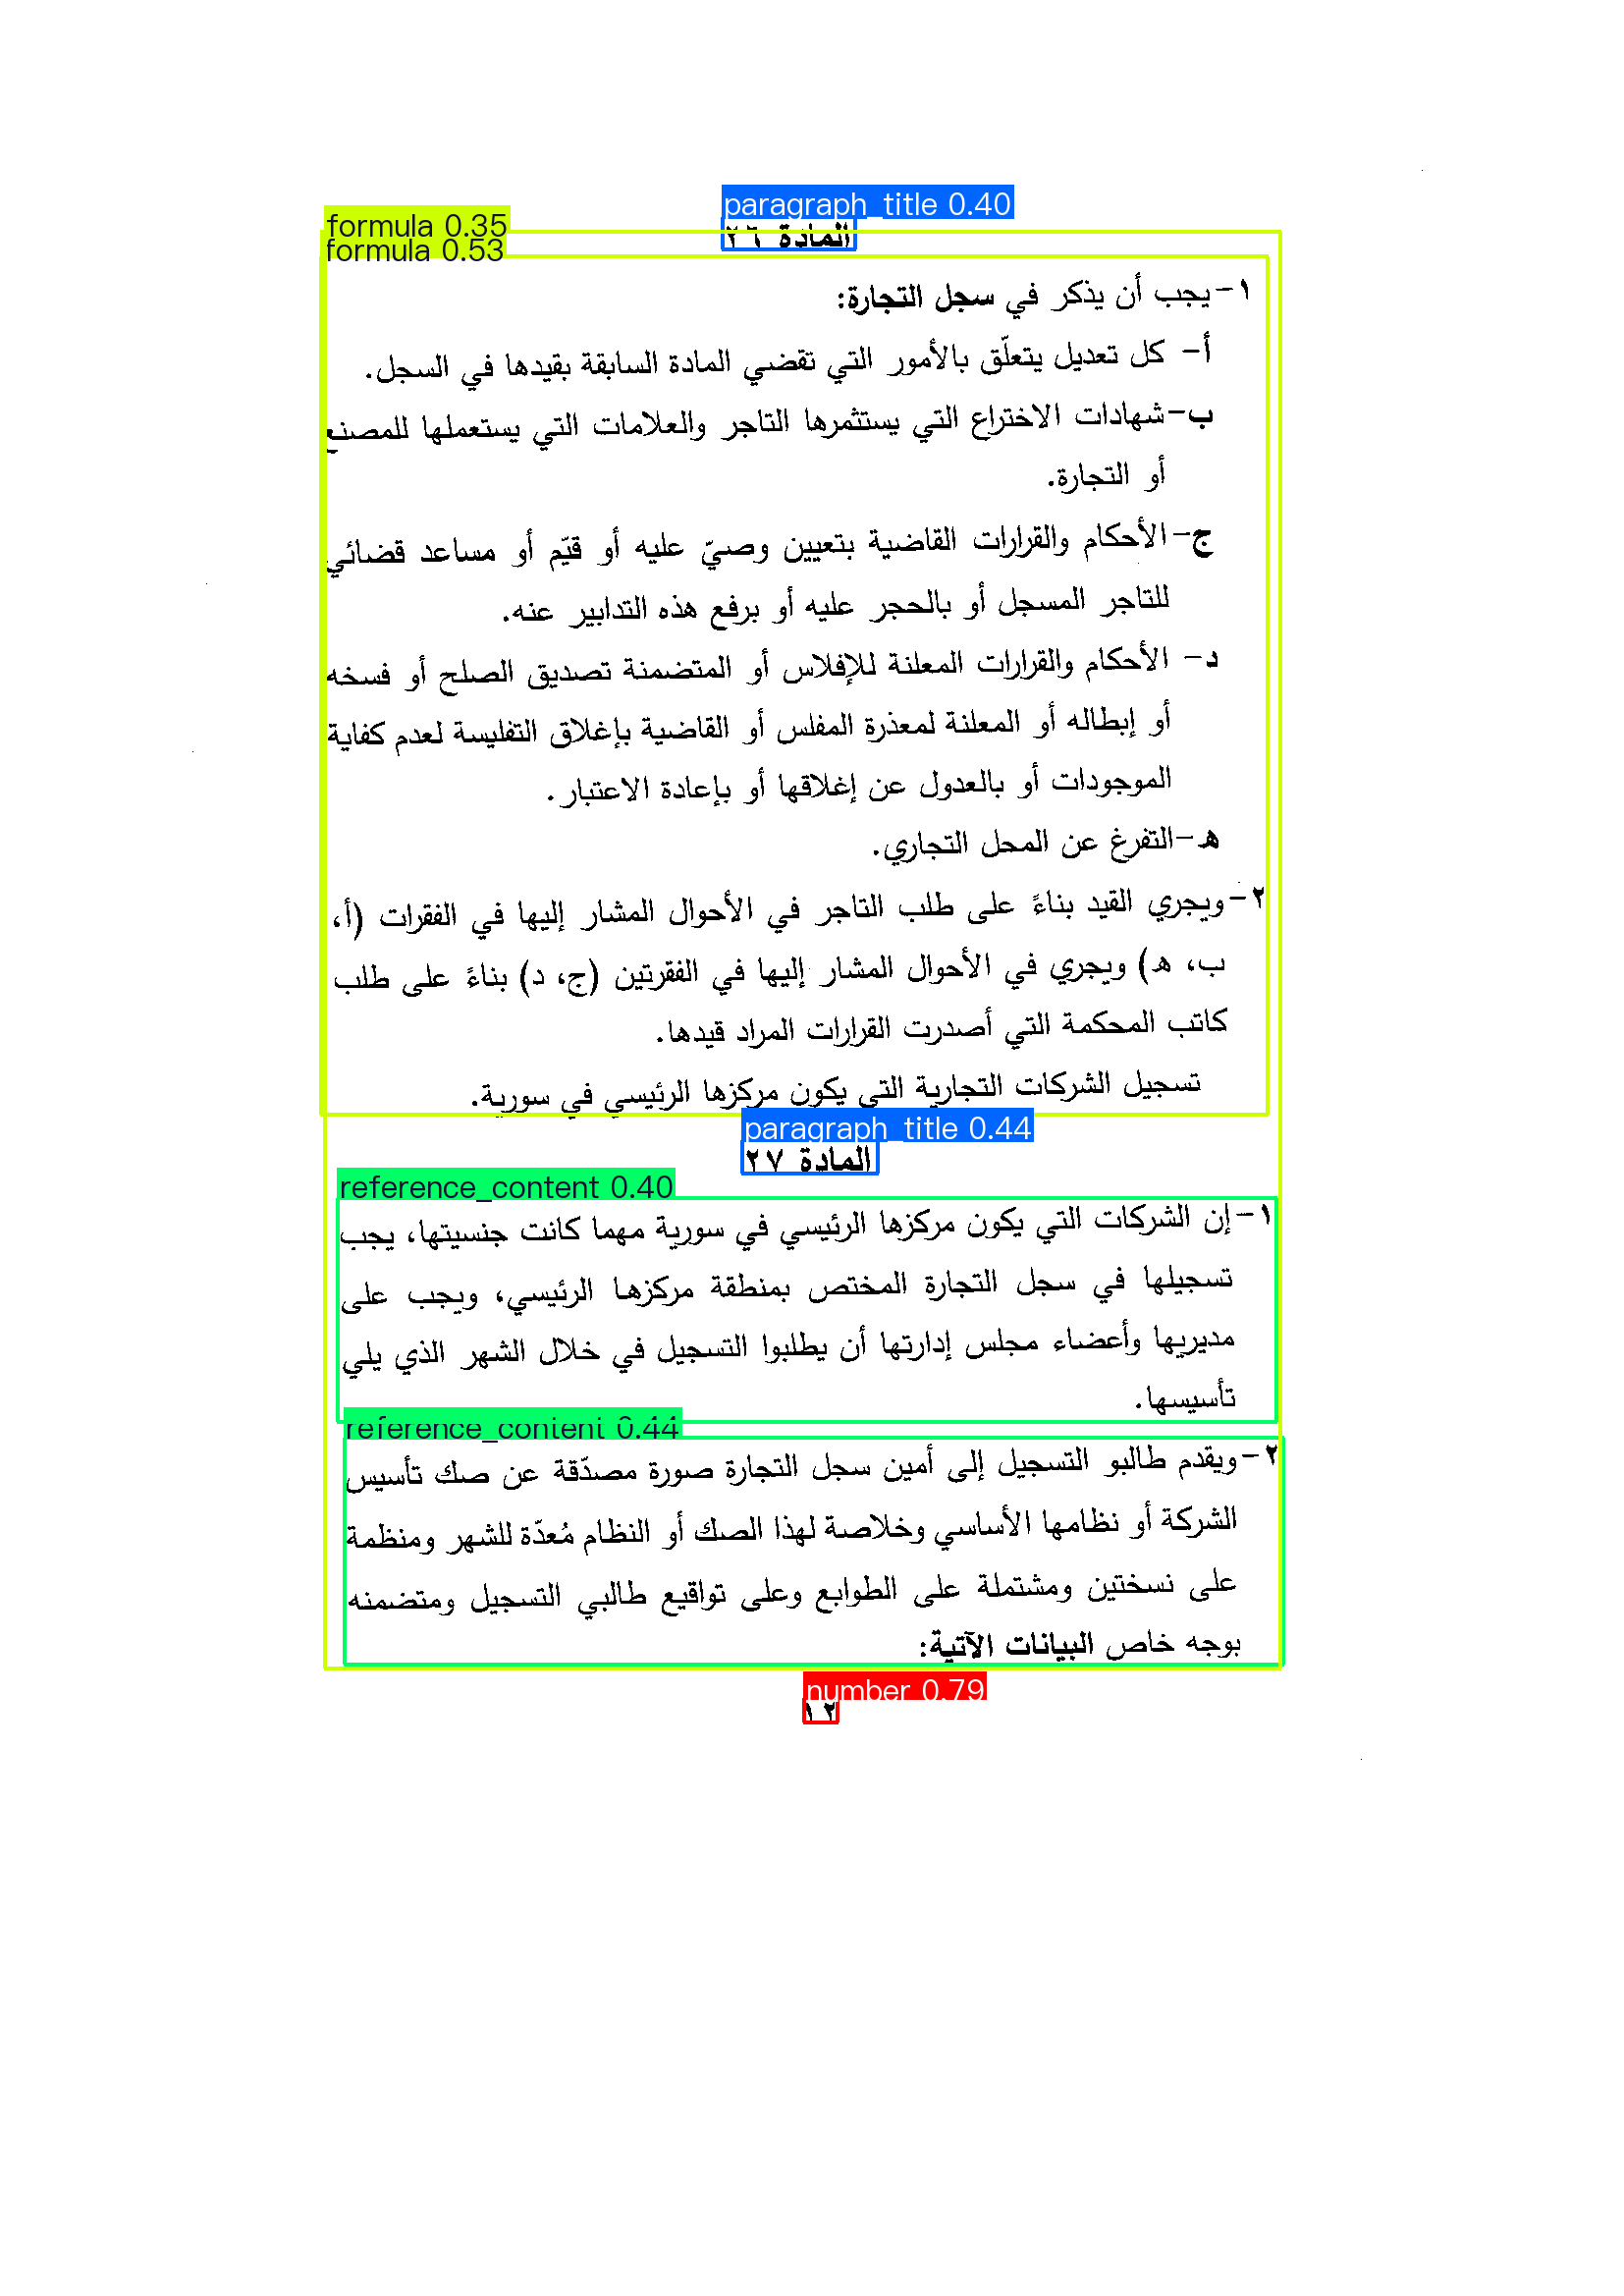

page_0013


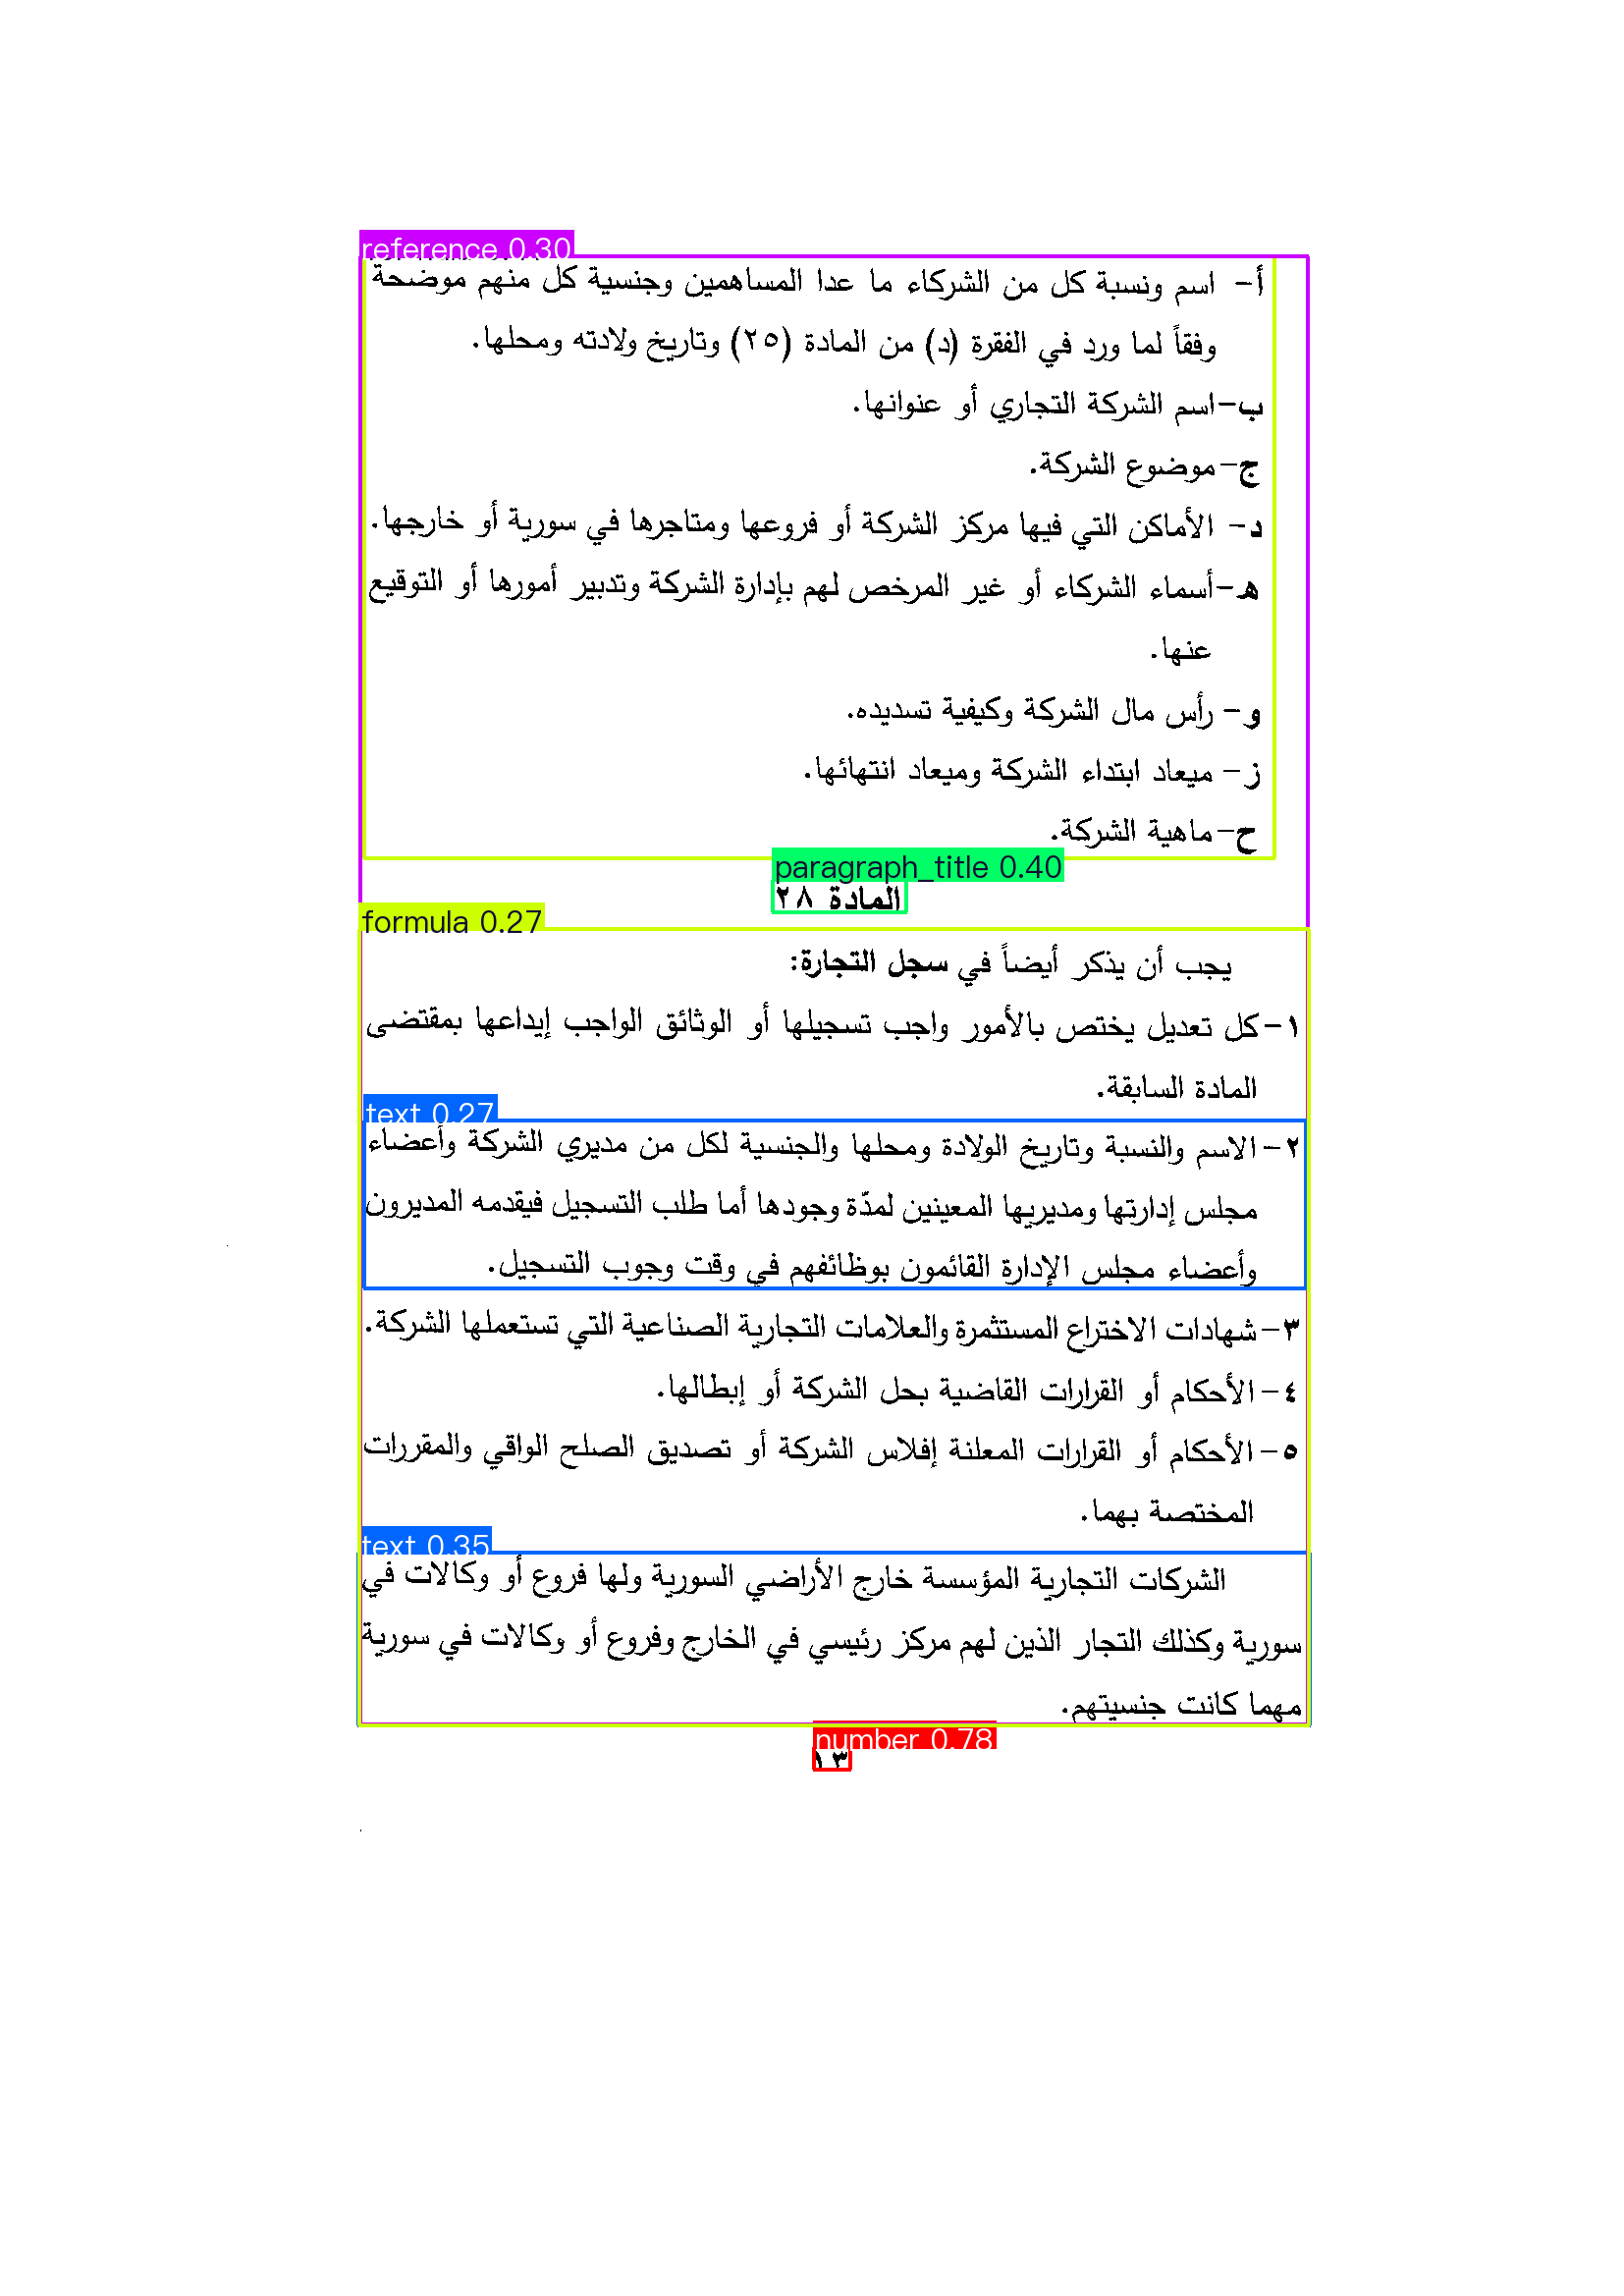

page_0014


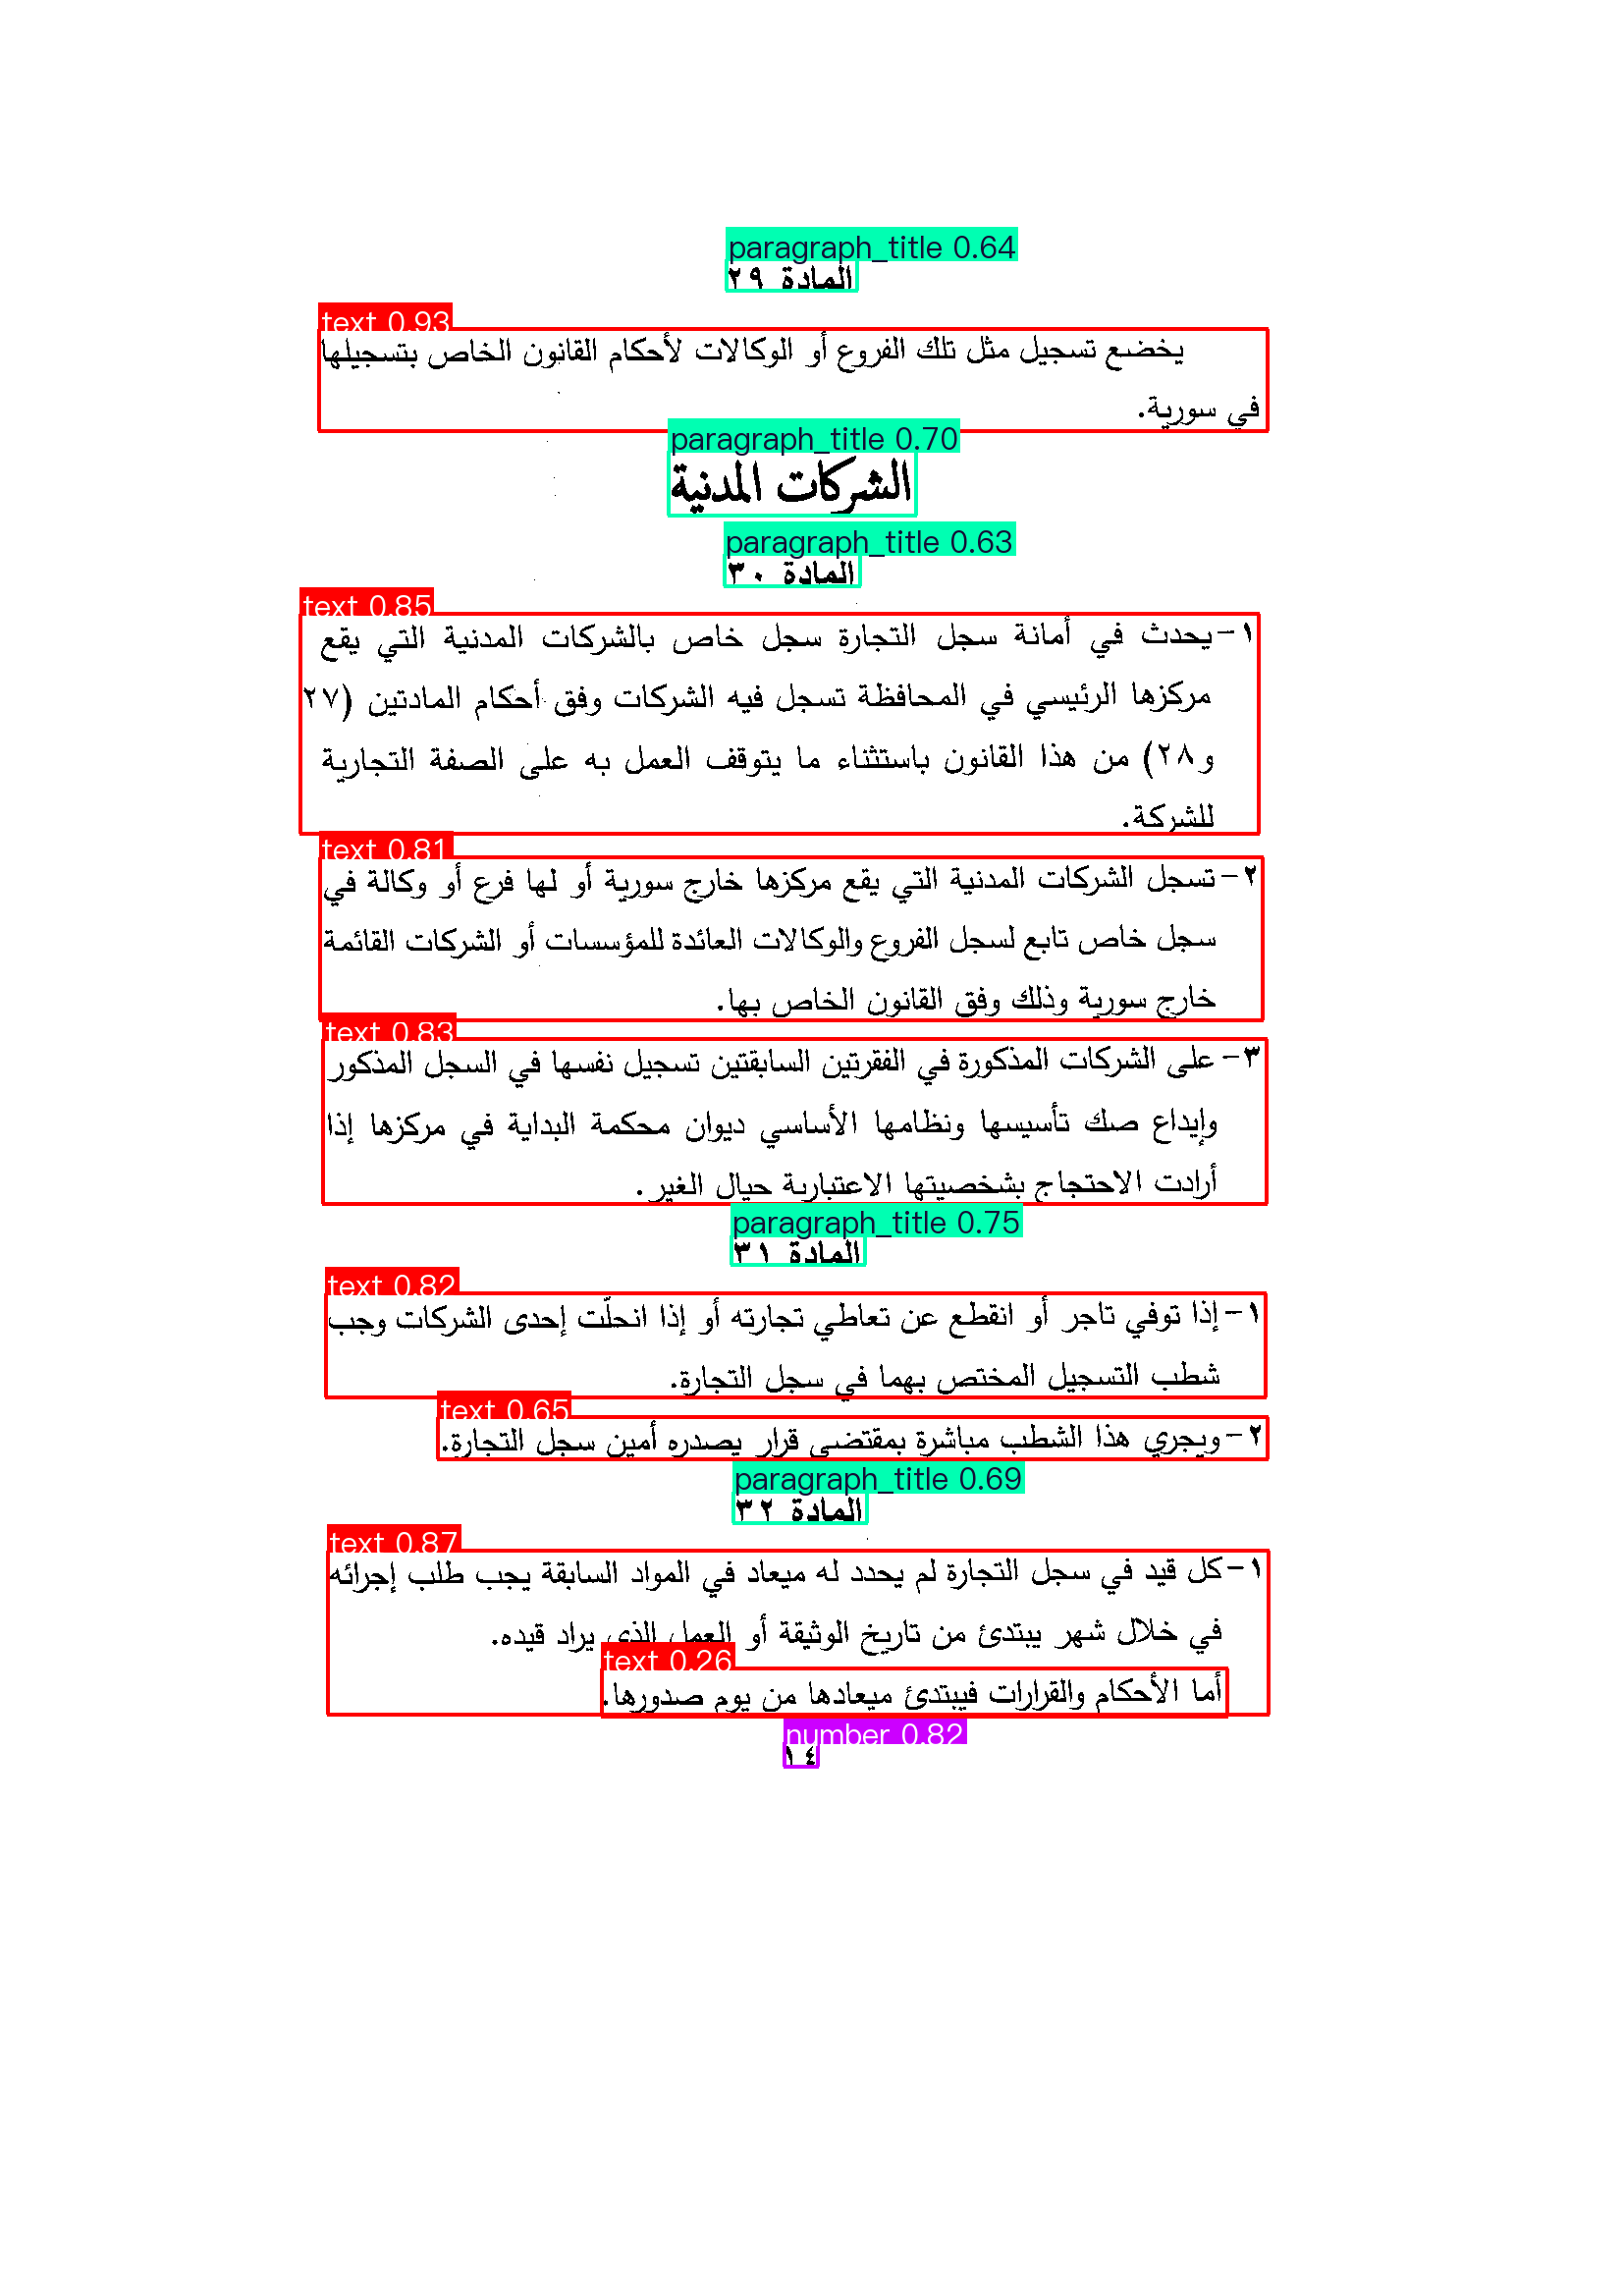

page_0015


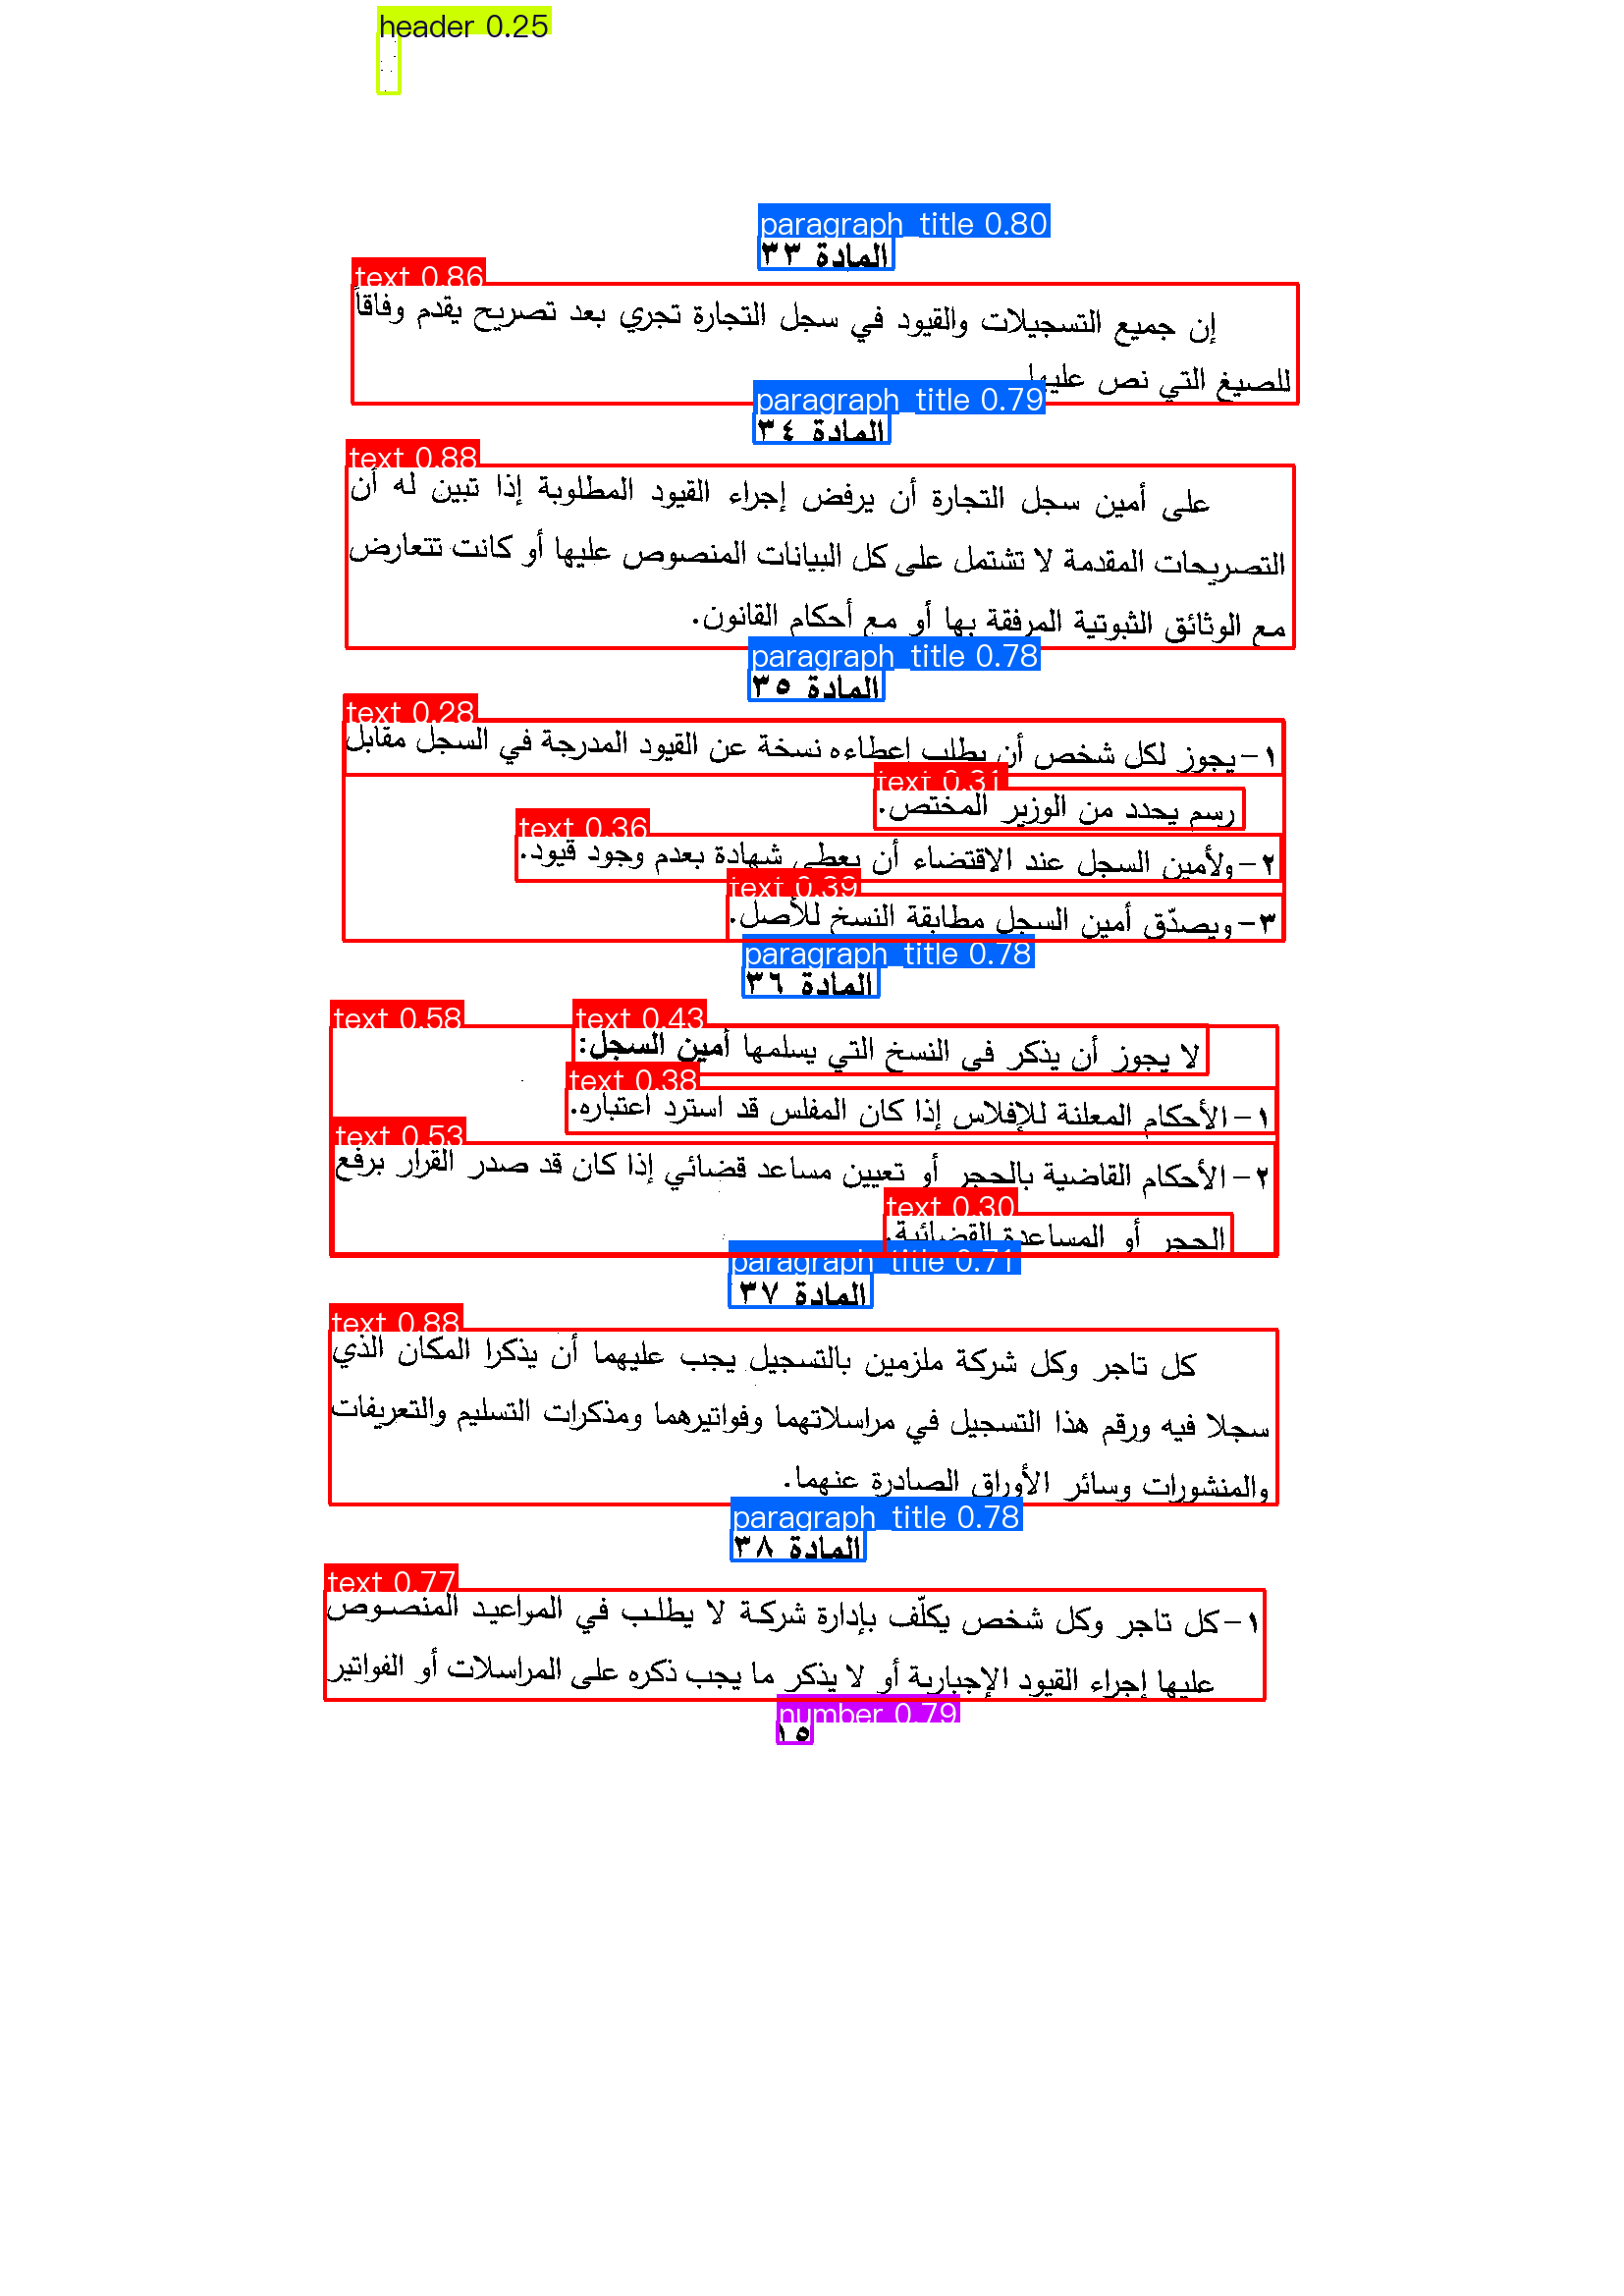

page_0016


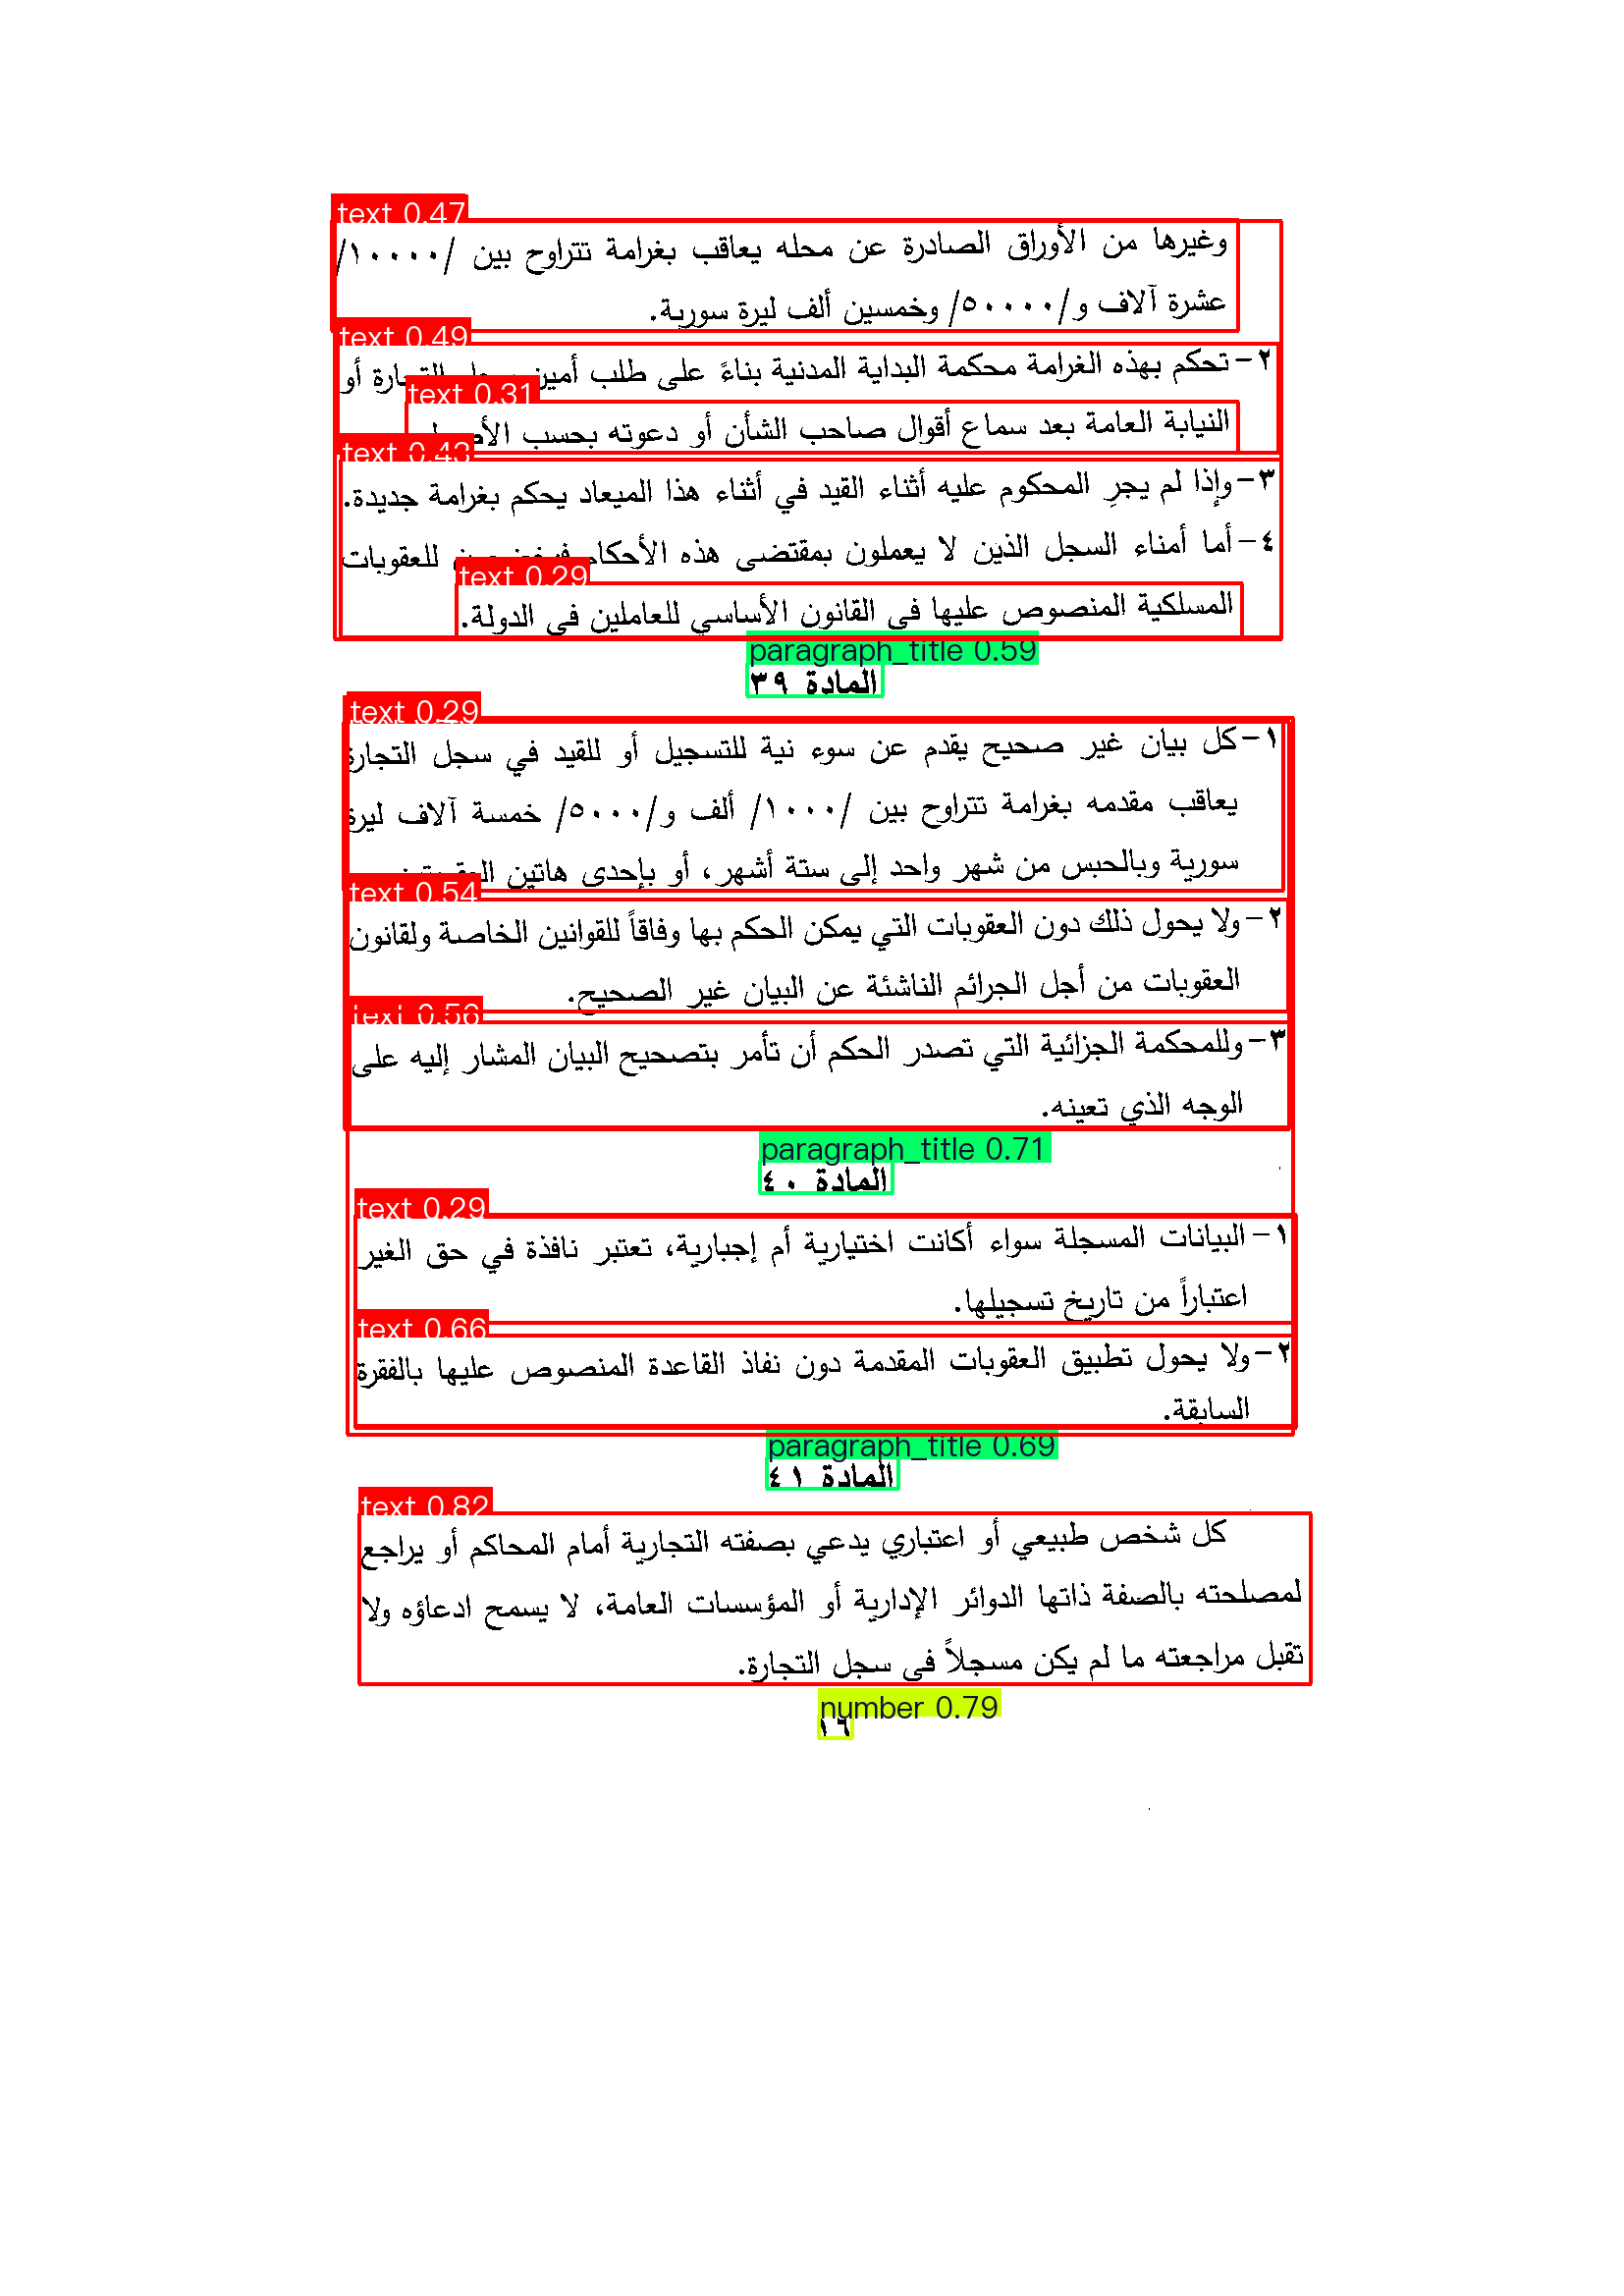

page_0017


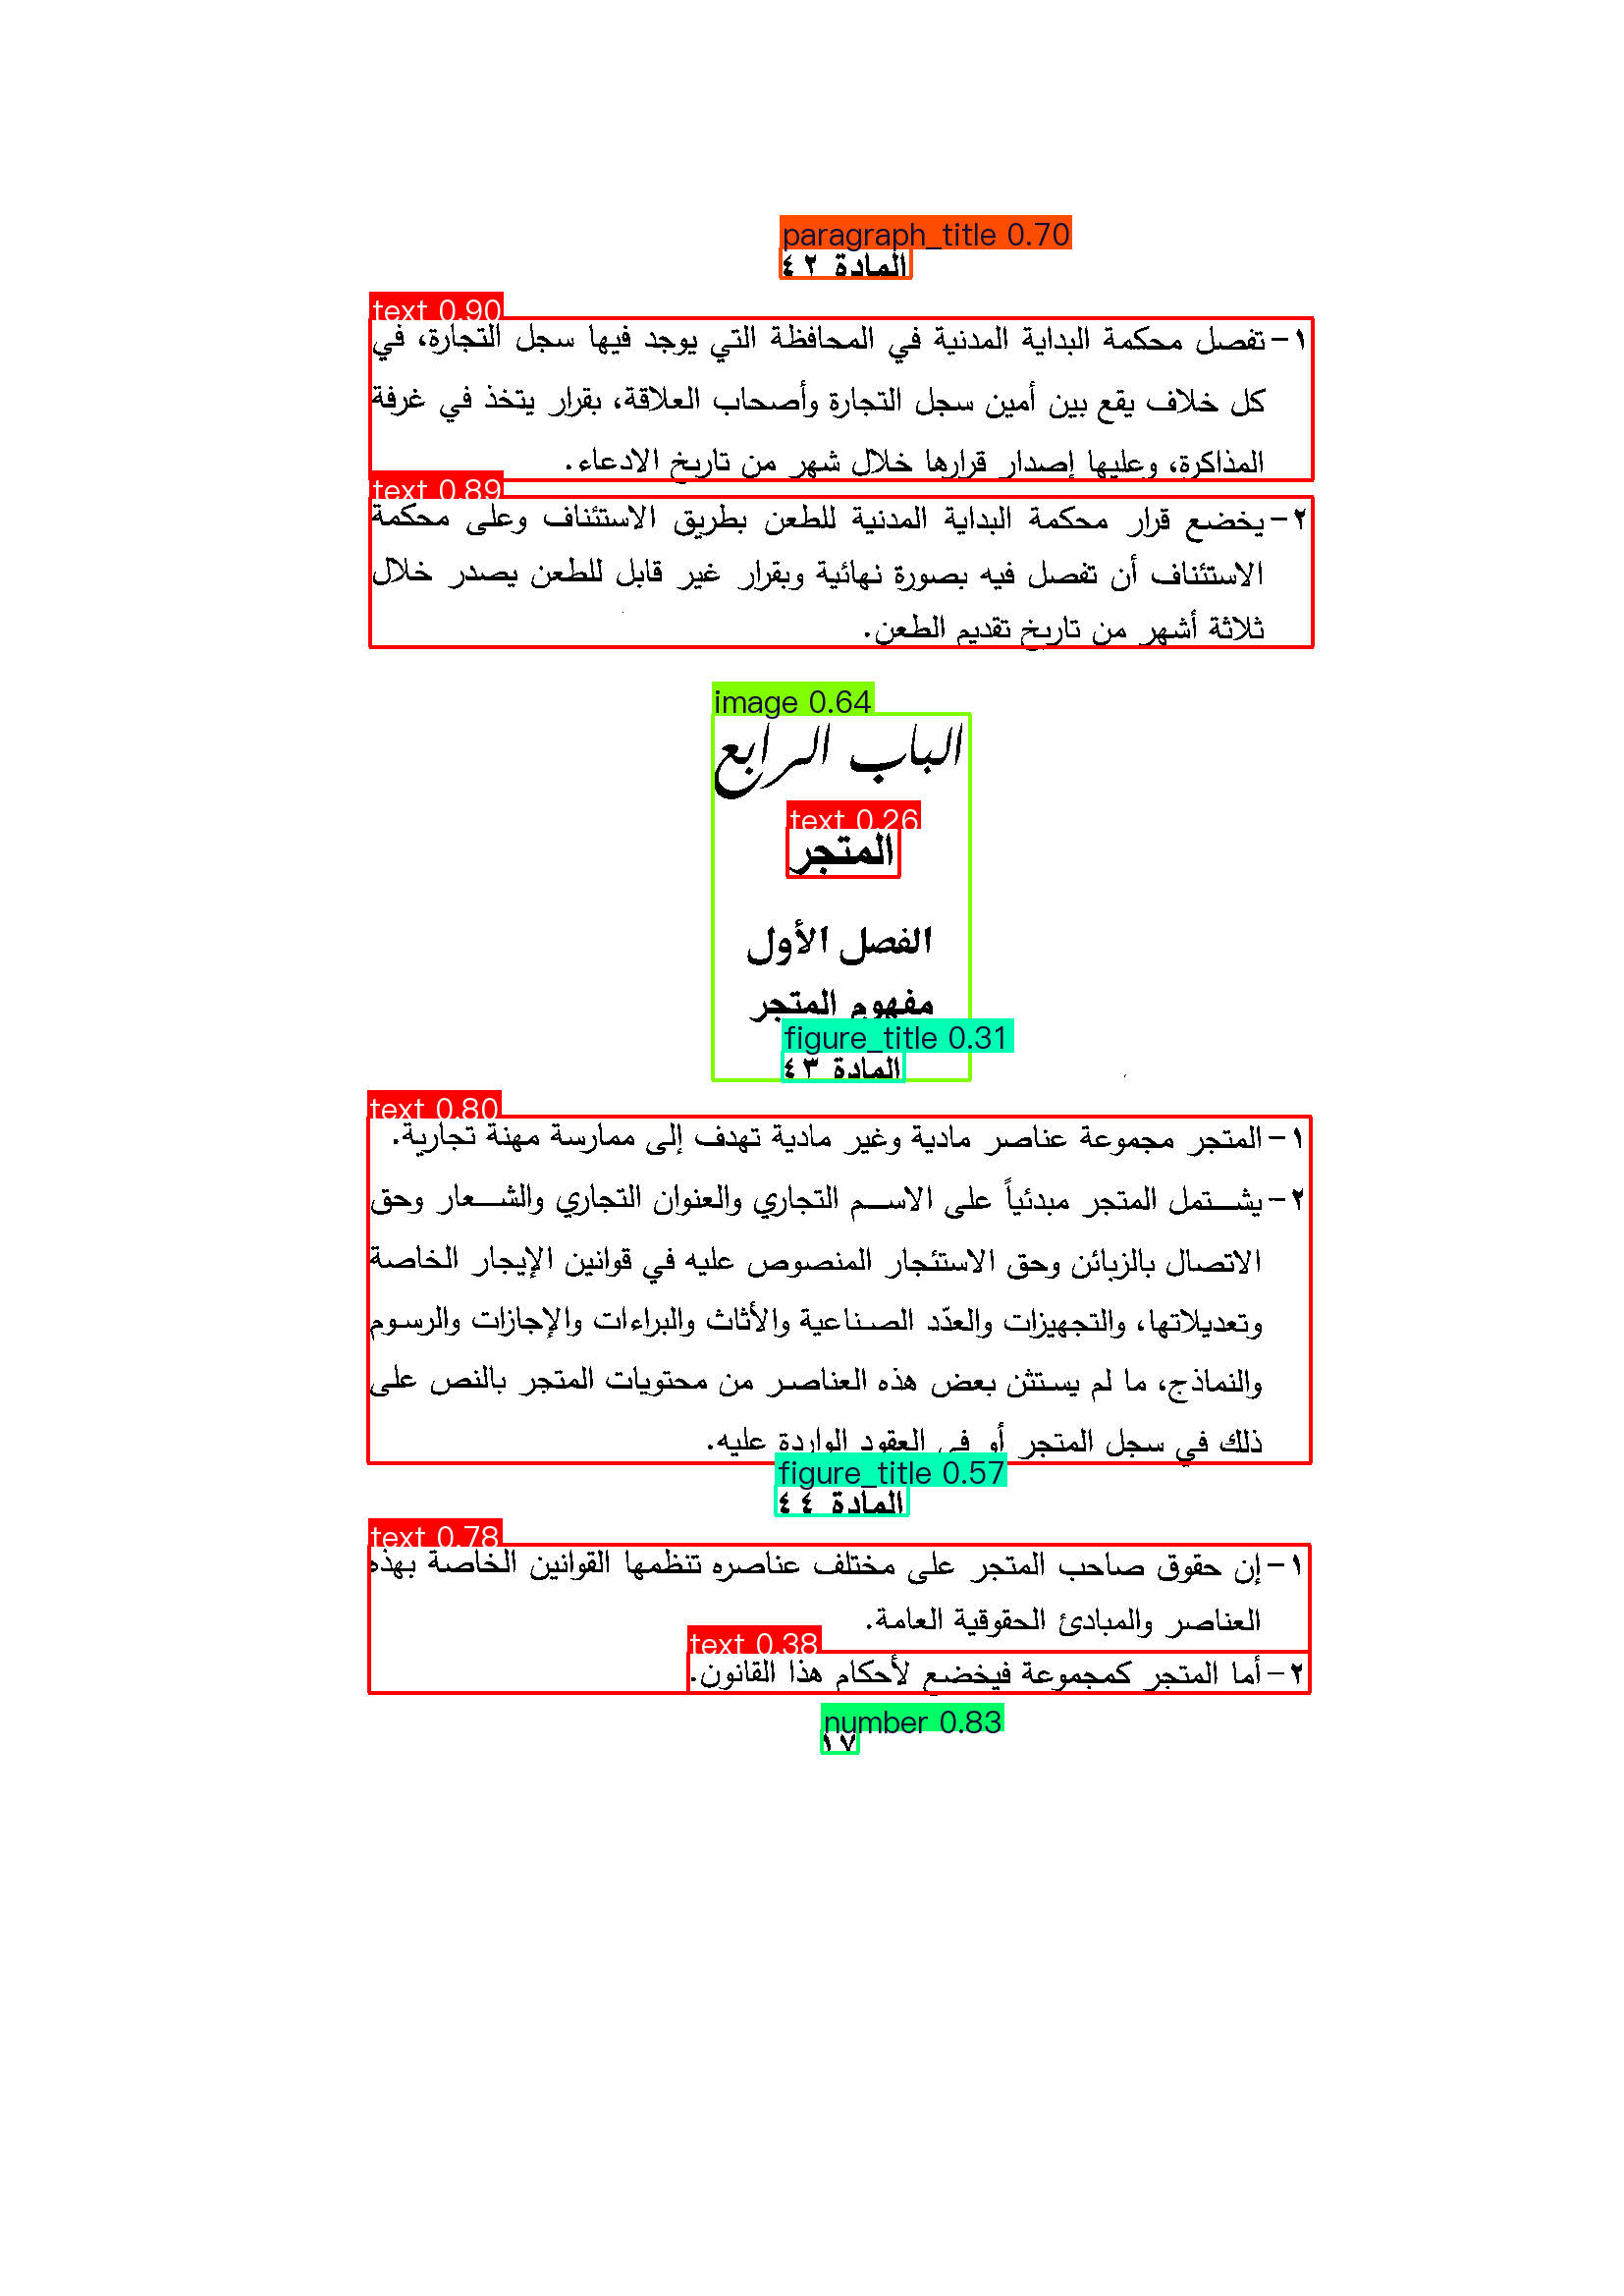

In [19]:
# ============================================================
# 10. Preview the annotated pages
# ============================================================
import glob
import os

from IPython.display import Image, display

for path in selected:
    page_name = os.path.splitext(os.path.basename(path))[0]
    imgs = [p for p in glob.glob(os.path.join(OUTPUT_DIR, page_name, "*"))
            if p.lower().endswith((".png", ".jpg", ".jpeg"))]
    if not imgs:
        print(f"{page_name}: no visualization found")
        continue
    print(page_name)
    display(Image(filename=imgs[0], width=700))

In [20]:
# ============================================================
# 11. Crop every detected box
# ============================================================
import os

import cv2
import fitz
import numpy as np

if not records:
    raise ValueError("No boxes to crop -- run cell 8 first.")

os.makedirs(CROPS_DIR, exist_ok=True)

_doc = fitz.open(pdf_path) if CROP_FROM_ORIGINAL else None
_matrix = fitz.Matrix(PDF_DPI / 72, PDF_DPI / 72)
_page_cache = {}


def page_image(page_name):
    """Full-page image the crops are cut from, cached per page."""
    if page_name in _page_cache:
        return _page_cache[page_name]

    if CROP_FROM_ORIGINAL:
        # Re-render without binarization. Same matrix -> same pixel dimensions,
        # so the layout coordinates still line up exactly.
        idx = int(page_name.split("_")[1]) - 1
        pix = _doc[idx].get_pixmap(matrix=_matrix)
        arr = np.frombuffer(pix.samples, dtype=np.uint8).reshape(
            pix.height, pix.width, pix.n
        )
        img = cv2.cvtColor(arr[:, :, :3], cv2.COLOR_RGB2BGR)
    else:
        path = os.path.join(PAGES_DIR, page_name + ".png")
        img = cv2.imread(path)
        if img is None:
            raise FileNotFoundError(path)

    _page_cache[page_name] = img
    return img


def box_area(r):
    return max(r["x2"] - r["x1"], 0) * max(r["y2"] - r["y1"], 0)


def contained_fraction(inner, outer):
    """How much of `inner` lies inside `outer`, as a fraction of inner's area."""
    overlap_w = min(inner["x2"], outer["x2"]) - max(inner["x1"], outer["x1"])
    overlap_h = min(inner["y2"], outer["y2"]) - max(inner["y1"], outer["y1"])
    if overlap_w <= 0 or overlap_h <= 0:
        return 0.0
    area = box_area(inner)
    return (overlap_w * overlap_h) / area if area else 0.0


def drop_oversized(page_records, page_area):
    """Remove boxes that cover most of the page -- reliably false positives.

    Must run BEFORE drop_nested: such a box is the biggest on its page, so the
    nested pass would keep it and discard every genuine block inside it.
    """
    if MAX_BOX_AREA_FRAC is None or not page_area:
        return page_records, []

    kept, removed = [], []
    for record in page_records:
        if box_area(record) / page_area > MAX_BOX_AREA_FRAC:
            removed.append(record)
        else:
            kept.append(record)
    return kept, removed


def drop_nested(page_records):
    """Remove boxes that sit almost entirely inside a bigger box."""
    if DROP_NESTED_ABOVE is None:
        return page_records, []

    # Biggest first, so a box is only ever tested against larger survivors.
    ordered = sorted(page_records, key=box_area, reverse=True)
    kept, removed = [], []

    for record in ordered:
        parent = next(
            (k for k in kept
             if contained_fraction(record, k) >= DROP_NESTED_ABOVE),
            None,
        )
        if parent is None:
            kept.append(record)
        else:
            removed.append((record, parent))

    return kept, removed


def reading_key(record):
    """Arabic reading order: top-to-bottom, then right-to-left.

    y1 is bucketed to 10 px so boxes sitting on the same line are grouped
    before the right-to-left tie-break applies.
    """
    return (round(record["y1"] / 10), -record["x2"])


crops = []
skipped = []
oversized_removed = []
nested_removed = []

for page_name in sorted({r["page"] for r in records}):
    page_records = [r for r in records if r["page"] == page_name]
    if OCR_LABELS is not None:
        page_records = [r for r in page_records if r["label"] in OCR_LABELS]
    if not page_records:
        continue

    img = page_image(page_name)
    height, width = img.shape[:2]

    page_records, too_big = drop_oversized(page_records, height * width)
    oversized_removed.extend((page_name, r) for r in too_big)

    page_records, nested = drop_nested(page_records)
    nested_removed.extend((page_name, i, o) for i, o in nested)

    page_records.sort(key=reading_key)

    page_crop_dir = os.path.join(CROPS_DIR, page_name)
    os.makedirs(page_crop_dir, exist_ok=True)

    for order, record in enumerate(page_records, start=1):
        x1 = max(int(record["x1"]) - CROP_PADDING, 0)
        y1 = max(int(record["y1"]) - CROP_PADDING, 0)
        x2 = min(int(round(record["x2"])) + CROP_PADDING, width)
        y2 = min(int(round(record["y2"])) + CROP_PADDING, height)

        if x2 - x1 < MIN_CROP_SIDE or y2 - y1 < MIN_CROP_SIDE:
            skipped.append(f"{page_name} #{order} {record['label']} "
                           f"({x2 - x1}x{y2 - y1}px)")
            continue

        crop_id = f"{page_name}_{order:03d}_{record['label']}"
        out_path = os.path.join(page_crop_dir, crop_id + ".png")
        cv2.imwrite(out_path, img[y1:y2, x1:x2])

        crops.append({
            "crop_id": crop_id,
            "page": page_name,
            "page_number": int(page_name.split("_")[1]),
            "order": order,
            "label": record["label"],
            "score": record["score"],
            "x1": x1, "y1": y1, "x2": x2, "y2": y2,
            "width": x2 - x1,
            "height": y2 - y1,
            "path": out_path,
        })

if _doc is not None:
    _doc.close()
_page_cache.clear()

print(f"Cropped {len(crops)} box(es) from "
      f"{len({c['page'] for c in crops})} page(s)")
print(f"Source: {'original grey render' if CROP_FROM_ORIGINAL else 'binarized pages'}")
print(f"Saved -> {os.path.abspath(CROPS_DIR)}\n")

excluded = (sum(1 for r in records if r["label"] not in OCR_LABELS)
            if OCR_LABELS is not None else 0)
print(f"From {len(records)} detected box(es):")
print(f"  {excluded:>4} excluded by OCR_LABELS")
print(f"  {len(oversized_removed):>4} dropped as oversized "
      f"(> {MAX_BOX_AREA_FRAC} of the page)")
print(f"  {len(nested_removed):>4} dropped as nested "
      f"(>= {DROP_NESTED_ABOVE} inside a bigger box)")
print(f"  {len(skipped):>4} skipped under MIN_CROP_SIDE={MIN_CROP_SIDE}px")
print(f"  {len(crops):>4} cropped")

print("\nCrops per page:")
for page_name in sorted({c["page"] for c in crops}):
    print(f"  {page_name}: {sum(1 for c in crops if c['page'] == page_name)}")

if oversized_removed:
    print("\nOversized boxes dropped (page-spanning false positives):")
    for page_name, r in oversized_removed:
        print(f"  {page_name}: {r['label']} score={r['score']:.2f} "
              f"{int(r['x2'] - r['x1'])}x{int(r['y2'] - r['y1'])}")
if skipped:
    print()
    for s in skipped[:5]:
        print("  skipped:", s)

Cropped 134 box(es) from 15 page(s)
Source: original grey render
Saved -> C:\Users\ASUS\Desktop\ocr-layout\crops

From 215 detected box(es):
    10 excluded by OCR_LABELS
     2 dropped as oversized (> 0.35 of the page)
    69 dropped as nested (>= 0.9 inside a bigger box)
     0 skipped under MIN_CROP_SIDE=12px
   134 cropped

Crops per page:
  page_0003: 12
  page_0004: 10
  page_0005: 6
  page_0006: 7
  page_0007: 8
  page_0008: 13
  page_0009: 10
  page_0010: 14
  page_0011: 3
  page_0012: 5
  page_0013: 4
  page_0014: 13
  page_0015: 14
  page_0016: 6
  page_0017: 9

Oversized boxes dropped (page-spanning false positives):
  page_0009: text score=0.30 972x1535
  page_0013: reference score=0.30 966x1494


In [21]:
# ============================================================
# 12. Connect to the remote OCR server
# ============================================================
import requests

if not OCR_BASE_URL or not OCR_TOKEN:
    raise ValueError(
        "OCR_BASE_URL and OCR_TOKEN are empty.\n"
        "Run the Colab server notebook, then paste the trycloudflare URL and "
        "the token it prints into the settings cell."
    )

OCR_BASE_URL = OCR_BASE_URL.rstrip("/")
HEADERS = {"Authorization": f"Bearer {OCR_TOKEN}"}

response = requests.get(f"{OCR_BASE_URL}/health", headers=HEADERS, timeout=60)
response.raise_for_status()
health = response.json()

print("Server reachable:", OCR_BASE_URL)
for key in ("status", "paddle_version", "paddleocr_version", "device"):
    print(f"  {key:<18}: {health.get(key)}")
print("  config            :", health.get("config"))
print("  models            :", health.get("expected_models"))

Server reachable: https://labs-proudly-supreme-summer.trycloudflare.com
  status            : ok
  paddle_version    : 3.2.0
  paddleocr_version : 3.7.0
  device            : cpu
  config            : {'language': 'ar', 'ocr_version': 'PP-OCRv5', 'use_doc_orientation_classify': False, 'use_doc_unwarping': False, 'use_textline_orientation': True}
  models            : {'textline_orientation': 'PP-LCNet_x1_0_textline_ori', 'detector': 'PP-OCRv5_server_det', 'recognizer': 'arabic_PP-OCRv5_mobile_rec'}


In [22]:
# ============================================================
# 13. Send every crop to the remote OCR server
# ============================================================
import json
import os
import time

import requests

RAW_DIR = os.path.join(OUTPUT_DIR, "ocr_raw")
os.makedirs(RAW_DIR, exist_ok=True)


def ocr_one(crop):
    """POST one crop to /infer. Returns (payload, error_string)."""
    last_error = None

    for attempt in range(1, OCR_RETRIES + 1):
        try:
            with open(crop["path"], "rb") as fh:
                response = requests.post(
                    f"{OCR_BASE_URL}/infer",
                    headers=HEADERS,
                    data={"page": crop["page_number"]},
                    files={"file": (os.path.basename(crop["path"]), fh,
                                    "image/png")},
                    timeout=OCR_TIMEOUT,
                )
            if response.status_code == 200:
                return response.json(), None
            last_error = f"HTTP {response.status_code}: {response.text[:300]}"
        except Exception as exc:
            last_error = repr(exc)

        if attempt < OCR_RETRIES:
            time.sleep(2 * attempt)  # linear backoff

    return None, last_error


ocr_raw = {}    # crop_id -> server payload
failures = []

# The server holds a lock around predict(), so requests are serialized on its
# side anyway -- sending them one at a time buys nothing to parallelize.
print(f"Sending {len(crops)} crop(s) to {OCR_BASE_URL} ...\n")
started = time.perf_counter()

for i, crop in enumerate(crops, start=1):
    raw_path = os.path.join(RAW_DIR, crop["crop_id"] + ".json")

    if OCR_RESUME and os.path.exists(raw_path):
        with open(raw_path, encoding="utf-8") as fh:
            ocr_raw[crop["crop_id"]] = json.load(fh)
        print(f"[{i}/{len(crops)}] {crop['crop_id']}  (cached)")
        continue

    payload, error = ocr_one(crop)

    if payload is None:
        failures.append({"crop_id": crop["crop_id"], "error": error})
        print(f"[{i}/{len(crops)}] {crop['crop_id']}  FAILED: {error}")
        continue

    with open(raw_path, "w", encoding="utf-8") as fh:
        json.dump(payload, fh, ensure_ascii=False)
    ocr_raw[crop["crop_id"]] = payload

    elapsed = time.perf_counter() - started
    rate = elapsed / i
    eta = rate * (len(crops) - i)
    print(f"[{i}/{len(crops)}] {crop['crop_id']}  "
          f"({rate:.1f}s/crop, eta {eta / 60:.1f} min)")

print(f"\nDone in {(time.perf_counter() - started) / 60:.1f} min")
print(f"  succeeded : {len(ocr_raw)}")
print(f"  failed    : {len(failures)}")
print(f"  raw JSON  : {os.path.abspath(RAW_DIR)}")

if failures:
    print("\nFailures (re-run this cell to retry them -- successes are cached):")
    for f in failures[:10]:
        print(f"  {f['crop_id']}: {f['error']}")

Sending 134 crop(s) to https://labs-proudly-supreme-summer.trycloudflare.com ...

[1/134] page_0003_001_doc_title  (2.6s/crop, eta 5.9 min)
[2/134] page_0003_002_text  (2.9s/crop, eta 6.4 min)
[3/134] page_0003_003_text  (2.5s/crop, eta 5.5 min)
[4/134] page_0003_004_text  (2.3s/crop, eta 5.0 min)
[5/134] page_0003_005_text  (2.2s/crop, eta 4.8 min)
[6/134] page_0003_006_text  (2.1s/crop, eta 4.4 min)
[7/134] page_0003_007_text  (2.1s/crop, eta 4.5 min)
[8/134] page_0003_008_paragraph_title  (2.0s/crop, eta 4.2 min)
[9/134] page_0003_009_text  (2.0s/crop, eta 4.3 min)
[10/134] page_0003_010_text  (2.0s/crop, eta 4.1 min)
[11/134] page_0003_011_text  (2.0s/crop, eta 4.1 min)
[12/134] page_0003_012_number  (1.9s/crop, eta 4.0 min)
[13/134] page_0004_001_text  (1.9s/crop, eta 3.8 min)
[14/134] page_0004_002_figure_title  (1.9s/crop, eta 3.7 min)
[15/134] page_0004_003_text  (1.9s/crop, eta 3.8 min)
[16/134] page_0004_004_paragraph_title  (1.9s/crop, eta 3.7 min)
[17/134] page_0004_005_tex

In [23]:
# ============================================================
# 14. Extract the text and save everything
# ============================================================
import json
import os

import pandas as pd


def iter_rec_blocks(obj):
    """Yield (texts, scores) for every rec_texts found anywhere in a response.

    PaddleOCR 3.x wraps its result as {"res": {"rec_texts": [...], ...}}, but
    walking the whole tree keeps this working if the shape ever changes.
    """
    if isinstance(obj, dict):
        if "rec_texts" in obj:
            yield obj.get("rec_texts") or [], obj.get("rec_scores") or []
        for value in obj.values():
            yield from iter_rec_blocks(value)
    elif isinstance(obj, list):
        for value in obj:
            yield from iter_rec_blocks(value)


ocr_rows = []

for crop in crops:
    payload = ocr_raw.get(crop["crop_id"])

    texts, scores = [], []
    if payload is not None:
        for block_texts, block_scores in iter_rec_blocks(payload.get("raw")):
            texts.extend(block_texts)
            scores.extend(block_scores)

    ocr_rows.append({
        "crop_id": crop["crop_id"],
        "page": crop["page"],
        "page_number": crop["page_number"],
        "order": crop["order"],
        "label": crop["label"],
        "layout_score": crop["score"],
        "x1": crop["x1"], "y1": crop["y1"], "x2": crop["x2"], "y2": crop["y2"],
        "width": crop["width"], "height": crop["height"],
        "n_lines": len(texts),
        "mean_rec_score": round(sum(scores) / len(scores), 4) if scores else None,
        "text": "\n".join(texts),
        "crop_path": crop["path"],
        "ocr_ok": payload is not None,
    })

ocr_df = pd.DataFrame(ocr_rows)

# --- per-page plain text, in reading order -------------------------------
TEXT_DIR = os.path.join(OUTPUT_DIR, "text")
os.makedirs(TEXT_DIR, exist_ok=True)

combined = []
for page_name in sorted({r["page"] for r in ocr_rows}):
    page_rows = sorted((r for r in ocr_rows if r["page"] == page_name),
                       key=lambda r: r["order"])
    body = "\n\n".join(f"[{r['label']}]\n{r['text']}"
                       for r in page_rows if r["text"])
    with open(os.path.join(TEXT_DIR, f"{page_name}.txt"), "w",
              encoding="utf-8") as fh:
        fh.write(body)
    combined.append(f"===== {page_name} =====\n{body}")

with open(os.path.join(OUTPUT_DIR, "all_text.txt"), "w",
          encoding="utf-8") as fh:
    fh.write("\n\n".join(combined))

# --- structured output ---------------------------------------------------
# utf-8-sig so Excel opens the Arabic correctly.
ocr_df.to_csv(os.path.join(OUTPUT_DIR, "ocr_boxes.csv"), index=False,
              encoding="utf-8-sig")

with open(os.path.join(OUTPUT_DIR, "ocr_results.json"), "w",
          encoding="utf-8") as fh:
    json.dump(ocr_rows, fh, ensure_ascii=False, indent=1)

# --- summary -------------------------------------------------------------
with_text = int((ocr_df["n_lines"] > 0).sum())
print(f"crops           : {len(ocr_df)}")
print(f"answered by OCR : {int(ocr_df['ocr_ok'].sum())}")
print(f"produced text   : {with_text}")
print(f"empty result    : {len(ocr_df) - with_text}")
print(f"total lines     : {int(ocr_df['n_lines'].sum())}")

if with_text:
    print("\n=== lines and mean recognition score per label ===")
    display(
        ocr_df[ocr_df["n_lines"] > 0]
        .groupby("label")
        .agg(crops=("crop_id", "count"),
             lines=("n_lines", "sum"),
             mean_rec_score=("mean_rec_score", "mean"))
        .round(3)
        .sort_values("lines", ascending=False)
    )

print(f"\nSaved -> {os.path.abspath(OUTPUT_DIR)}")
print("  ocr_boxes.csv      one row per crop, with its text")
print("  ocr_results.json   same data as JSON")
print("  all_text.txt       every page concatenated")
print("  text/page_XXXX.txt one file per page, reading order")

crops           : 134
answered by OCR : 134
produced text   : 127
empty result    : 7
total lines     : 321

=== lines and mean recognition score per label ===


,crops,lines,mean_rec_score
label,,,
text,68,246,0.923
paragraph_title,40,45,0.920
number,11,11,0.690
reference_content,2,8,0.951
doc_title,1,5,0.336
figure_title,4,4,0.706
header,1,2,0.473



Saved -> C:\Users\ASUS\Desktop\ocr-layout\layout_output
  ocr_boxes.csv      one row per crop, with its text
  ocr_results.json   same data as JSON
  all_text.txt       every page concatenated
  text/page_XXXX.txt one file per page, reading order


page_0003_001_doc_title  |  layout=doc_title 0.37  |  lines=5  rec_score=0.3365


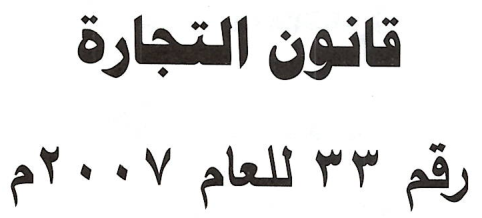

اهارة
ي

لا
ي

page_0003_002_text  |  layout=text 0.27  |  lines=4  rec_score=0.8864


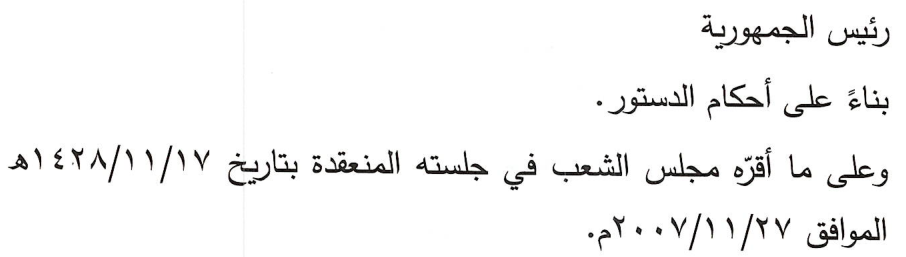

رئيس الجمهورية
بناءَ على أحكام الدستور
وعلى ما أقرّه مجلس الشعب في جلسته المنعقدة بتاريخ ٤١
الموافق٢١

page_0003_003_text  |  layout=text 0.29  |  lines=2  rec_score=0.8812


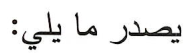

يلى
يصدر

page_0003_004_text  |  layout=text 0.35  |  lines=1  rec_score=0.8894


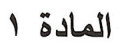

المادة

page_0003_005_text  |  layout=text 0.39  |  lines=1  rec_score=0.9601


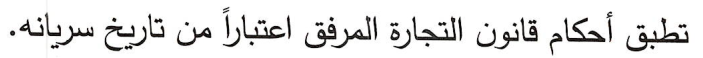

تطبق أحكام قانون التجارة المرفق اعتباراً من تاريخ سريانه

page_0003_006_text  |  layout=text 0.34  |  lines=1  rec_score=0.8931


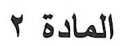

المادة٢

page_0003_007_text  |  layout=text 0.39  |  lines=2  rec_score=0.9329


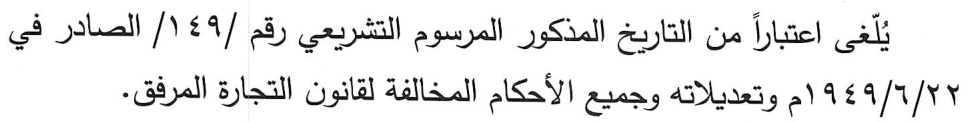

يلغى اعتباراً من التاريخ المذكور المرسوم التشريعي رقم١٤٩ الصادر في
١٩٤٩٦م وتعديلاته وجميع الأحكام المخالفة لقانون التجارة المرفق

page_0003_008_paragraph_title  |  layout=paragraph_title 0.39  |  lines=1  rec_score=0.8474


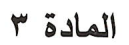

المادة ٣

page_0003_009_text  |  layout=text 0.46  |  lines=2  rec_score=0.8938


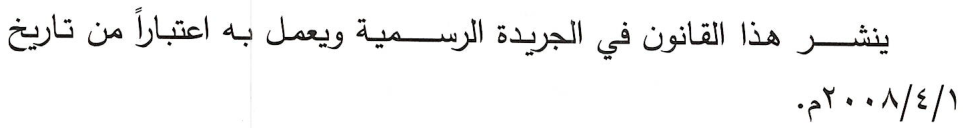

ينشر هذا القانون في الجريدة الرسمية ويعمل به اعتباراً من تاريخ
٢٠٨٤١

page_0003_010_text  |  layout=text 0.44  |  lines=1  rec_score=0.6486


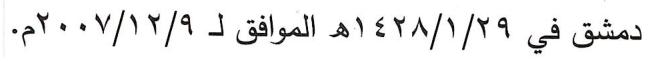

مشق فيموافق ٢

page_0003_011_text  |  layout=text 0.45  |  lines=3  rec_score=0.9753


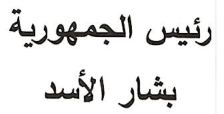

الجمهورية
رئيس
بشار الأسد

page_0003_012_number  |  layout=number 0.82  |  lines=1  rec_score=0.9905


٣

page_0004_001_text  |  layout=text 0.26  |  lines=1  rec_score=0.9252


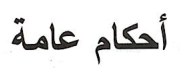

أحكام عامة

page_0004_002_figure_title  |  layout=figure_title 0.41  |  lines=1  rec_score=0.8703


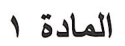

المادة

page_0004_003_text  |  layout=text 0.96  |  lines=3  rec_score=0.9556


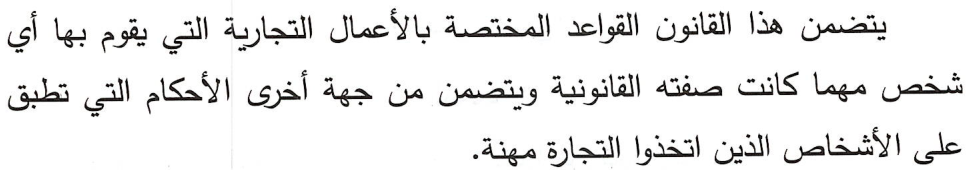

يتضمن هذا القانون القواعد المختصة بالأعمال التجارية التي يقوم بها أي
شخص مهما كانت صفته القانونية ويتضمن من جهة أخرى الأحكام التي تطبق
على الأشخاص الذين اتخذوا التجارة مهنة

page_0004_004_paragraph_title  |  layout=paragraph_title 0.80  |  lines=1  rec_score=0.9398


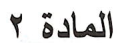

المادة٢

page_0004_005_text  |  layout=text 0.86  |  lines=3  rec_score=0.9392


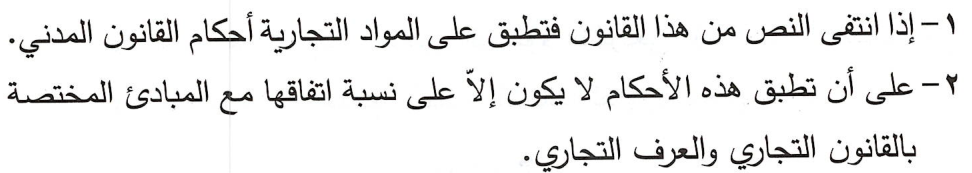

إذا انتفى النص من هذا القانون فتطبق على المواد التجارية أحكام القانون المدني
٢ على أن تطبق هذه الأحكام لا يكون إلاآً على نسبة اتفاقها مع المبادىئ المختصة
بالقانون التجاري والعرف التجاري

page_0004_006_paragraph_title  |  layout=paragraph_title 0.74  |  lines=1  rec_score=0.9945


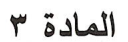

المادة٣

page_0004_007_text  |  layout=text 0.95  |  lines=2  rec_score=0.9664


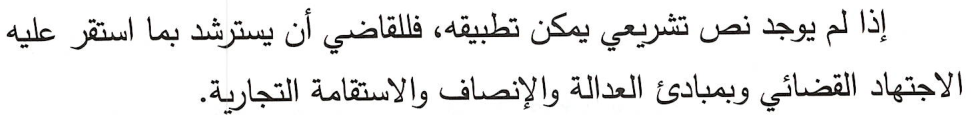

إذا لم يوجد نص تشريعي يمكن تطبيقه، فللقاضي أن يسترشد بما استقر عليه
الاجتهاد القضائي وبمبادئ العدالة والإنصاف والاستقامة التجارية

page_0004_008_paragraph_title  |  layout=paragraph_title 0.75  |  lines=1  rec_score=0.9107


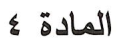

المادة ٤

page_0004_009_text  |  layout=text 0.91  |  lines=3  rec_score=0.9521


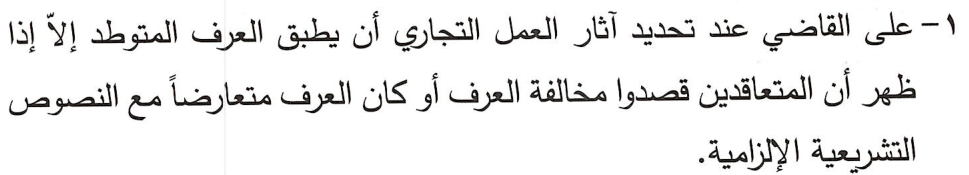

١ على القاضي عند تحديد آثار العمل التجاري أن يطبق العرف المتوطد إلآإذا
ظهر أن المتعاقدين قصدوا مخالفة العرف أو كان العرف متعارضاً مع النصوص
التشريعية الإلزامية

page_0004_010_number  |  layout=number 0.76  |  lines=1  rec_score=0.2221


A

page_0005_001_text  |  layout=text 0.56  |  lines=1  rec_score=0.9287


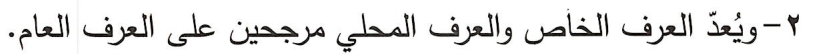

٢ـويُعدّ العرف الخأص والعرف المحلي مرجحين على العرفالعام

page_0005_002_paragraph_title  |  layout=paragraph_title 0.50  |  lines=1  rec_score=0.9993


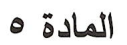

المادة

page_0005_003_text  |  layout=text 0.95  |  lines=4  rec_score=0.9123


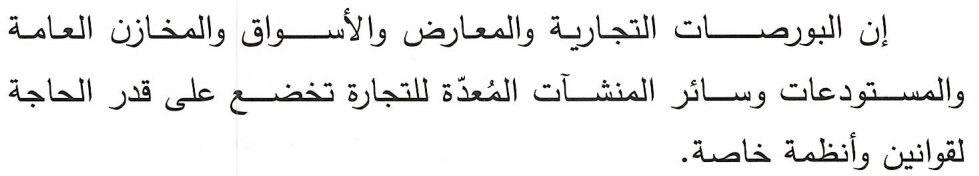

التجاارية والمعارض والأسواقوالمخازن العامة
إن البورصات
والمستودعات وسائر المنشات المُعدّة للتجارة تخضع على قدر الحاجة
لقوانين وأنظمة خاصة

page_0005_004_figure_title  |  layout=figure_title 0.63  |  lines=1  rec_score=0.9279


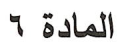

المادة٧

page_0005_005_text  |  layout=text 0.67  |  lines=15  rec_score=0.9491


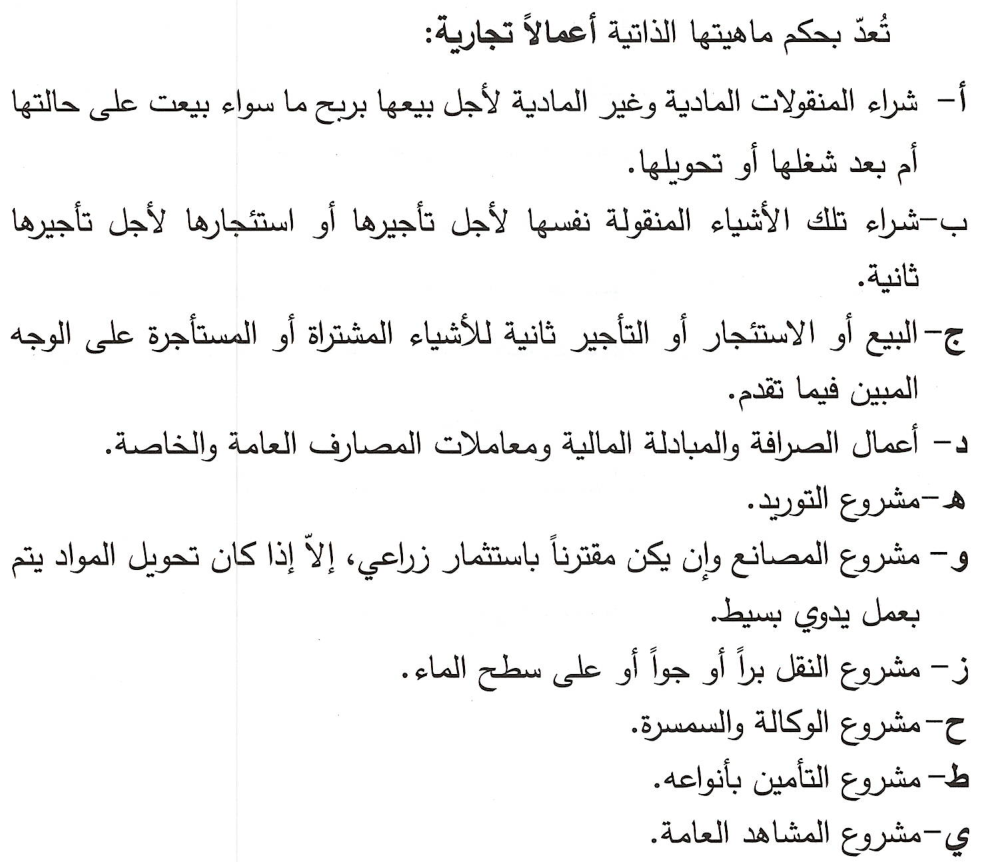

ثعدّ بحكم ماهيتها الذاتية أعمالاً تجارية
أ شراء المنقولات المادية وغير المادية لأجل بيعها بربح ما سواء بيعت على حالتها
أم بعد شغلها أو تحويلها
ب شراء تلك الأشياء المنقولة نفسها لأجل تأجيرها أو استثجارها لأجل تأجيرها
ثانية
جالبيع أو الاستئجار أو التأجير ثانية للأشياء المشترة أو المستأجرة على الوجه
المبين فيما تقدم
د أعمال الصرافة والمبادلة المالية ومعاملات المصارف العامة والخاصة
همشروع التوريد
ومشروع المصانع وإن يكن مقترناً باستثمار زراعي، إلآ إذا كان تحويل المواد يتم
بعمل يدوي بسيط
زـ مشروع النقل براً أو جواً أو على سطح الماء
حمشروع الوكالة والسمسرة
طـمشروع التأمين بأنواعه
يمشروع المشاهد العامة

page_0006_001_text  |  layout=text 0.40  |  lines=13  rec_score=0.9417


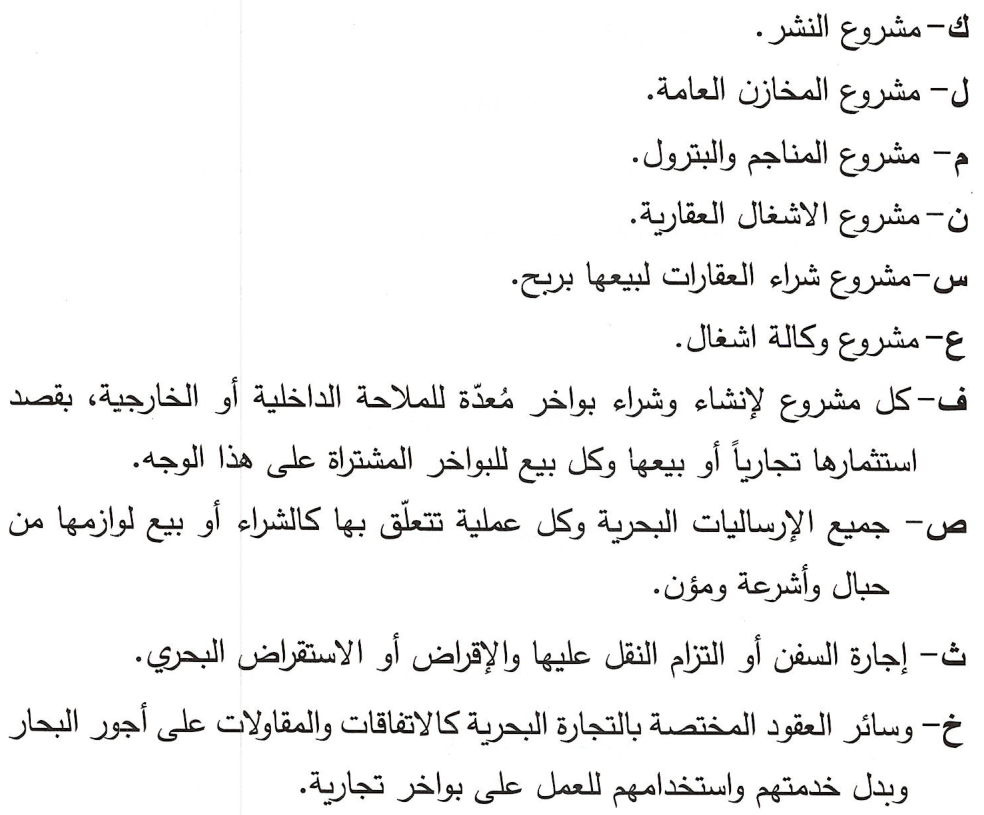

ك مشروع النشر
لمشروع المخازن العامة
ممشروع المناجم والبترول
نمشروع الاشغال العقارية
سمشروع شراء العقارات لبيعها بربح
عمشروع وكالة اشغال
فـكل مشروع لإنشاء وشراء بواخر مُعدّة للملاحة الداخلية أو الخارجية، بقصد
استثمارها تجارياً أو بيعها وكل بيع للبواخر المشتراة على هذا الوجه
ص جميع الإرساليات البحرية وكل عملية تتعلّق بها كالشراء أو بيع لوازمها من
حبال وأشرعة ومؤن
ث  إجارة السفن أو التزام النقل عليها والإقراض أو الاستقراض البحري
خوسائر العقود المختصة بالتجارة البحرية كالاتفاقات والمقاولات على أجور البحار
وبدل خدمتهم واستخدامهم للعمل على بواخر تجارية

page_0006_002_paragraph_title  |  layout=paragraph_title 0.63  |  lines=1  rec_score=0.9511


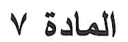

المادة

page_0006_003_text  |  layout=text 0.73  |  lines=2  rec_score=0.954


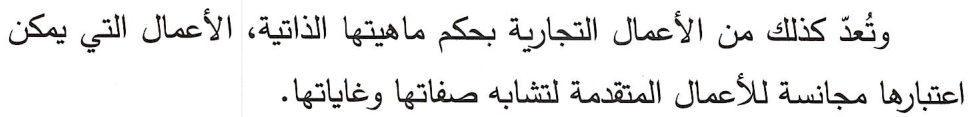

وثُعدّ كذلك من الأعمال التجارية بحكم ماهيتها الذاتية، الأعمال التي يمكن
اعتبارها مجانسة للأعمال المتقدمة لتشابه صفاتها وغاياتها

page_0006_004_paragraph_title  |  layout=paragraph_title 0.57  |  lines=1  rec_score=0.9439


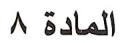

المادة

page_0006_005_text  |  layout=text 0.27  |  lines=4  rec_score=0.9752


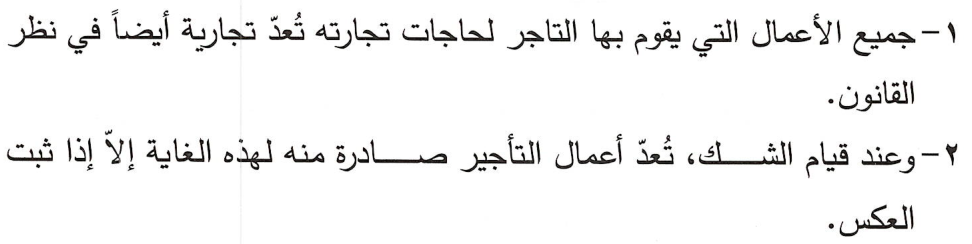

١جميع الأعمال التي يقوم بها التاجر لحاجات تجارته ثعدّ تجارية أيضاً في نظر
القانون
وعند قيام الشك، ثُعدّ أعمال التأجير صادرة منه لهذه الغاية إلآ إذا ثبت
العكس

page_0006_007_number  |  layout=number 0.78  |  lines=1  rec_score=0.205


5

page_0007_001_header  |  layout=header 0.52  |  lines=2  rec_score=0.4727


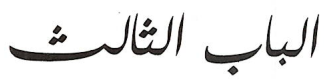

ارار
ايب

page_0007_002_text  |  layout=text 0.40  |  lines=1  rec_score=0.8473


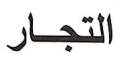

ااتجار

page_0007_003_text  |  layout=text 0.50  |  lines=3  rec_score=0.9179


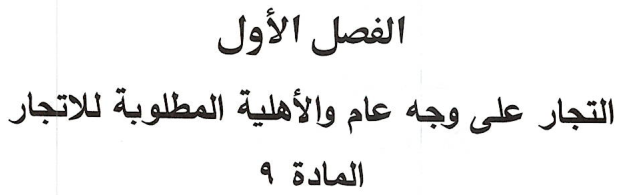

الفصل الأول
التجار على وجه عام والأهلية المطلوبة للاتجار
المادة ٩

page_0007_004_text  |  layout=text 0.64  |  lines=7  rec_score=0.5352


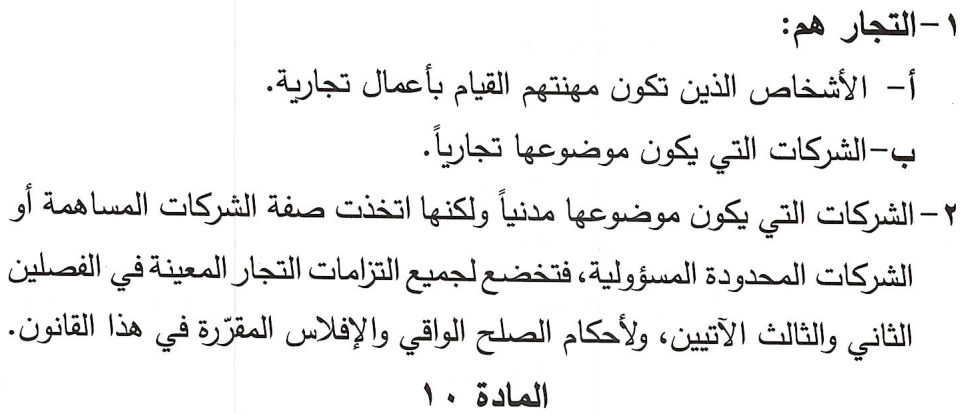

٢ا-
ا ة   ي  يي  ة عمي   ييي
في يي  ة  ي   ي
الةي ص     ي  ي   ي ي لي و  وو لوة     ل اة
يي ي ل  ي ي لقلويي  ل وي لي و ل  ل لO ل   ع  ي ي
لييلل  ليل و يولهم لو  ل   إل٥ص لل ي ل  لح ي
المادة

page_0007_005_text  |  layout=text 0.94  |  lines=6  rec_score=0.9509


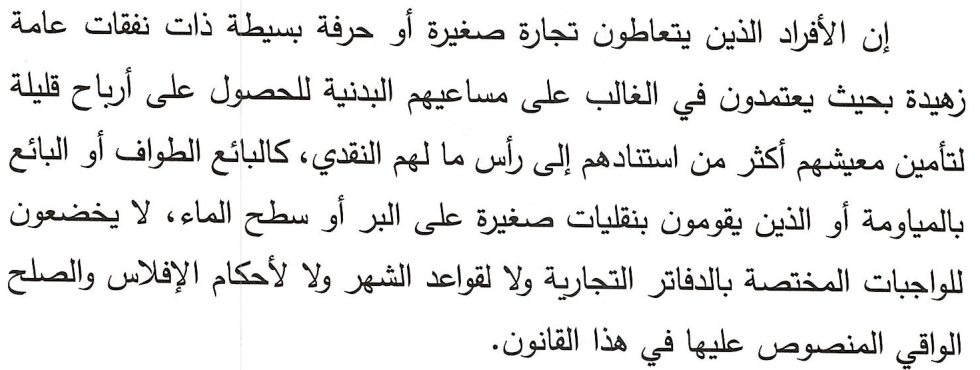

إن الأفراد الذين يتعاطون تجارة صغيرة أو حرفة بسيطة ذات نفقات عامة
زهيدة بحيث يعتمدون في الغالب على مساعيهم البدنية للحصول على أرباح قليلة
لتأمين معيشهم أكثر من استادهم إلى رأس ما لهم النقدي، كالبائع الطواف أو البائع
بالمياومة أو الذين يقومون بنقليات صغيرة على البر أو سطحالماء، لا يخضعون
للواجبات المختصة بالدفاتر التجارية ولا لقواعد الشهر ولا لأحكام الإفلاس والصلح
الواقي المنصوص عليها في هذا القانون

page_0007_006_paragraph_title  |  layout=paragraph_title 0.56  |  lines=1  rec_score=0.994


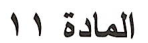

المادة

page_0007_007_text  |  layout=text 0.93  |  lines=3  rec_score=0.9399


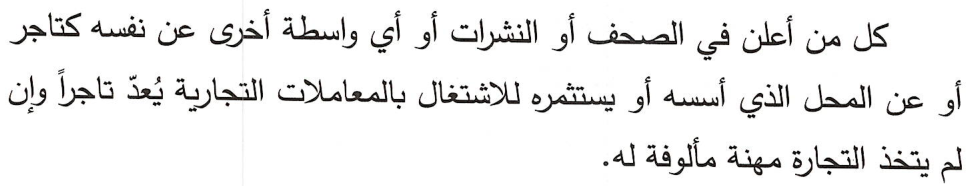

كل من أعلن فى الصحف أو النشرات أو أي واسطة أخرى عن نفسه كتاجر
أو عن المحل الذي أسسه أو يستثمره للاشتغال بالمعاملات التجارية يُعدّ تاجراً وإن
لم يتخذ التجارة مهنة مألوفة له

page_0007_008_number  |  layout=number 0.80  |  lines=1  rec_score=0.8067


V

page_0008_001_paragraph_title  |  layout=paragraph_title 0.73  |  lines=1  rec_score=0.9253


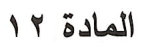

المادة١

page_0008_002_text  |  layout=text 0.93  |  lines=2  rec_score=0.9273


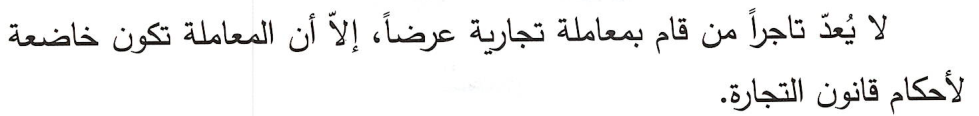

لا يُعدّ تاجراً من قام بمعاملة تجارية عرضاً إلآ أن المعاملة تكون خاضعة
لأحكام قانون التجارة

page_0008_003_paragraph_title  |  layout=paragraph_title 0.77  |  lines=1  rec_score=0.8863


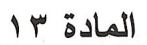

المادة ٣

page_0008_004_text  |  layout=text 0.26  |  lines=5  rec_score=0.9522


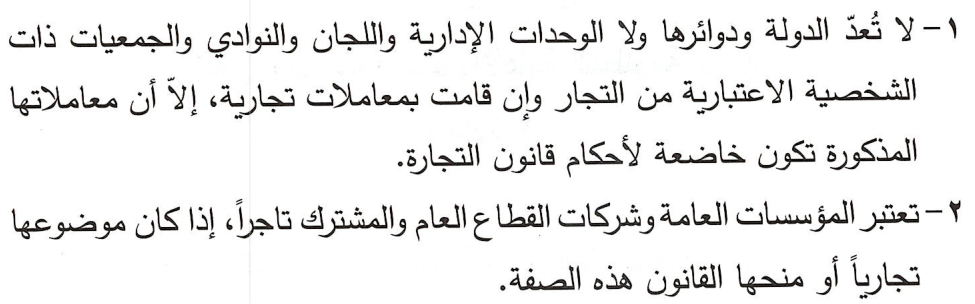

لا ثعدّ الدولة ودوائرها ولا الوحدات الإدارية واللجان والنوادي والجمعيات ذات
الشخصية الاعتبارية من التجار وإن قامت بمعاملات تجارية، إلآ أن معاملاتها
المذكورة تكون خاضعة لأحكام قانون التجارة
تعتبر المؤسسات العامة وشركات القطاع العام والمشترك تاجراً، إذا كان موضوعها
تجارياً أو منحها القانون هذه الصفة

page_0008_005_paragraph_title  |  layout=paragraph_title 0.76  |  lines=1  rec_score=0.9401


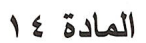

المادة ٤

page_0008_006_text  |  layout=text 0.89  |  lines=2  rec_score=0.9636


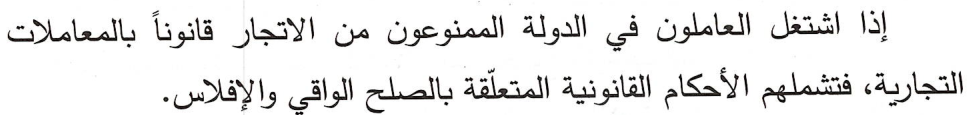

إذا اشتغل العاملون في الدولة الممنوعون من الاتجار قانوناً بالمعاملات
التجارية، فتشملهم الأحكام القانونية المتعلّقة بالصلح الواقي والإفلاس

page_0008_007_text  |  layout=text 0.31  |  lines=2  rec_score=0.9215


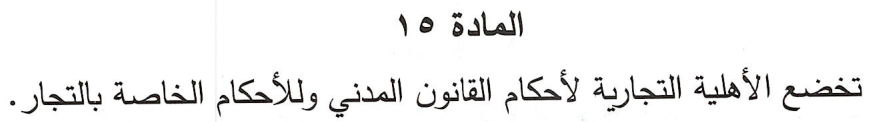

المادة ٥
تخضع الأهلية التجارية لأحكام القانون المدني وللأحكام الخاصة بالتجار

page_0008_008_paragraph_title  |  layout=paragraph_title 0.49  |  lines=2  rec_score=0.9683


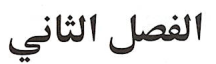

الثاني
الفصل

page_0008_009_paragraph_title  |  layout=paragraph_title 0.57  |  lines=2  rec_score=0.9622


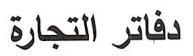

التجارة
دفاتر



In [25]:
# ============================================================
# 15. Spot-check: crops next to what the OCR read
# ============================================================
from IPython.display import Image, display

SPOT_CHECK_N = 50   # how many crops to eyeball

shown = [r for r in ocr_rows if r["text"]][:SPOT_CHECK_N]

if not shown:
    print("Nothing to show -- no crop produced text.")

for r in shown:
    print("=" * 70)
    print(f"{r['crop_id']}  |  layout={r['label']} {r['layout_score']:.2f}"
          f"  |  lines={r['n_lines']}  rec_score={r['mean_rec_score']}")
    display(Image(filename=r["crop_path"], width=650))
    print(r["text"])
    print()